In [2]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224")

for item in DATA_ROOT.iterdir():
    print(item)

labels_csv = DATA_ROOT / "Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv"
df = pd.read_csv(labels_csv, header=None)
print(df.shape)
print(df.head())

df.columns = [f"feature_{i}" for i in range(29)] + ["label", "flare_size", "filename"]
print(df["label"].value_counts())

/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Train_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Validation_data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/README.md
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Test_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Validation_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Train_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Test_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/C1.0_24hr_224_png_Labels.txt
(950047, 32)
         0         1   

label
0    759465
1    190582
Name: count, dtype: int64
label
0    79.94
1    20.06
Name: count, dtype: float64


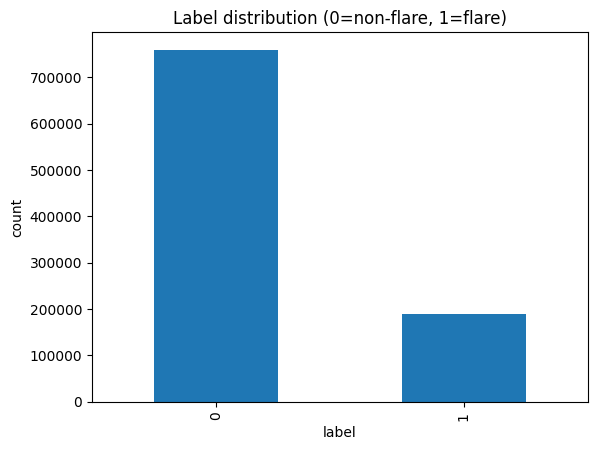

Number of unique ARs: 1570
count    1570.000000
mean      605.125478
std       316.406007
min         3.000000
25%       335.250000
50%       633.500000
75%       915.000000
max      1080.000000
dtype: float64


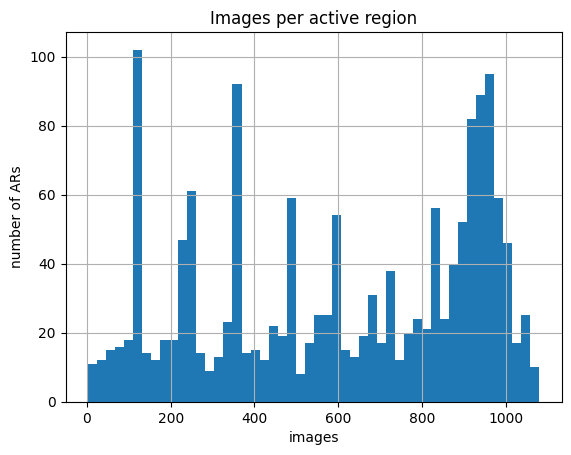

  AR_number    timestamp_str
0      1064  20100501_000000
1      1064  20100501_001200
2      1064  20100501_002400
3      1064  20100501_003600
4      1064  20100501_004800
5      1064  20100501_010000
6      1064  20100501_011200
7      1064  20100501_012400
8      1064  20100501_013600
9      1064  20100501_014800


In [3]:
import matplotlib.pyplot as plt

# --- Class balance ---
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

plt.figure()
counts.plot(kind="bar")
plt.title("Label distribution (0=non-flare, 1=flare)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

# --- Extract AR number from filename (first part before underscore) ---
df["AR_number"] = df["filename"].str.split("_").str[0]
per_ar = df.groupby("AR_number").size()
print("Number of unique ARs:", len(per_ar))
print(per_ar.describe())

plt.figure()
per_ar.hist(bins=50)
plt.title("Images per active region")
plt.xlabel("images"); plt.ylabel("number of ARs")
plt.show()

# --- Extract timestamp from filename for temporal check ---
df["timestamp_str"] = df["filename"].str.extract(r"(\d{8}_\d{6})")
print(df[["AR_number", "timestamp_str"]].head(10))

In [4]:
IMAGE_ROOT_REAL = DATA_ROOT / "Lat60_Lon60_Nans0_png_224" / "Lat60_Lon60_Nans0_png_224"

sample_row = df.iloc[0]
sample_path = IMAGE_ROOT_REAL / sample_row["AR_number"] / sample_row["filename"]
print("Testing path:", sample_path)
print("Exists:", sample_path.exists())

if sample_path.exists():
    img = Image.open(sample_path)
    arr = np.array(img)
    print("Size:", img.size, "Mode:", img.mode, "dtype:", arr.dtype)
    print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())

Testing path: /kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1064/1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
Exists: True
Size: (224, 224) Mode: L dtype: uint8
Min: 70 Max: 172 Mean: 127.51094148596938


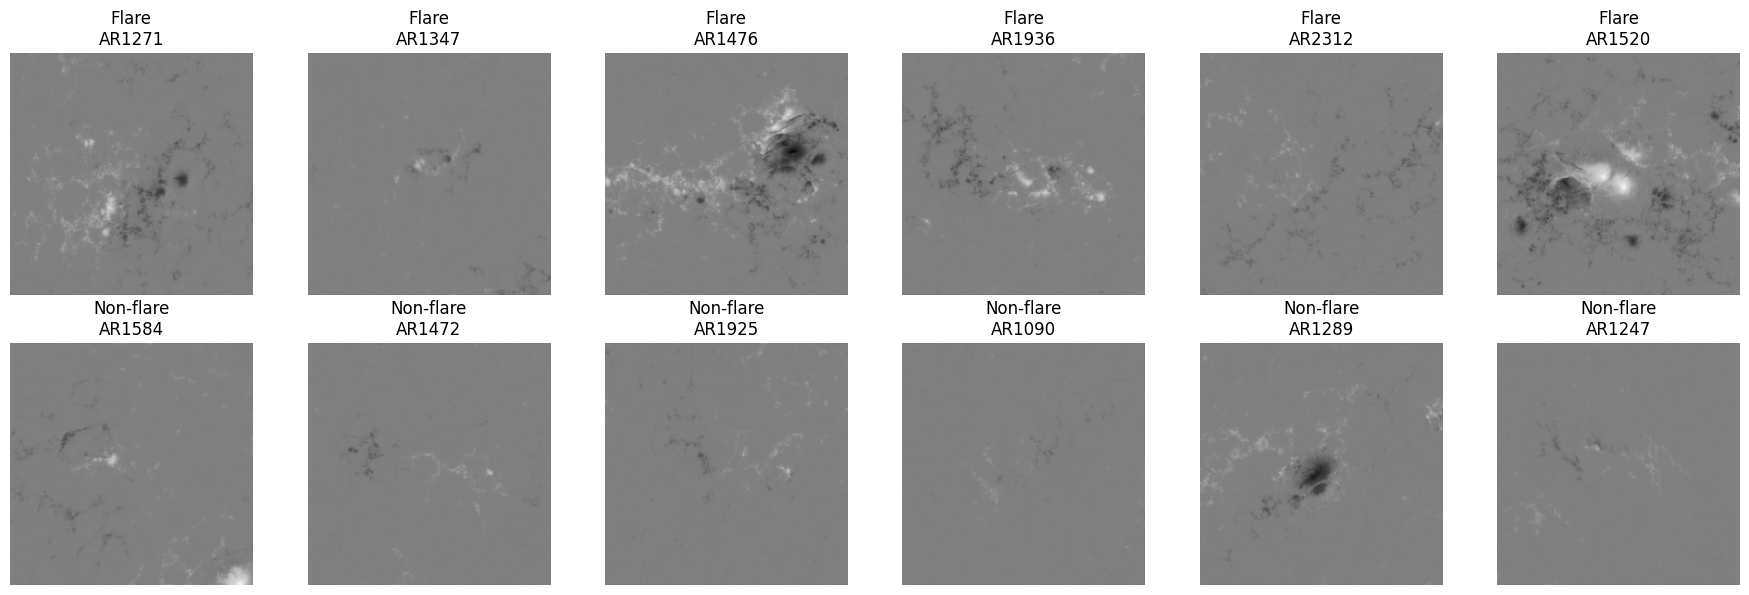

In [5]:
import matplotlib.pyplot as plt

def get_image_path(row):
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

# Sample 6 flare and 6 non-flare images
flare_sample = df[df["label"] == 1].sample(6, random_state=1)
nonflare_sample = df[df["label"] == 0].sample(6, random_state=1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (_, row) in enumerate(flare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Flare\nAR{row['AR_number']}")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(nonflare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Non-flare\nAR{row['AR_number']}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
import hashlib
from collections import defaultdict

# Sample 300 images for corruption/duplicate check (checking all 950k would take too long)
check_sample = df.sample(300, random_state=42)

corrupted = []
hashes = defaultdict(list)

for _, row in check_sample.iterrows():
    p = get_image_path(row)
    if not p.exists():
        corrupted.append((str(p), "missing"))
        continue
    try:
        Image.open(p).verify()
        with open(p, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes[h].append(str(p))
    except Exception as e:
        corrupted.append((str(p), str(e)))

print(f"Corrupted/missing in sample of 300: {len(corrupted)}")
dupes = {h: paths for h, paths in hashes.items() if len(paths) > 1}
print(f"Duplicate groups found: {len(dupes)}")

# --- AR-level leakage check: does the official split avoid overlap? ---
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)

train_ids = set(train_ar[0].astype(str))
val_ids = set(val_ar[0].astype(str))
test_ids = set(test_ar[0].astype(str))

print("Train ARs:", len(train_ids), "Val ARs:", len(val_ids), "Test ARs:", len(test_ids))
print("Train∩Val overlap:", train_ids & val_ids)
print("Train∩Test overlap:", train_ids & test_ids)
print("Val∩Test overlap:", val_ids & test_ids)

Corrupted/missing in sample of 300: 0
Duplicate groups found: 0
Train ARs: 1256 Val ARs: 157 Test ARs: 157
Train∩Val overlap: set()
Train∩Test overlap: set()
Val∩Test overlap: set()


In [7]:
report = f"""
BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT
==================================================

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact timestamp
(e.g. 1064_hmi.M_720s.20100501_000000_TAI...), cadence ~720 seconds (12 min),
consistent with README's stated acquisition cadence.

ML IMPLICATIONS
- Use the authors' official AR-level split (Train/Validation/Test_Data_by_AR_png_224.csv)
  rather than a random image-level split, to avoid leakage.
- 20%/80% class imbalance likely needs class weighting or resampling during training.
- Temporal modeling (CNN+GRU/LSTM per AR sequence) is feasible: real, evenly-spaced
  timestamped sequences exist per AR (confirmed, not assumed).
- Recommended next step: build a baseline single-frame CNN using the official split
  first, establish a benchmark, then evaluate whether adding temporal modeling improves
  on it — consistent with van der Sande et al. 2023's finding referenced in the project notes.
"""

print(report)
with open("/kaggle/working/data_report.txt", "w") as f:
    f.write(report)
print("\nReport saved to /kaggle/working/data_report.txt")


BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact t

In [8]:
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)[0].astype(str)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)[0].astype(str)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)[0].astype(str)

train_data = df[df["AR_number"].isin(train_ar)]
val_data = df[df["AR_number"].isin(val_ar)]
test_data = df[df["AR_number"].isin(test_ar)]

print("Train:", train_data.shape, "Val:", val_data.shape, "Test:", test_data.shape)

Train: (759357, 34) Val: (95933, 34) Test: (94757, 34)


In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler

feature_cols = [f"feature_{i}" for i in range(29)]

# --- Missing value check (critical — don't skip) ---
print("Missing values per feature (train set):")
print(train_data[feature_cols].isna().sum())

print("\nMissing values per feature (val set):")
print(val_data[feature_cols].isna().sum())

print("\nMissing values per feature (test set):")
print(test_data[feature_cols].isna().sum())

# --- Check for infinite values too (can silently break SVM training) ---
print("\nInfinite values in train set:", np.isinf(train_data[feature_cols].values).sum())

Missing values per feature (train set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
dtype: int64

Missing values per feature (val set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27  

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_data[feature_cols])
X_val = scaler.transform(val_data[feature_cols])
X_test = scaler.transform(test_data[feature_cols])

y_train = train_data["label"].values
y_val = val_data["label"].values
y_test = test_data["label"].values

print("X_train shape:", X_train.shape)
print("X_train mean (should be ~0):", X_train.mean().round(3))
print("X_train std (should be ~1):", X_train.std().round(3))

X_train shape: (759357, 29)
X_train mean (should be ~0): 0.0
X_train std (should be ~1): 0.965


In [11]:
from sklearn.svm import LinearSVC
import time

start = time.time()

svm_model = LinearSVC(
    class_weight="balanced",   # corrects for the 80/20 imbalance
    max_iter=5000,             # LinearSVC sometimes needs more iterations to converge on large data
    random_state=42
)

svm_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training finished in {elapsed/60:.1f} minutes")

Training finished in 0.3 minutes


In [12]:
print("Number of iterations used:", svm_model.n_iter_)
print("Max iterations allowed:", svm_model.max_iter)
print("Coefficient shape:", svm_model.coef_.shape)
print("Intercept:", svm_model.intercept_)

Number of iterations used: 16
Max iterations allowed: 5000
Coefficient shape: (1, 29)
Intercept: [-0.19689937]


In [13]:
from sklearn.metrics import confusion_matrix

val_preds = svm_model.predict(X_val)
print("Prediction distribution:", pd.Series(val_preds).value_counts())
print("\nConfusion matrix:")
print(confusion_matrix(y_val, val_preds))

Prediction distribution: 0    62671
1    33262
Name: count, dtype: int64

Confusion matrix:
[[57830 18312]
 [ 4841 14950]]


In [14]:
TN, FP, FN, TP = confusion_matrix(y_val, val_preds).ravel()

TPR = TP / (TP + FN)   # sensitivity: correctly caught flares
TNR = TN / (TN + FP)   # specificity: correctly caught non-flares

TSS = TPR + TNR - 1

HSS = 2 * (TP*TN - FN*FP) / ((TP+FN)*(FN+TN) + (TP+FP)*(FP+TN))

print(f"TPR (recall on flares): {TPR:.4f}")
print(f"TNR (recall on non-flares): {TNR:.4f}")
print(f"TSS: {TSS:.4f}")
print(f"HSS: {HSS:.4f}")

TPR (recall on flares): 0.7554
TNR (recall on non-flares): 0.7595
TSS: 0.5149
HSS: 0.4113


In [15]:
test_preds = svm_model.predict(X_test)
TN, FP, FN, TP = confusion_matrix(y_test, test_preds).ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
TSS = TPR + TNR - 1
HSS = 2 * (TP*TN - FN*FP) / ((TP+FN)*(FN+TN) + (TP+FP)*(FP+TN))

print(f"TEST SET RESULTS")
print(f"TPR: {TPR:.4f}, TNR: {TNR:.4f}")
print(f"TSS: {TSS:.4f}, HSS: {HSS:.4f}")

TEST SET RESULTS
TPR: 0.7821, TNR: 0.7560
TSS: 0.5382, HSS: 0.4427


In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

# LinearSVC has no predict_proba, but decision_function gives a real-valued score
val_scores = svm_model.decision_function(X_val)

thresholds = np.linspace(val_scores.min(), val_scores.max(), 300)
best_tss, best_thresh = -1, 0.0

for t in thresholds:
    preds = (val_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    tss = tpr + tnr - 1
    if tss > best_tss:
        best_tss, best_thresh = tss, t

print(f"Best threshold (chosen on validation set only): {best_thresh:.4f}")
print(f"Validation TSS at this threshold: {best_tss:.4f}")

# Apply that SAME threshold to test — never re-tune on test data, that would be leakage
test_scores = svm_model.decision_function(X_test)
test_preds_tuned = (test_scores >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds_tuned).ravel()
tpr, tnr = tp/(tp+fn), tn/(tn+fp)
tss_tuned = tpr + tnr - 1
hss_tuned = 2*(tp*tn - fn*fp) / ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))

print(f"\nTEST SET (threshold tuned on val): TPR={tpr:.4f}, TNR={tnr:.4f}")
print(f"TSS={tss_tuned:.4f}, HSS={hss_tuned:.4f}")

Best threshold (chosen on validation set only): 0.0588
Validation TSS at this threshold: 0.5177

TEST SET (threshold tuned on val): TPR=0.7515, TNR=0.7895
TSS=0.5409, HSS=0.4644


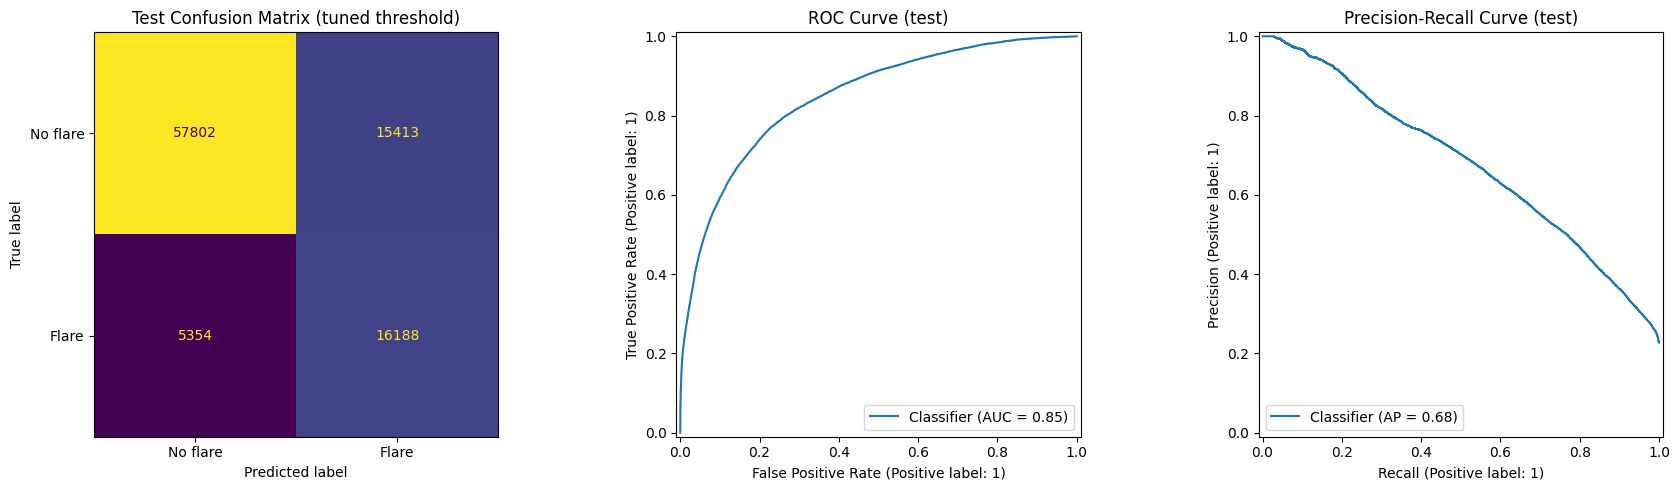

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_tuned,
    display_labels=["No flare", "Flare"], ax=axes[0], colorbar=False)
axes[0].set_title("Test Confusion Matrix (tuned threshold)")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[1])
axes[1].set_title("ROC Curve (test)")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (test)")
plt.tight_layout()
plt.show()

Top magnetic-complexity features driving the SVM decision:

feature_0     3.270221e+00
feature_20   -2.293582e+00
feature_8    -5.257788e-01
feature_21   -4.793324e-01
feature_1     3.731584e-01
feature_22   -3.443468e-01
feature_7     3.439083e-01
feature_23   -2.738606e-01
feature_24   -2.448168e-01
feature_6    -1.506732e-01
feature_28    1.190681e-01
feature_26   -1.110130e-01
feature_9     1.056730e-01
feature_25    1.041666e-01
feature_5     6.048452e-02
feature_4     5.977531e-02
feature_11   -5.414549e-02
feature_12    2.724134e-02
feature_17    2.282902e-02
feature_27   -1.561464e-02
feature_2     1.519923e-02
feature_13    1.514020e-02
feature_15   -1.168520e-02
feature_10   -1.140208e-02
feature_16    7.823472e-03
feature_18    1.766380e-03
feature_19   -1.107877e-03
feature_14   -5.246453e-16
feature_3     0.000000e+00
dtype: float64


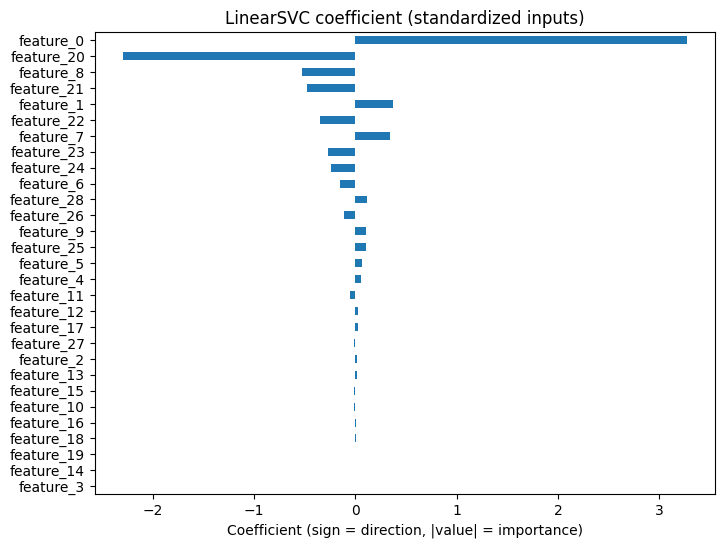

In [18]:
import pandas as pd

coef = svm_model.coef_.ravel()
importance = pd.Series(coef, index=feature_cols).sort_values(key=abs, ascending=False)
print("Top magnetic-complexity features driving the SVM decision:\n")
print(importance)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.title("LinearSVC coefficient (standardized inputs)")
plt.xlabel("Coefficient (sign = direction, |value| = importance)")
plt.gca().invert_yaxis()
plt.show()

In [19]:
rng = np.random.default_rng(42)
n_boot = 1000
# FIX (overfitting / stats): resample by AR, not by row. Rows from the same AR are
# correlated, so row-level bootstrap understates true uncertainty.
test_ar_ids = test_data["AR_number"].values
unique_ars = np.unique(test_ar_ids)
tss_boot = []

codes, uniq = pd.factorize(test_ar_ids); k = len(uniq)
pred_full = (test_scores >= best_thresh).astype(int)
cnt = np.stack([np.bincount(codes, weights=m.astype(float), minlength=k) for m in
                [(y_test == 1) & (pred_full == 1), (y_test == 1) & (pred_full == 0),
                 (y_test == 0) & (pred_full == 1), (y_test == 0) & (pred_full == 0)]], 1)
for _ in range(n_boot):
    tp, fn, fp, tn = cnt[rng.integers(0, k, k)].sum(0)   # an AR drawn twice counts twice
    tss_boot.append(tp/(tp+fn) - fp/(fp+tn))

ci_low, ci_high = np.percentile(tss_boot, [2.5, 97.5])
print(f"Test TSS: {tss_tuned:.4f}  (95% bootstrap CI, resampled by AR: [{ci_low:.4f}, {ci_high:.4f}])")


Test TSS: 0.5409  (95% bootstrap CI, resampled by AR: [0.4460, 0.6141])


In [20]:
import joblib
joblib.dump(svm_model, "/kaggle/working/svm_baseline_model.joblib")
joblib.dump(scaler, "/kaggle/working/svm_baseline_scaler.joblib")
joblib.dump({"threshold": best_thresh}, "/kaggle/working/svm_baseline_threshold.joblib")
print("Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib")

Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib


In [21]:
print(train_data[["feature_3", "feature_14"]].describe())
print("\nUnique values:")
print("feature_3:", train_data["feature_3"].nunique())
print("feature_14:", train_data["feature_14"].nunique())

       feature_3    feature_14
count   759357.0  7.593570e+05
mean         0.0  4.712389e+00
std          0.0  5.398796e-11
min          0.0  4.712389e+00
25%          0.0  4.712389e+00
50%          0.0  4.712389e+00
75%          0.0  4.712389e+00
max          0.0  4.712389e+00

Unique values:
feature_3: 1
feature_14: 1


In [22]:
final_report = f"""
STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)
===============================================

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: {best_thresh:.4f}

TEST SET (final, threshold tuned on val — no test leakage)
TPR: {tpr:.4f}   TNR: {tnr:.4f}
TSS: {tss_tuned:.4f}   (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])
HSS: {hss_tuned:.4f}

VALIDATION SET
TSS: {best_tss:.4f}

BENCHMARK COMPARISON (same dataset, same official AR split)
Boucheron et al. 2023, linear SVM (reduced res): TSS 0.5348, HSS 0.4350
Boucheron et al. 2023, VGG16 frozen transfer:    TSS 0.5325, HSS 0.4636
This baseline: TSS {tss_tuned:.4f}, HSS {hss_tuned:.4f} -> reproduces the published SVM; it does not beat it.
(Bloomfield 2012 used a different dataset and method, so it is not a like-for-like comparison.)
TOP DRIVING FEATURES (by |coefficient|)
feature_0, feature_20, feature_8, feature_21, feature_1
(see feature-importance plot; exact physical names require cross-referencing
 the Boucheron et al. 2023 README column order — not yet confirmed)

ARTIFACTS SAVED
/kaggle/working/svm_baseline_model.joblib
/kaggle/working/svm_baseline_scaler.joblib
/kaggle/working/svm_baseline_threshold.joblib

STATUS: Stage 1 complete and locked. Proceeding to Stage 2 (CNN on raw images).
"""
print(final_report)
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)


STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: 0.0588

TEST SET (final, threshold tuned on val — no test leakage)
TPR: 0.7515   TNR: 0.7895
TSS: 0.5409   (95% bootstrap CI: [0.4460, 0.6141])
HSS: 0.4644

VALIDATION SET
TSS: 0.5177

BENCHMARK COMPARISON (same dataset, same official AR split)
Boucheron et al. 2023, linear SVM (reduced res): TSS 0.5348, HSS 0.4350
Boucheron et al. 2023, VGG16 frozen transfer:    TSS 0.5325, HSS 0.4636
This baseline: TSS 0.5409, HSS 0.4644 -> reproduces the published SVM; it does not beat it.
(Bloomfield 2012 used a different dataset and method, so it is not a like-for-like comparison.)
TOP DRIVING FEATURES (by |coefficient|)
feature_0, feature_20, feature_8, feature_21, feature_1
(see feature-importance plot; exact physical names require cross-referencing
 the Boucheron et al

In [23]:
final_report += """
DATA QUALITY NOTE
feature_3 and feature_14 are constant across all 759,357 training rows
(feature_3 = 0.0 always; feature_14 = 4.712389 always, std ≈ 5e-11).
These 2 of 29 features carry zero discriminative information in this
preconfigured dataset subset — confirmed via .describe()/.nunique(), not assumed.
"""
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)
print("Updated.")

Updated.


In [24]:
# A1 — configuration, seeds, metrics
import os, re, json, time, random, warnings
import numpy as np, pandas as pd
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score, brier_score_loss)

CFG = dict(
    seed=42,
    hist_lag_h=24,        # flare-history lag. MUST be >= the 24 h label window, otherwise it leaks the future.
    lag_tol_min=30,       # a lag lookup must land within this many minutes of the wanted time (frames have gaps)
    roll_h=2,             # rolling mean/std window (hours)
    kurt_h=(3, 6, 12),    # kurtosis windows (hours)
    diff_h=(1, 3, 6, 12), # "change over the last X hours" lags
    top_k=10,             # how many base features get the temporal treatment (chosen by importance, TRAIN only)
    const_cols=("feature_3", "feature_14"),   # constant in this dataset (your cell 19)
)

def set_all_seeds(seed=CFG["seed"]):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
set_all_seeds()

def skill_scores(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    d = lambda a, b: a / b if b else np.nan
    tpr, fpr = d(tp, tp + fn), d(fp, fp + tn)
    den = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    return dict(TSS=tpr - fpr, HSS=d(2 * (tp * tn - fn * fp), den), POD=tpr, FPR=fpr,
                FAR=d(fp, tp + fp), CSI=d(tp, tp + fn + fp), TP=tp, FP=fp, FN=fn, TN=tn)

def best_tss_threshold(y, score):
    """Exact TSS-optimal threshold (TSS = TPR - FPR). Fit on VALIDATION only, then freeze."""
    fpr, tpr, thr = roc_curve(y, score)
    return float(thr[np.argmax(tpr - fpr)])

def prob_scores(y, p):
    bs = brier_score_loss(y, p)
    bs_ref = brier_score_loss(y, np.full(len(y), np.mean(y)))   # climatology reference
    return dict(ROC_AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p), Brier=bs, BSS=1 - bs / bs_ref)

def full_report(y, p, thr):
    return {**prob_scores(y, p), **skill_scores(y, (np.asarray(p) >= thr).astype(int))}

def ar_bootstrap(ar_ids, y, pred, n_boot=2000, seed=CFG["seed"]):
    """95% CI of TSS by resampling whole active regions (per-AR confusion counts -> fast)."""
    codes, _ = pd.factorize(np.asarray(ar_ids)); k = codes.max() + 1
    y, pred = np.asarray(y), np.asarray(pred)
    cnt = np.stack([np.bincount(codes, weights=m.astype(float), minlength=k) for m in
                    [(y == 1) & (pred == 1), (y == 1) & (pred == 0), (y == 0) & (pred == 1), (y == 0) & (pred == 0)]], 1)
    rng = np.random.default_rng(seed); out = []
    for _ in range(n_boot):
        tp, fn, fp, tn = cnt[rng.integers(0, k, k)].sum(0)
        out.append(tp / (tp + fn) - fp / (fp + tn))
    return np.percentile(out, [2.5, 97.5])
print("A1 ready.")

A1 ready.


In [25]:
# A2 — full-series table (uses df, train_ar, val_ar, test_ar from your cells 0 and 6)
base_cols = [f"feature_{i}" for i in range(29) if f"feature_{i}" not in CFG["const_cols"]]

def flare_score(s):
    """'C4.7' -> 47, 'M1.2' -> 120, 'X2.0' -> 2000 (weighting idea from Williams et al. 2026); no flare -> 0."""
    s = str(s).strip()
    if s in ("0", "0.0", "nan", "None", ""): return 0.0
    mult = {"C": 10.0, "M": 100.0, "X": 1000.0}.get(s[0].upper())
    try: return mult * float(s[1:]) if mult else 0.0
    except ValueError: return 0.0

T = df.copy()
T["AR"] = T["filename"].str.split("_").str[0]
T["ts"] = pd.to_datetime(T["filename"].str.extract(r"(\d{8}_\d{6})")[0], format="%Y%m%d_%H%M%S")
tr_ids, va_ids, te_ids = (set(map(str, s)) for s in (train_ar, val_ar, test_ar))
T["split"] = np.select([T.AR.isin(tr_ids), T.AR.isin(va_ids), T.AR.isin(te_ids)], ["train", "val", "test"], default="none")
assert (T.split == "none").sum() == 0, "some rows belong to no split"
fs_map = {s: flare_score(s) for s in T["flare_size"].astype(str).unique()}
T["fscore"] = T["flare_size"].astype(str).map(fs_map)
T = T.sort_values(["AR", "ts"]).reset_index(drop=True)
print(T.split.value_counts().to_dict(), "| ARs:", T.AR.nunique(), "| positives:", int(T.label.sum()))

{'train': 759357, 'val': 95933, 'test': 94757} | ARs: 1570 | positives: 190582


In [26]:
# T1 — config + raw-order monotonicity check (uses the ORIGINAL df, before our own sorting,
# so this checks whether the SOURCE FILES themselves are already time-ordered)
TOL_S = 60          # tolerance band around the 720s nominal cadence, in seconds
CADENCE_S = 720

raw_ts = pd.to_datetime(df["filename"].str.extract(r"(\d{8}_\d{6})")[0], format="%Y%m%d_%H%M%S", errors="coerce")
n_unparseable_total = int(raw_ts.isna().sum())

def _nonmono_count(g):
    t = g.to_numpy()
    ok = ~pd.isna(t)
    t = t[ok]
    if len(t) < 2:
        return 0
    return int((np.diff(t.astype("datetime64[s]").astype(np.int64)) < 0).sum())

nonmono_by_ar = raw_ts.groupby(df["AR_number"]).apply(_nonmono_count)
print(f"Unparseable timestamps in the whole dataset: {n_unparseable_total}")
print(f"ARs whose rows are NOT already time-ordered in the CSV: {(nonmono_by_ar > 0).sum()} / {df['AR_number'].nunique()}")
print(f"Total out-of-order adjacent pairs (raw file order): {int(nonmono_by_ar.sum())}")

Unparseable timestamps in the whole dataset: 0
ARs whose rows are NOT already time-ordered in the CSV: 0 / 1570
Total out-of-order adjacent pairs (raw file order): 0


In [27]:
# T2 — per-AR temporal summary (built on T, which is already parsed, time-sorted and
# split-labelled by your own cell A2 — no re-parsing, no re-splitting)
ar_ids   = T["AR"].to_numpy()
ts_s     = T["ts"].to_numpy("datetime64[s]").astype(np.int64)
lab_arr  = T["label"].to_numpy()
bounds   = np.flatnonzero(np.r_[True, ar_ids[1:] != ar_ids[:-1], True])   # same AR-block pattern as your A4/A6

rows = []
for a, b in zip(bounds[:-1], bounds[1:]):
    t = ts_s[a:b]
    n = b - a
    rec = dict(
        AR_number=ar_ids[a], n_observations=int(n),
        first_timestamp=pd.Timestamp(t[0], unit="s"), last_timestamp=pd.Timestamp(t[-1], unit="s"),
        duration_hours=(t[-1] - t[0]) / 3600.0,
    )
    if n >= 2:
        d = np.diff(t).astype(float)
        rec.update(
            median_delta_seconds=float(np.median(d)), mean_delta_seconds=float(np.mean(d)),
            min_delta_seconds=float(d.min()), max_delta_seconds=float(d.max()), std_delta_seconds=float(np.std(d)),
            n_duplicate_timestamps=int((d == 0).sum()),
            n_short_intervals=int(((d < CADENCE_S - TOL_S) & (d > 0)).sum()),
        )
        gaps = d[d > CADENCE_S + TOL_S]
        rec["n_large_gaps"] = int(len(gaps))
        missing = np.round(gaps / CADENCE_S) - 1
        rec["n_missing_intervals"] = int(missing[missing > 0].sum())
        rec["n_irregular_gaps"] = int((np.abs(gaps - np.round(gaps / CADENCE_S) * CADENCE_S) > TOL_S).sum())
    else:
        rec.update(median_delta_seconds=np.nan, mean_delta_seconds=np.nan, min_delta_seconds=np.nan,
                    max_delta_seconds=np.nan, std_delta_seconds=np.nan, n_duplicate_timestamps=0,
                    n_short_intervals=0, n_large_gaps=0, n_missing_intervals=0, n_irregular_gaps=0)
    rows.append(rec)

ar_temporal_summary = pd.DataFrame(rows)
ar_temporal_summary["sequence_length"] = ar_temporal_summary["n_observations"]
ar_temporal_summary["n_non_monotonic"] = ar_temporal_summary["AR_number"].map(nonmono_by_ar).fillna(0).astype(int)
ar_temporal_summary["n_unparseable_timestamps"] = (
    raw_ts.isna().groupby(df["AR_number"]).sum().reindex(ar_temporal_summary["AR_number"]).fillna(0).to_numpy().astype(int)
)
print("ar_temporal_summary:", ar_temporal_summary.shape)
display(ar_temporal_summary.head())

desc_cols = ["n_observations", "duration_hours", "median_delta_seconds", "mean_delta_seconds",
             "min_delta_seconds", "max_delta_seconds", "std_delta_seconds",
             "n_large_gaps", "n_missing_intervals", "n_duplicate_timestamps", "n_non_monotonic"]
display(ar_temporal_summary[desc_cols].describe(percentiles=[.25, .5, .75]).round(3))

ar_temporal_summary: (1570, 18)


,AR_number,n_observations,first_timestamp,last_timestamp,duration_hours,median_delta_seconds,mean_delta_seconds,min_delta_seconds,max_delta_seconds,std_delta_seconds,n_duplicate_timestamps,n_short_intervals,n_large_gaps,n_missing_intervals,n_irregular_gaps,sequence_length,n_non_monotonic,n_unparseable_timestamps
0,1064,358,2010-05-01 00:00:00,2010-05-03 23:48:00,71.8,720.0,724.033613,720.0,2160.0,76.106066,0,0,1,2,0,358,0,0
1,1065,240,2010-05-03 00:00:00,2010-05-04 23:48:00,47.8,720.0,720.000000,720.0,720.0,0.000000,0,0,0,0,0,240,0,0
2,1066,478,2010-05-03 00:00:00,2010-05-06 23:48:00,95.8,720.0,723.018868,720.0,2160.0,65.863922,0,0,1,2,0,478,0,0
3,1067,522,2010-05-03 15:12:00,2010-05-07 23:48:00,104.6,720.0,722.763916,720.0,2160.0,63.026972,0,0,1,2,0,522,0,0
4,1068,348,2010-05-06 02:00:00,2010-05-08 23:48:00,69.8,720.0,724.149856,720.0,2160.0,77.191782,0,0,1,2,0,348,0,0


,n_observations,duration_hours,median_delta_seconds,mean_delta_seconds,min_delta_seconds,max_delta_seconds,std_delta_seconds,n_large_gaps,n_missing_intervals,n_duplicate_timestamps,n_non_monotonic
count,1570.000,1570.000,1570.0,1570.000,1570.0,1570.000,1570.000,1570.000,1570.000,1570.0,1570.0
mean,605.125,123.429,720.0,736.465,720.0,5453.197,239.697,2.126,13.017,0.0,0.0
std,316.406,64.466,0.0,28.935,0.0,7470.924,357.230,3.472,20.450,0.0,0.0
min,3.000,0.400,720.0,720.000,720.0,720.000,0.000,0.000,0.000,0.0,0.0
25%,335.250,71.650,720.0,720.000,720.0,720.000,0.000,0.000,0.000,0.0,0.0
50%,633.500,130.100,720.0,723.019,720.0,2160.000,68.684,1.000,2.000,0.0,0.0
75%,915.000,187.400,720.0,744.235,720.0,7200.000,476.505,2.000,22.000,0.0,0.0
max,1080.000,215.800,720.0,1173.699,720.0,56160.000,3849.761,30.000,131.000,0.0,0.0


In [28]:
# T3 — cadence classification: what fraction of intervals are exact / approx / gap / short / duplicate
all_deltas = []
for a, b in zip(bounds[:-1], bounds[1:]):
    t = ts_s[a:b]
    if b - a >= 2:
        all_deltas.append(np.diff(t).astype(float))
all_deltas = np.concatenate(all_deltas) if all_deltas else np.array([])

exact   = (all_deltas == CADENCE_S)
approx  = (~exact) & (np.abs(all_deltas - CADENCE_S) <= TOL_S)
gap     = all_deltas > CADENCE_S + TOL_S
short   = (all_deltas > 0) & (all_deltas < CADENCE_S - TOL_S)
dup     = all_deltas == 0

print(f"Total intervals analysed: {len(all_deltas):,}")
for name, mask in [("exactly 720s", exact), (f"approx 720s (+/-{TOL_S}s)", approx),
                    ("> 720s (gap)", gap), ("< 720s (short, not duplicate)", short), ("duplicate (0s)", dup)]:
    print(f"  {name:32s} {mask.sum():>9,}  ({100*mask.mean():5.2f}%)")

def ar_bucket(row):
    if row["n_observations"] < 2: return "single-obs (n/a)"
    if row["n_large_gaps"] == 0 and row["n_duplicate_timestamps"] == 0 and row["n_short_intervals"] == 0:
        return "perfect/near-perfect cadence"
    if row["n_large_gaps"] <= 2:
        return "small deviations"
    return "significant gaps"
ar_temporal_summary["cadence_bucket"] = ar_temporal_summary.apply(ar_bucket, axis=1)
bucket_pct = (ar_temporal_summary["cadence_bucket"].value_counts(normalize=True) * 100).round(2)
print("\nPer-AR cadence quality:"); print(bucket_pct)

Total intervals analysed: 948,477
  exactly 720s                       945,139  (99.65%)
  approx 720s (+/-60s)                     0  ( 0.00%)
  > 720s (gap)                         3,338  ( 0.35%)
  < 720s (short, not duplicate)            0  ( 0.00%)
  duplicate (0s)                           0  ( 0.00%)

Per-AR cadence quality:
cadence_bucket
small deviations                42.93
perfect/near-perfect cadence    34.46
significant gaps                22.61
Name: proportion, dtype: float64


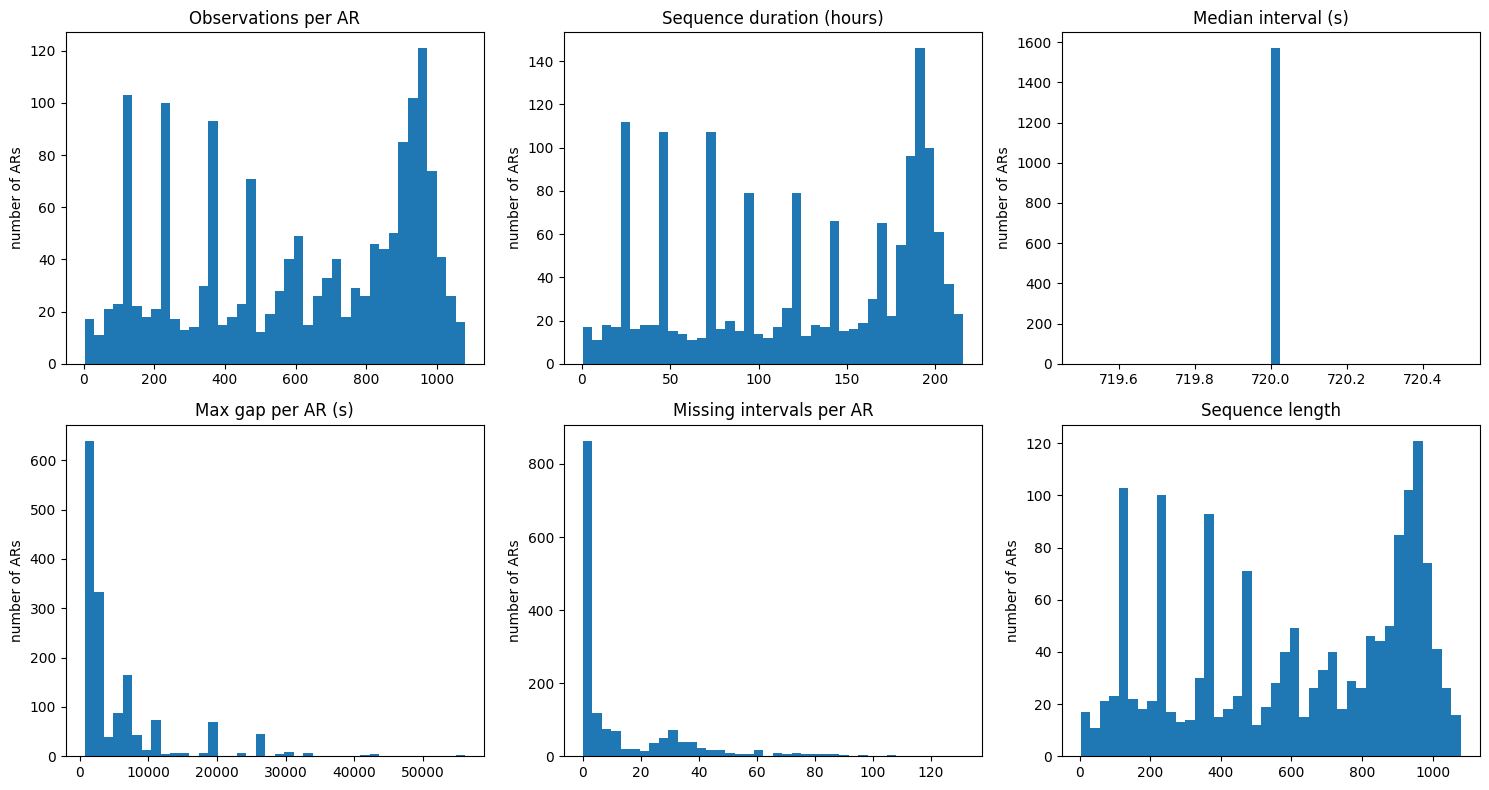

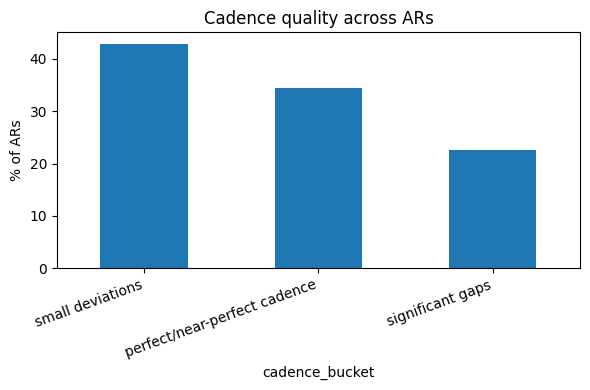

In [29]:
# T4 — plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0,0].hist(ar_temporal_summary["n_observations"], bins=40); axes[0,0].set_title("Observations per AR")
axes[0,1].hist(ar_temporal_summary["duration_hours"], bins=40); axes[0,1].set_title("Sequence duration (hours)")
axes[0,2].hist(ar_temporal_summary["median_delta_seconds"].dropna(), bins=40); axes[0,2].set_title("Median interval (s)")
axes[1,0].hist(ar_temporal_summary["max_delta_seconds"].dropna(), bins=40); axes[1,0].set_title("Max gap per AR (s)")
axes[1,1].hist(ar_temporal_summary["n_missing_intervals"], bins=40); axes[1,1].set_title("Missing intervals per AR")
axes[1,2].hist(ar_temporal_summary["sequence_length"], bins=40); axes[1,2].set_title("Sequence length")
for ax in axes.flat: ax.set_ylabel("number of ARs")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
bucket_pct.plot(kind="bar")
plt.title("Cadence quality across ARs"); plt.ylabel("% of ARs"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

ARs with only label 0:            936
ARs with at least one label 1:    634
ARs with both 0 and 1:            614

Positive-run length (consecutive positive frames within an AR), across ARs that have any:
count     634.00
mean      212.41
std       182.88
min         6.00
25%       119.25
50%       131.00
75%       250.50
max      1013.00
Name: max_pos_run, dtype: float64

Hours between the LAST positive frame and the end of that AR's sequence:
count    634.00
mean      46.59
std       54.17
min        0.00
25%        0.00
50%       24.80
75%       78.40
max      207.80
Name: hours_last_positive_to_seq_end, dtype: float64


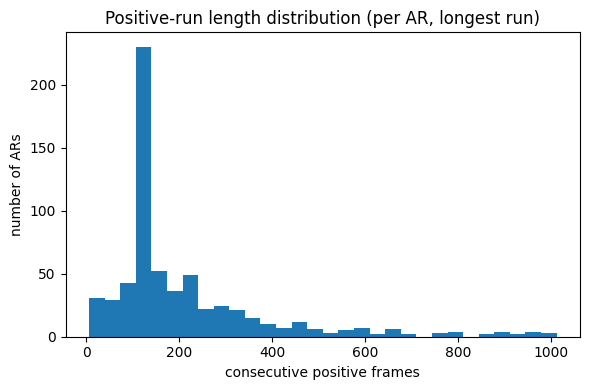

In [30]:
# T5 — label run-length analysis per AR (0-runs and 1-runs, transitions, and where
# positives sit relative to the end of the sequence)
run_rows = []
for a, b in zip(bounds[:-1], bounds[1:]):
    lab = lab_arr[a:b].astype(int)
    t = ts_s[a:b]
    n = len(lab)
    change = np.flatnonzero(np.r_[True, lab[1:] != lab[:-1], True])
    run_vals = lab[change[:-1]]; run_lens = np.diff(change)
    pos_lens = run_lens[run_vals == 1]
    trans_01 = int(((lab[:-1] == 0) & (lab[1:] == 1)).sum()) if n > 1 else 0
    trans_10 = int(((lab[:-1] == 1) & (lab[1:] == 0)).sum()) if n > 1 else 0
    has_pos = bool((lab == 1).any())
    pos_idx = np.flatnonzero(lab == 1)
    rec = dict(
        AR_number=ar_ids[a], n_observations=n,
        all_zero=bool((lab == 0).all()), has_positive=has_pos, has_both=has_pos and (lab == 0).any(),
        n_pos_runs=int(len(pos_lens)), max_pos_run=int(pos_lens.max()) if len(pos_lens) else 0,
        median_pos_run=float(np.median(pos_lens)) if len(pos_lens) else np.nan,
        n_transitions_0to1=trans_01, n_transitions_1to0=trans_10, n_transitions_total=trans_01 + trans_10,
        first_positive_timestamp=pd.Timestamp(t[pos_idx[0]], unit="s") if has_pos else pd.NaT,
        last_positive_timestamp=pd.Timestamp(t[pos_idx[-1]], unit="s") if has_pos else pd.NaT,
        hours_last_positive_to_seq_end=(t[-1] - t[pos_idx[-1]]) / 3600.0 if has_pos else np.nan,
    )
    run_rows.append(rec)
ar_label_run_summary = pd.DataFrame(run_rows)

n_all_zero = int(ar_label_run_summary["all_zero"].sum())
n_has_pos  = int(ar_label_run_summary["has_positive"].sum())
n_both     = int(ar_label_run_summary["has_both"].sum())
print(f"ARs with only label 0:            {n_all_zero}")
print(f"ARs with at least one label 1:    {n_has_pos}")
print(f"ARs with both 0 and 1:            {n_both}")

pos_only = ar_label_run_summary[ar_label_run_summary.has_positive]
print("\nPositive-run length (consecutive positive frames within an AR), across ARs that have any:")
print(pos_only["max_pos_run"].describe().round(2))
print("\nHours between the LAST positive frame and the end of that AR's sequence:")
print(pos_only["hours_last_positive_to_seq_end"].describe().round(2))

plt.figure(figsize=(6,4))
pos_only["max_pos_run"].plot(kind="hist", bins=30)
plt.title("Positive-run length distribution (per AR, longest run)"); plt.xlabel("consecutive positive frames"); plt.ylabel("number of ARs")
plt.tight_layout(); plt.show()

In [31]:
# T6 — quantifying window overlap between adjacent samples
overlap_hours = 24.0
nominal_overlap_pct = 100 * (overlap_hours - CADENCE_S/3600) / overlap_hours
print(f"At the nominal {CADENCE_S}s cadence, two consecutive frames' 24h windows overlap by "
      f"{overlap_hours - CADENCE_S/3600:.3f} of 24 h -> {nominal_overlap_pct:.2f}% overlap.")

same_label_count, total_pairs = 0, 0
for a, b in zip(bounds[:-1], bounds[1:]):
    lab = lab_arr[a:b]
    if len(lab) > 1:
        same_label_count += int((lab[1:] == lab[:-1]).sum())
        total_pairs += len(lab) - 1
print(f"Empirically, adjacent frames share the same label in {100*same_label_count/total_pairs:.2f}% of "
      f"{total_pairs:,} consecutive pairs (whole-dataset average) -- this also reflects the 80/20 class "
      "imbalance, not overlap alone, so treat it as supporting evidence, not proof by itself.")

print("""
WHY THIS HAPPENS
  label(t) = 1 means "a flare occurs somewhere in [t, t+24h]". Because t+12min is inside [t, t+24h] for
  almost its whole length, frame t and frame t+12min are asking about nearly the SAME future window, so
  they usually get the same answer. A long run of 1s does NOT mean many separate flares -- it usually
  means one flare (or cluster) is visible through many overlapping 24h windows.

WHY THIS MATTERS FOR MODELING
  Rows within an AR are NOT independent samples. This is exactly why your official split is AR-level, and
  why your AR-bootstrap (not a per-row bootstrap) is used for confidence intervals.

WHY THIS DOES NOT, BY ITSELF, MEAN LEAKAGE
  Leakage means the model gets information it shouldn't have at prediction time. Overlapping labels are a
  property of the forecasting TASK's definition (rolling 24h window), not a broken pipeline. As long as
  (a) the label was computed only from GOES data strictly AFTER the image time, and (b) splits are AR-level,
  the overlap is expected and correct -- it means consecutive frames are correlated, which is a modeling and
  evaluation consideration, not a leakage bug.
""")

At the nominal 720s cadence, two consecutive frames' 24h windows overlap by 23.800 of 24 h -> 99.17% overlap.
Empirically, adjacent frames share the same label in 99.81% of 948,477 consecutive pairs (whole-dataset average) -- this also reflects the 80/20 class imbalance, not overlap alone, so treat it as supporting evidence, not proof by itself.

WHY THIS HAPPENS
  label(t) = 1 means "a flare occurs somewhere in [t, t+24h]". Because t+12min is inside [t, t+24h] for
  almost its whole length, frame t and frame t+12min are asking about nearly the SAME future window, so
  they usually get the same answer. A long run of 1s does NOT mean many separate flares -- it usually
  means one flare (or cluster) is visible through many overlapping 24h windows.

WHY THIS MATTERS FOR MODELING
  Rows within an AR are NOT independent samples. This is exactly why your official split is AR-level, and
  why your AR-bootstrap (not a per-row bootstrap) is used for confidence intervals.

WHY THIS DOES NOT, BY 

In [32]:
# T7 — split conformity re-check (read-only) + the 3 kinds of leakage, explained
split_per_ar = T.groupby("AR")["split"].nunique()
print("ARs that appear under more than one split label:", int((split_per_ar > 1).sum()),
      "(should be 0 -- this only re-confirms cell A2's own split, nothing is changed)")

print("""
A. AR-LEVEL LEAKAGE: the same AR appears in more than one split. Already checked in your cell 4; re-confirmed above.
B. TEMPORAL LEAKAGE: a feature at time t uses information from AFTER t. Your A6 leakage canary demonstrates
   this concretely -- a 12h-lag "history" feature (which still reaches into the future, since the label
   itself covers [t, t+24h]) inflates validation TSS above the honest 24h-lag version.
C. LABEL LEAKAGE: a feature is mathematically derived from the target itself.
   These are independent checks -- passing one does not guarantee the others.
""")

ARs that appear under more than one split label: 0 (should be 0 -- this only re-confirms cell A2's own split, nothing is changed)

A. AR-LEVEL LEAKAGE: the same AR appears in more than one split. Already checked in your cell 4; re-confirmed above.
B. TEMPORAL LEAKAGE: a feature at time t uses information from AFTER t. Your A6 leakage canary demonstrates
   this concretely -- a 12h-lag "history" feature (which still reaches into the future, since the label
   itself covers [t, t+24h]) inflates validation TSS above the honest 24h-lag version.
C. LABEL LEAKAGE: a feature is mathematically derived from the target itself.
   These are independent checks -- passing one does not guarantee the others.



In [33]:
# T8 — data-quality flag table (flags only, deletes nothing)
q = ar_temporal_summary.merge(ar_label_run_summary[["AR_number","has_positive"]], on="AR_number")
q["flag_large_gap"]     = q["max_delta_seconds"] > 3 * CADENCE_S
q["flag_many_missing"]  = q["n_missing_intervals"] >= 3
q["flag_duplicates"]    = q["n_duplicate_timestamps"] > 0
q["flag_short_seq"]     = q["n_observations"] < 10
q["flag_nonmonotonic"]  = q["n_non_monotonic"] > 0
q["flag_unparseable"]   = q["n_unparseable_timestamps"] > 0
flag_cols = [c for c in q.columns if c.startswith("flag_")]
q["n_flags"] = q[flag_cols].sum(axis=1)

problem_ars = q[q["n_flags"] > 0].sort_values(["n_flags", "max_delta_seconds"], ascending=[False, False])
print(f"ARs with at least one data-quality flag: {len(problem_ars)} / {len(q)}")
display(problem_ars[["AR_number","n_observations","max_delta_seconds","n_missing_intervals",
                      "n_duplicate_timestamps","n_non_monotonic","n_unparseable_timestamps","n_flags"]].head(20))

ARs with at least one data-quality flag: 785 / 1570


,AR_number,n_observations,max_delta_seconds,n_missing_intervals,n_duplicate_timestamps,n_non_monotonic,n_unparseable_timestamps,n_flags
615,1727,747,56160.0,81,0,0,0,2
617,1729,353,56160.0,80,0,0,0,2
1563,2725,387,43920.0,68,0,0,0,2
216,1301,847,42480.0,131,0,0,0,2
217,1302,911,42480.0,122,0,0,0,2
218,1304,598,42480.0,106,0,0,0,2
219,1305,898,42480.0,111,0,0,0,2
1170,2313,781,41040.0,59,0,0,0,2
1173,2316,424,41040.0,56,0,0,0,2
22,1087,871,33840.0,106,0,0,0,2


In [34]:
# T9 — final report: compile, print, save
pct_perfect = bucket_pct.get("perfect/near-perfect cadence", 0.0)
report_temporal = f"""
TEMPORAL INTEGRITY REPORT
==========================
Tolerance used for "approximately 720s": +/-{TOL_S}s.

1. Total ARs: {T['AR'].nunique()}
2. Total observations: {len(T):,}
3. Median observations per AR: {ar_temporal_summary['n_observations'].median():.0f}
4. Median sequence duration (hours): {ar_temporal_summary['duration_hours'].median():.2f}
5. Median cadence (seconds): {ar_temporal_summary['median_delta_seconds'].median():.1f}
6. ARs with perfect/near-perfect cadence: {pct_perfect:.2f}%
7. ARs with >=1 missing interval: {(ar_temporal_summary['n_missing_intervals']>0).sum()}
8. ARs with >=1 duplicate timestamp: {(ar_temporal_summary['n_duplicate_timestamps']>0).sum()}
9. ARs with >=1 non-monotonic raw-order pair: {(ar_temporal_summary['n_non_monotonic']>0).sum()}
10. ARs containing positive labels: {n_has_pos}
11. ARs containing both 0 and 1: {n_both}
12. Median positive-run length (ARs w/ >=1): {pos_only['max_pos_run'].median():.2f}
13. Maximum positive-run length (any AR): {int(pos_only['max_pos_run'].max()) if len(pos_only) else 0}
14. CONCERNS BEFORE CNN+GRU/LSTM:
    - Handle gaps explicitly (pad/mask by real timestamp, not row position)
    - Treat consecutive frames as correlated, not independent
    - Review flagged ARs above before they enter a sequence model
"""
print(report_temporal)
ar_temporal_summary.to_csv("/kaggle/working/ar_temporal_summary.csv", index=False)
ar_label_run_summary.to_csv("/kaggle/working/ar_label_run_summary.csv", index=False)
with open("/kaggle/working/temporal_integrity_report.txt", "w") as f:
    f.write(report_temporal)
print("Saved: ar_temporal_summary.csv, ar_label_run_summary.csv, temporal_integrity_report.txt")


TEMPORAL INTEGRITY REPORT
Tolerance used for "approximately 720s": +/-60s.

1. Total ARs: 1570
2. Total observations: 950,047
3. Median observations per AR: 634
4. Median sequence duration (hours): 130.10
5. Median cadence (seconds): 720.0
6. ARs with perfect/near-perfect cadence: 34.46%
7. ARs with >=1 missing interval: 1029
8. ARs with >=1 duplicate timestamp: 0
9. ARs with >=1 non-monotonic raw-order pair: 0
10. ARs containing positive labels: 634
11. ARs containing both 0 and 1: 614
12. Median positive-run length (ARs w/ >=1): 131.00
13. Maximum positive-run length (any AR): 1013
14. CONCERNS BEFORE CNN+GRU/LSTM:
    - Handle gaps explicitly (pad/mask by real timestamp, not row position)
    - Treat consecutive frames as correlated, not independent
    - Review flagged ARs above before they enter a sequence model

Saved: ar_temporal_summary.csv, ar_label_run_summary.csv, temporal_integrity_report.txt


In [35]:
# --- Check 2: worst gap, using T's real columns (AR, ts) ---
T = T.sort_values(["AR", "ts"]).reset_index(drop=True)
T["delta_seconds"] = T.groupby("AR")["ts"].diff().dt.total_seconds()

worst_gap = T["delta_seconds"].max()
worst_rows = T[T["delta_seconds"] == worst_gap]
print("Max gap (s):", worst_gap)
print(worst_rows[["AR", "ts", "delta_seconds", "label", "filename"]])

for ar in worst_rows["AR"].unique():
    sub = T[T["AR"] == ar].reset_index(drop=True)
    idx = sub.index[sub["delta_seconds"] == worst_gap][0]
    display(sub.loc[max(0, idx-2):idx+2, ["AR", "ts", "delta_seconds", "label", "flare_size", "filename"]])

Max gap (s): 56160.0
          AR                  ts  delta_seconds  label  \
369081  1727 2013-04-24 19:12:00        56160.0      0   
370330  1729 2013-04-24 19:12:00        56160.0      0   

                                                 filename  
369081  1727_hmi.M_720s.20130424_191200_TAI.1.magnetog...  
370330  1729_hmi.M_720s.20130424_191200_TAI.1.magnetog...  


,AR,ts,delta_seconds,label,flare_size,filename
401,1727,2013-04-24 03:24:00,720.0,0,0,1727_hmi.M_720s.20130424_032400_TAI.1.magnetog...
402,1727,2013-04-24 03:36:00,720.0,0,0,1727_hmi.M_720s.20130424_033600_TAI.1.magnetog...
403,1727,2013-04-24 19:12:00,56160.0,0,0,1727_hmi.M_720s.20130424_191200_TAI.1.magnetog...
404,1727,2013-04-24 19:24:00,720.0,0,0,1727_hmi.M_720s.20130424_192400_TAI.1.magnetog...
405,1727,2013-04-24 19:36:00,720.0,0,0,1727_hmi.M_720s.20130424_193600_TAI.1.magnetog...


,AR,ts,delta_seconds,label,flare_size,filename
17,1729,2013-04-24 03:24:00,720.0,0,0,1729_hmi.M_720s.20130424_032400_TAI.1.magnetog...
18,1729,2013-04-24 03:36:00,720.0,0,0,1729_hmi.M_720s.20130424_033600_TAI.1.magnetog...
19,1729,2013-04-24 19:12:00,56160.0,0,0,1729_hmi.M_720s.20130424_191200_TAI.1.magnetog...
20,1729,2013-04-24 19:24:00,720.0,0,0,1729_hmi.M_720s.20130424_192400_TAI.1.magnetog...
21,1729,2013-04-24 19:36:00,720.0,0,0,1729_hmi.M_720s.20130424_193600_TAI.1.magnetog...


In [36]:
# --- Check 3: longest positive run, using T's real columns ---
T["run_id"] = (T["label"] != T.groupby("AR")["label"].shift()).cumsum()
runs = T[T["label"] == 1].groupby("run_id").agg(
    AR=("AR", "first"), start_ts=("ts", "first"), end_ts=("ts", "last"), n_frames=("ts", "size")
)
longest = runs.sort_values("n_frames", ascending=False).head(1)
display(longest)

ar_ = longest["AR"].iloc[0]
start_, end_ = longest["start_ts"].iloc[0], longest["end_ts"].iloc[0]
seg = T[(T["AR"] == ar_) & (T["ts"] >= start_) & (T["ts"] <= end_)]
display(seg[["AR", "ts", "delta_seconds", "label", "flare_size"]])
print("Duration:", (end_ - start_).total_seconds()/3600, "hours")

,AR,start_ts,end_ts,n_frames
run_id,,,,
1794,1967,2014-01-30,2014-02-07 13:48:00,1013


,AR,ts,delta_seconds,label,flare_size
504154,1967,2014-01-30 00:00:00,NaN,1,M6.6
504155,1967,2014-01-30 00:12:00,720.0,1,M6.6
504156,1967,2014-01-30 00:24:00,720.0,1,M6.6
504157,1967,2014-01-30 00:36:00,720.0,1,M6.6
504158,1967,2014-01-30 00:48:00,720.0,1,M6.6
...,...,...,...,...,...
505162,1967,2014-02-07 13:00:00,720.0,1,C3.2
505163,1967,2014-02-07 13:12:00,720.0,1,C3.2
505164,1967,2014-02-07 13:24:00,720.0,1,C3.2
505165,1967,2014-02-07 13:36:00,720.0,1,C3.2


Duration: 205.8 hours


In [37]:
# A3 — XGBoost baseline "A" on the 29 raw features (minus the 2 constants)
import xgboost as xgb

XGB_PARAMS = dict(
    n_estimators=3000, learning_rate=0.05, max_depth=5,
    min_child_weight=60,            # large leaves: frames from one AR are near-duplicates, so don't let trees memorise them
    subsample=0.5, colsample_bytree=0.6, reg_lambda=10.0,
    tree_method="hist", eval_metric="aucpr", early_stopping_rounds=60,
    random_state=CFG["seed"], n_jobs=-1,
)
# NOTE: no scale_pos_weight on purpose -> probabilities stay closer to calibrated; the threshold handles imbalance.
try:                                   # use the GPU automatically if the notebook has one
    import torch
    XGB_PARAMS["device"] = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    XGB_PARAMS["device"] = "cpu"
print("XGBoost device:", XGB_PARAMS["device"])

def fit_gbdt(Xtr, ytr, Xva, yva, params=XGB_PARAMS):
    m = xgb.XGBClassifier(**params)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m

y_all = T["label"].to_numpy().astype(int)
M_tr, M_va, M_te = [(T.split == s).to_numpy() for s in ("train", "val", "test")]
ar_all = T["AR"].to_numpy()

XA = T[base_cols].astype(np.float32)
t0 = time.time()
mA = fit_gbdt(XA[M_tr], y_all[M_tr], XA[M_va], y_all[M_va])
pA_va = mA.predict_proba(XA[M_va])[:, 1]
thrA = best_tss_threshold(y_all[M_va], pA_va)
repA = full_report(y_all[M_va], pA_va, thrA)
print(f"[A raw-29] best_iter={mA.best_iteration}  {time.time()-t0:.0f}s")
print({k: round(float(v), 4) for k, v in repA.items() if k in ("ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS")})

# which base features deserve the temporal treatment (importance measured on the TRAIN-fitted model only)
imp = pd.Series(mA.get_booster().get_score(importance_type="gain")).reindex(base_cols).fillna(0).sort_values(ascending=False)
top_names = list(imp.index[:CFG["top_k"]])
print("Top features for temporal treatment:", top_names)

XGBoost device: cuda
[A raw-29] best_iter=151  4s
{'ROC_AUC': 0.8363, 'PR_AUC': 0.6236, 'BSS': 0.2885, 'TSS': 0.5136, 'HSS': 0.4366}
Top features for temporal treatment: ['feature_1', 'feature_22', 'feature_0', 'feature_28', 'feature_4', 'feature_8', 'feature_10', 'feature_25', 'feature_21', 'feature_13']


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [07:03:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [38]:
# A4 — temporal features (past-only) computed on the FULL 12-min series
def slog(x): return np.sign(x) * np.log1p(np.abs(x))

Z_all = slog(T[base_cols].to_numpy(np.float64))
mu, sd = Z_all[M_tr].mean(0), Z_all[M_tr].std(0) + 1e-9        # statistics from TRAIN rows only
Z = (Z_all - mu) / sd

def _csum(a): return np.concatenate([[0.0], np.cumsum(a)])

def roll_stats(x, start, want_kurt=False):
    """mean, std (and excess kurtosis) over the window [start[i] .. i], i.e. past + current frame only."""
    idx = np.arange(len(x)); n = (idx + 1 - start).astype(float)
    c1, c2 = _csum(x), _csum(x ** 2)
    s1, s2 = c1[idx + 1] - c1[start], c2[idx + 1] - c2[start]
    m = s1 / n; var = np.maximum(s2 / n - m ** 2, 0.0)
    res = [m, np.sqrt(var)]
    if want_kurt:
        c3, c4 = _csum(x ** 3), _csum(x ** 4)
        s3, s4 = c3[idx + 1] - c3[start], c4[idx + 1] - c4[start]
        m4 = (s4 - 4 * m * s3 + 6 * m ** 2 * s2 - 4 * m ** 3 * s1 + n * m ** 4) / n
        with np.errstate(divide="ignore", invalid="ignore"):
            k = m4 / var ** 2 - 3.0
        k[(n < 8) | (var < 1e-8)] = np.nan
        res.append(k)
    return res

def lag_index(t, lag_s, tol_s):
    """Index of the last frame with time <= t - lag (and within tol of it); -1 if none."""
    j = np.searchsorted(t, t - lag_s, side="right") - 1
    ok = j >= 0
    ok[ok] = t[j[ok]] >= (t[ok] - lag_s - tol_s)
    return np.where(ok, j, -1)

def build_features(T, Z, top_idx, names, cfg=CFG):
    n = len(T)
    ts = T["ts"].to_numpy("datetime64[s]").astype(np.int64)
    ar = T["AR"].to_numpy()
    lab = T["label"].to_numpy(np.float64); fsc = T["fscore"].to_numpy(np.float64)
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    tol = cfg["lag_tol_min"] * 60; H = int(cfg["hist_lag_h"] * 3600)
    cols = {}
    def alloc(k): cols[k] = np.full(n, np.nan, np.float32)
    for c in names:
        alloc(f"{c}_m{cfg['roll_h']}h"); alloc(f"{c}_s{cfg['roll_h']}h")
        for kh in cfg["kurt_h"]: alloc(f"{c}_k{kh}h")
        for dh in cfg["diff_h"]: alloc(f"{c}_d{dh}h")
    for k in ("age_h", "hist24_flag", "hist24_score"): alloc(k)
    hist_src = np.full(n, -1, np.int64)
    for a, b in zip(bounds[:-1], bounds[1:]):
        t = ts[a:b]
        starts = {h: np.searchsorted(t, t - int(h * 3600), side="left") for h in {cfg["roll_h"], *cfg["kurt_h"]}}
        lags = {h: lag_index(t, int(h * 3600), tol) for h in cfg["diff_h"]}
        for ci, c in zip(top_idx, names):
            x = Z[a:b, ci]
            m, s = roll_stats(x, starts[cfg["roll_h"]])
            cols[f"{c}_m{cfg['roll_h']}h"][a:b] = m; cols[f"{c}_s{cfg['roll_h']}h"][a:b] = s
            for kh in cfg["kurt_h"]:
                cols[f"{c}_k{kh}h"][a:b] = roll_stats(x, starts[kh], True)[2]
            for dh in cfg["diff_h"]:
                j = lags[dh]
                cols[f"{c}_d{dh}h"][a:b] = np.where(j >= 0, x - x[np.maximum(j, 0)], np.nan)
        cols["age_h"][a:b] = (t - t[0]) / 3600.0
        jh = lag_index(t, H, tol); ok = jh >= 0; jj = np.maximum(jh, 0)
        cols["hist24_flag"][a:b] = np.where(ok, lab[a:b][jj], np.nan)
        cols["hist24_score"][a:b] = np.where(ok, fsc[a:b][jj], np.nan)
        hist_src[a:b] = np.where(ok, t[jj], -1)
    return pd.DataFrame(cols), hist_src, ts

top_idx = [base_cols.index(c) for c in top_names]
FE, hist_src, ts_sec = build_features(T, Z, top_idx, top_names)

# ---- LEAKAGE GUARD: the label window of the source frame must END before "now" ----
ok = hist_src >= 0
assert np.all(hist_src[ok] + CFG["hist_lag_h"] * 3600 <= ts_sec[ok]), "LEAK: history window reaches into the future"
print("Leakage guard passed. History available for", round(100 * ok.mean(), 1), "% of rows")

temporal_cols = [c for c in FE.columns if not c.startswith("hist24") and c != "age_h"]
hist_cols = ["hist24_flag", "hist24_score"]
X_all = pd.concat([XA.reset_index(drop=True), FE], axis=1)
print("Feature matrix:", X_all.shape, "| temporal:", len(temporal_cols), "| history:", hist_cols)

Leakage guard passed. History available for 80.2 % of rows
Feature matrix: (950047, 120) | temporal: 90 | history: ['hist24_flag', 'hist24_score']


In [39]:
# A5 — ablation on VALIDATION: A raw -> B +temporal -> C +flare history
sets = {
    "A_raw29":             base_cols,
    "B_+temporal":         base_cols + temporal_cols + ["age_h"],
    "C_+temporal+history": base_cols + temporal_cols + ["age_h"] + hist_cols,
}
models, val_probs, rows = {}, {}, {}
for name, cols in sets.items():
    t0 = time.time()
    m = fit_gbdt(X_all.loc[M_tr, cols], y_all[M_tr], X_all.loc[M_va, cols], y_all[M_va])
    p = m.predict_proba(X_all.loc[M_va, cols])[:, 1]
    thr = best_tss_threshold(y_all[M_va], p)
    models[name], val_probs[name] = (m, thr, cols), p
    rows[name] = {**full_report(y_all[M_va], p, thr), "best_iter": m.best_iteration, "sec": round(time.time() - t0)}
abl = pd.DataFrame(rows).T[["ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "POD", "FPR", "FAR", "best_iter", "sec"]].astype(float).round(4)
display(abl)
print("Reference (same benchmark, test set): Boucheron SVM TSS 0.5348 | VGG16 TSS 0.5325")

,ROC_AUC,PR_AUC,BSS,TSS,HSS,POD,FPR,FAR,best_iter,sec
A_raw29,0.8363,0.6236,0.2885,0.5136,0.4366,0.7122,0.1986,0.5176,151.0,3.0
B_+temporal,0.8394,0.6299,0.2931,0.5092,0.3952,0.7712,0.2620,0.5666,86.0,14.0
C_+temporal+history,0.8574,0.6770,0.3344,0.5410,0.4694,0.7207,0.1797,0.4896,47.0,14.0


Reference (same benchmark, test set): Boucheron SVM TSS 0.5348 | VGG16 TSS 0.5325


In [40]:
# A6 — LEAKAGE CANARY (proves the pipeline can detect leakage; never use this feature for real)
def lagged_label(T, hours):
    n = len(T); out = np.full(n, np.nan, np.float32)
    ar = T["AR"].to_numpy(); lab = T["label"].to_numpy(np.float64)
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    for a, b in zip(bounds[:-1], bounds[1:]):
        t = ts_sec[a:b]; j = lag_index(t, int(hours * 3600), CFG["lag_tol_min"] * 60)
        out[a:b] = np.where(j >= 0, lab[a:b][np.maximum(j, 0)], np.nan)
    return out

X_can = X_all.copy(); X_can["LEAKY_12h"] = lagged_label(T, 12)   # label 12 h ago covers 12 h of the FUTURE -> leaks
cols_c = sets["C_+temporal+history"] + ["LEAKY_12h"]
m = fit_gbdt(X_can.loc[M_tr, cols_c], y_all[M_tr], X_can.loc[M_va, cols_c], y_all[M_va])
p = m.predict_proba(X_can.loc[M_va, cols_c])[:, 1]
print("CANARY val TSS (leaky 12h lag):", round(skill_scores(y_all[M_va], (p >= best_tss_threshold(y_all[M_va], p)).astype(int))["TSS"], 4),
      "  vs honest C:", round(abl.loc["C_+temporal+history", "TSS"], 4))
del X_can

CANARY val TSS (leaky 12h lag): 0.7095   vs honest C: 0.541


In [41]:
# A7 — does subsampling lose information? (learning curve over the time stride, 3 repeats per stride)
rank_in_ar = T.groupby("AR").cumcount().to_numpy()      # 0,1,2,... within each AR (12-min steps)
cols_b = sets["B_+temporal"]
Xva_b, yva_b = X_all.loc[M_va, cols_b], y_all[M_va]
rows = []
for stride in (120, 60, 20, 5, 1):                       # 120 ~ 1 frame per 24 h ... 1 = every frame
    for rep in range(3):                                 # repeat: different seed AND different frame phase
        sel = M_tr & (rank_in_ar % stride == (rep * 7) % stride)
        m = fit_gbdt(X_all.loc[sel, cols_b], y_all[sel], Xva_b, yva_b, params={**XGB_PARAMS, "random_state": CFG["seed"] + rep})
        p = m.predict_proba(Xva_b)[:, 1]
        rows.append(dict(stride=stride, rep=rep, train_rows=int(sel.sum()), best_iter=m.best_iteration,
                         PR_AUC=average_precision_score(yva_b, p), ROC_AUC=roc_auc_score(yva_b, p)))
a7 = pd.DataFrame(rows)
display(a7.groupby("stride", sort=False).agg(train_rows=("train_rows", "mean"), PR_AUC_mean=("PR_AUC", "mean"),
        PR_AUC_sd=("PR_AUC", "std"), PR_AUC_min=("PR_AUC", "min"), PR_AUC_max=("PR_AUC", "max"),
        ROC_AUC_mean=("ROC_AUC", "mean"), best_iter=("best_iter", "mean")).round(4))

,train_rows,PR_AUC_mean,PR_AUC_sd,PR_AUC_min,PR_AUC_max,ROC_AUC_mean,best_iter
stride,,,,,,,
120,6721.0000,0.6295,0.0042,0.6263,0.6342,0.8381,77.0000
60,13023.6667,0.6321,0.0032,0.6290,0.6354,0.8414,87.6667
20,38097.0000,0.6347,0.0012,0.6337,0.6360,0.8417,61.6667
5,151873.3333,0.6342,0.0010,0.6332,0.6352,0.8397,120.3333
1,759357.0000,0.6311,0.0019,0.6299,0.6333,0.8395,80.0000


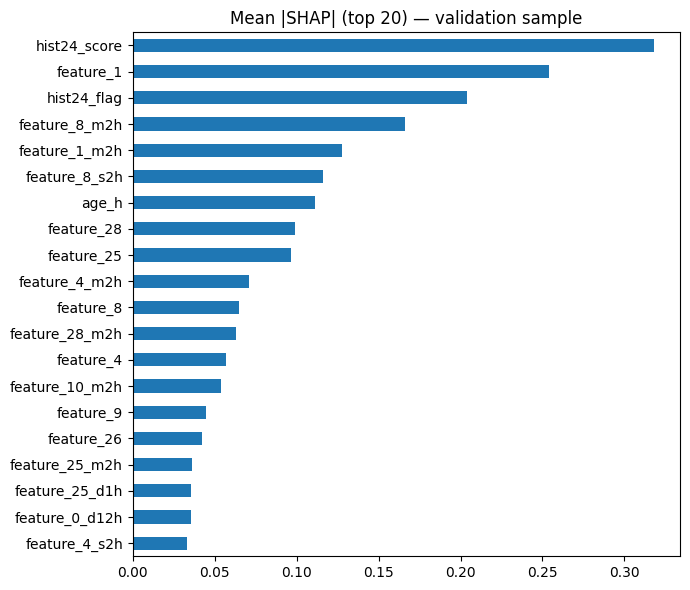

In [42]:
# A8 — what does the model use? (native XGBoost SHAP, no extra library)
import matplotlib.pyplot as plt
name = "C_+temporal+history"; m, thr, cols = models[name]
idx = np.random.default_rng(CFG["seed"]).choice(np.flatnonzero(M_va), min(20000, int(M_va.sum())), replace=False)
contrib = m.get_booster().predict(xgb.DMatrix(X_all.iloc[idx][cols]), pred_contribs=True)[:, :-1]
imp_shap = pd.Series(np.abs(contrib).mean(0), index=cols).sort_values(ascending=False).head(20)
imp_shap[::-1].plot(kind="barh", figsize=(7, 6)); plt.title("Mean |SHAP| (top 20) — validation sample"); plt.tight_layout(); plt.show()

In [43]:
# A10 — paired AR-bootstrap on VALIDATION: are C / A / SVM really different?  (TEST stays locked)
# 1) SVM scores from your cell 14, re-ordered into T's row order (T is sorted by AR,time; val_data is not)
fn_to_score = pd.Series(np.asarray(val_scores), index=val_data["filename"].to_numpy())
assert fn_to_score.index.is_unique, "filenames are not unique -> cannot align"
svm_va = fn_to_score.reindex(T.loc[M_va, "filename"].to_numpy()).to_numpy()
assert not np.isnan(svm_va).any(), "SVM score alignment failed"
assert abs(roc_auc_score(y_all[M_va], svm_va) - roc_auc_score(y_val, val_scores)) < 1e-9, "alignment check failed"

y_v, ar_v = y_all[M_va], ar_all[M_va]
S = {"SVM": (svm_va, best_thresh),
     "A_raw29": (val_probs["A_raw29"], models["A_raw29"][1]),
     "C_+temporal+history": (val_probs["C_+temporal+history"], models["C_+temporal+history"][1])}

b_codes, b_uniq = pd.factorize(ar_v); b_k = len(b_uniq)
b_order = np.argsort(b_codes, kind="stable")
b_grp = np.split(b_order, np.cumsum(np.bincount(b_codes, minlength=b_k))[:-1])      # row positions per AR
b_cnt = {}
for nm, (s_, thr_) in S.items():
    pr_ = (s_ >= thr_).astype(int)
    b_cnt[nm] = np.stack([np.bincount(b_codes, weights=mk.astype(float), minlength=b_k) for mk in
                          [(y_v == 1) & (pr_ == 1), (y_v == 1) & (pr_ == 0), (y_v == 0) & (pr_ == 1), (y_v == 0) & (pr_ == 0)]], 1)

N_BOOT = 300                                   # raise to 1000 if time allows
b_rng = np.random.default_rng(CFG["seed"])
boot = {nm: {"TSS": [], "PR_AUC": []} for nm in S}
for _ in range(N_BOOT):
    draw = b_rng.integers(0, b_k, b_k)          # resample WHOLE ARs; same draw for every model = paired
    idx = np.concatenate([b_grp[g] for g in draw])
    for nm, (s_, thr_) in S.items():
        tp, fn_, fp, tn = b_cnt[nm][draw].sum(0)
        boot[nm]["TSS"].append(tp / (tp + fn_) - fp / (fp + tn))
        boot[nm]["PR_AUC"].append(average_precision_score(y_v[idx], s_[idx]))

point = {nm: dict(TSS=skill_scores(y_v, (s_ >= thr_).astype(int))["TSS"], PR_AUC=average_precision_score(y_v, s_)) for nm, (s_, thr_) in S.items()}
out = []
for a_, b_ in [("C_+temporal+history", "A_raw29"), ("C_+temporal+history", "SVM"), ("A_raw29", "SVM")]:
    for met in ("PR_AUC", "TSS"):
        d = np.array(boot[a_][met]) - np.array(boot[b_][met])
        lo, hi = np.nanpercentile(d, [2.5, 97.5])
        out.append({"difference": f"{a_} - {b_}", "metric": met, "point_diff": point[a_][met] - point[b_][met],
                    "CI95_low": lo, "CI95_high": hi, "P(diff>0)": np.nanmean(d > 0)})
display(pd.DataFrame(out).round(4))
print("Point estimates:", {nm: {k_: round(float(v), 4) for k_, v in d.items()} for nm, d in point.items()})
print("Read: a CI that contains 0 means the difference is NOT distinguishable from AR-sampling noise (157 validation ARs).")

,difference,metric,point_diff,CI95_low,CI95_high,P(diff>0)
0,C_+temporal+history - A_raw29,PR_AUC,0.0534,0.0118,0.1068,0.9967
1,C_+temporal+history - A_raw29,TSS,0.0274,-0.0205,0.0766,0.8967
2,C_+temporal+history - SVM,PR_AUC,0.0269,-0.0159,0.0784,0.8700
3,C_+temporal+history - SVM,TSS,0.0233,-0.0282,0.0706,0.8100
4,A_raw29 - SVM,PR_AUC,-0.0264,-0.0608,-0.0004,0.0267
5,A_raw29 - SVM,TSS,-0.0041,-0.0366,0.0286,0.3933


Point estimates: {'SVM': {'TSS': 0.5177, 'PR_AUC': 0.65}, 'A_raw29': {'TSS': 0.5136, 'PR_AUC': 0.6236}, 'C_+temporal+history': {'TSS': 0.541, 'PR_AUC': 0.677}}
Read: a CI that contains 0 means the difference is NOT distinguishable from AR-sampling noise (157 validation ARs).


In [44]:
# A11 — what carries the gain? (validation only, 3 seeds each; TEST stays locked)
sets2 = {
    "C_full":          sets["C_+temporal+history"],
    "C_minus_age_h":   [c for c in sets["C_+temporal+history"] if c != "age_h"],
    "A_raw+history":   base_cols + hist_cols,          # raw-29 + the two 24h-history features, no temporal stats, no age
}
rows = []
for nm, cols in sets2.items():
    for seed_ in (42, 43, 44):
        m = fit_gbdt(X_all.loc[M_tr, cols], y_all[M_tr], X_all.loc[M_va, cols], y_all[M_va],
                     params={**XGB_PARAMS, "random_state": seed_})
        p = m.predict_proba(X_all.loc[M_va, cols])[:, 1]
        r = full_report(y_all[M_va], p, best_tss_threshold(y_all[M_va], p))
        rows.append(dict(set=nm, seed=seed_, best_iter=m.best_iteration, **{k_: r[k_] for k_ in ("PR_AUC", "ROC_AUC", "BSS", "TSS", "HSS")}))
a11 = pd.DataFrame(rows)
display(a11.groupby("set", sort=False)[["PR_AUC", "ROC_AUC", "BSS", "TSS", "HSS", "best_iter"]].agg(["mean", "std"]).round(4))

PR_AUC         ROC_AUC             BSS             TSS          \
                 mean     std    mean     std    mean     std    mean     std   
set                                                                             
C_full         0.6766  0.0005  0.8573  0.0006  0.3378  0.0032  0.5429  0.0021   
C_minus_age_h  0.6746  0.0006  0.8557  0.0003  0.3296  0.0061  0.5512  0.0034   
A_raw+history  0.6677  0.0035  0.8530  0.0010  0.3126  0.0217  0.5512  0.0043   

                  HSS         best_iter           
                 mean     std      mean      std  
set                                               
C_full         0.4448  0.0216      63.0  14.4222  
C_minus_age_h  0.4473  0.0125      44.0   7.0000  
A_raw+history  0.4549  0.0201      48.0  30.7896

In [45]:
# A12 — GroupKFold by AR on the TRAIN ARs only: how much do scores move with WHICH ARs you train on?
from sklearn.model_selection import GroupKFold
idx_tr = np.flatnonzero(M_tr)
cv_models = {"A_raw29": sets["A_raw29"], "C_+temporal+history": sets["C_+temporal+history"]}
n_it = {nm: models[nm][0].best_iteration + 1 for nm in cv_models}            # tree count fixed from the validation run
thr_cv = {nm: models[nm][1] for nm in cv_models}                            # validation-derived threshold, not re-tuned per fold
Xn = {nm: X_all[cols].to_numpy(np.float32) for nm, cols in cv_models.items()}
p_fix = {k_: v for k_, v in XGB_PARAMS.items() if k_ != "early_stopping_rounds"}
rows = []
for f_, (a_i, b_i) in enumerate(GroupKFold(n_splits=5).split(idx_tr, groups=ar_all[idx_tr])):
    tr_i, te_i = idx_tr[a_i], idx_tr[b_i]
    assert not (set(ar_all[tr_i]) & set(ar_all[te_i])), "AR overlap between folds"
    for nm in cv_models:
        mm = xgb.XGBClassifier(**{**p_fix, "n_estimators": n_it[nm]}).fit(Xn[nm][tr_i], y_all[tr_i], verbose=False)
        pp = mm.predict_proba(Xn[nm][te_i])[:, 1]
        r = full_report(y_all[te_i], pp, thr_cv[nm])
        rows.append(dict(fold=f_, model=nm, n_ARs=len(np.unique(ar_all[te_i])), **{k_: r[k_] for k_ in ("PR_AUC", "ROC_AUC", "BSS", "TSS")}))
a12 = pd.DataFrame(rows)
display(a12.groupby("model", sort=False)[["PR_AUC", "ROC_AUC", "BSS", "TSS"]].agg(["mean", "std"]).round(4))
pv = a12.pivot(index="fold", columns="model", values=["PR_AUC", "TSS"])
for met in ("PR_AUC", "TSS"):
    d = pv[met]["C_+temporal+history"] - pv[met]["A_raw29"]
    print(f"C - A  {met}: mean {d.mean():+.4f}  sd {d.std():.4f}  C better in {(d > 0).sum()}/5 folds")
del Xn

PR_AUC         ROC_AUC             BSS             TSS  \
                       mean     std    mean     std    mean     std    mean   
model                                                                         
A_raw29              0.5670  0.0500  0.8133  0.0167  0.2398  0.0396  0.4533   
C_+temporal+history  0.6281  0.0384  0.8405  0.0182  0.2989  0.0335  0.5151   

                             
                        std  
model                        
A_raw29              0.0401  
C_+temporal+history  0.0289

C - A  PR_AUC: mean +0.0611  sd 0.0226  C better in 5/5 folds
C - A  TSS: mean +0.0618  sd 0.0160  C better in 5/5 folds


In [46]:
# B1 — CNN track: imports, config, GPU check
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

B_CFG = dict(
    seed=CFG["seed"],
    img_size=224,            # native PNG resolution (cell 2) — no resize unless memory forces it later
    batch_size_probe=32,     # sanity-check batch size only, NOT the real training batch size
    n_pixel_sample=2000,     # TRAIN images sampled to compute normalization stats
    n_path_check=500,        # rows per split checked for a missing file
)

def img_path(row):
    """Same on-disk convention as your cell 2: IMAGE_ROOT_REAL / AR_number / filename."""
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

set_all_seeds(B_CFG["seed"])
print("B1 ready.")

Torch: 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
B1 ready.


In [47]:
# B2 — path integrity check + TRAIN-only pixel statistics
rng_b = np.random.default_rng(B_CFG["seed"])

def check_paths(data, name, n):
    sample = data.sample(min(n, len(data)), random_state=B_CFG["seed"])
    missing = [(r["AR_number"], r["filename"]) for _, r in sample.iterrows() if not img_path(r).exists()]
    print(f"{name}: checked {len(sample)} paths, missing = {len(missing)}")
    if missing:
        print("  e.g.", missing[:5])
    return missing

miss_tr = check_paths(train_data, "train", B_CFG["n_path_check"])
miss_va = check_paths(val_data, "val", B_CFG["n_path_check"])
miss_te = check_paths(test_data, "test", B_CFG["n_path_check"])
assert not (miss_tr or miss_va or miss_te), "Some sampled image files are missing — fix before building the Dataset."

# --- Pixel statistics, TRAIN rows only ---
sample_rows = train_data.sample(min(B_CFG["n_pixel_sample"], len(train_data)), random_state=B_CFG["seed"])
sum_px = sumsq_px = 0.0
n_px = 0
gmin, gmax = 255.0, 0.0
modes = set()
for _, r in sample_rows.iterrows():
    with Image.open(img_path(r)) as im:
        modes.add(im.mode)
        arr = np.asarray(im, dtype=np.float64)
    gmin = min(gmin, arr.min()); gmax = max(gmax, arr.max())
    sum_px += arr.sum(); sumsq_px += (arr ** 2).sum(); n_px += arr.size

mean_px = sum_px / n_px
std_px = float(np.sqrt(sumsq_px / n_px - mean_px ** 2))
print("Image modes seen:", modes)
print(f"Pixel range: [{gmin}, {gmax}]")
print(f"Raw (0-255) pixel mean={mean_px:.3f}, std={std_px:.3f}  (TRAIN sample, n={len(sample_rows)} images)")

PIXEL_MEAN, PIXEL_STD = mean_px / 255.0, std_px / 255.0
print(f"Normalized (0-1 scale): mean={PIXEL_MEAN:.4f}, std={PIXEL_STD:.4f}  <- used by B3")

train: checked 500 paths, missing = 0
val: checked 500 paths, missing = 0
test: checked 500 paths, missing = 0
Image modes seen: {'L'}
Pixel range: [0.0, 255.0]
Raw (0-255) pixel mean=127.498, std=4.635  (TRAIN sample, n=2000 images)
Normalized (0-1 scale): mean=0.5000, std=0.0182  <- used by B3


In [48]:
# B3 — CNN-0 sanity check: NOT real training, just pipeline verification
class MagnetogramDataset(Dataset):
    """Lazy-loading, single-channel, normalized with TRAIN-only mean/std from B2."""
    def __init__(self, data, mean=PIXEL_MEAN, std=PIXEL_STD):
        self.rows = data[["AR_number", "filename", "label"]].reset_index(drop=True)
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR_number"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        arr = ((arr - self.mean) / (self.std + 1e-8)).astype(np.float32)   # <- fixed: stay float32
        x = torch.from_numpy(arr).unsqueeze(0)          # (1, H, W) single channel — no fake RGB yet
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

# tiny AR-aware subset (whole ARs, not random frames — exercises the "many frames per AR" reality)
probe_train_ars = rng_b.choice(train_data["AR_number"].unique(), size=5, replace=False)
probe_val_ars = rng_b.choice(val_data["AR_number"].unique(), size=2, replace=False)
probe_train = train_data[train_data["AR_number"].isin(probe_train_ars)]
probe_val = val_data[val_data["AR_number"].isin(probe_val_ars)]
print("Probe sizes -> train:", len(probe_train), " val:", len(probe_val))
print("Probe train label balance:\n", probe_train["label"].value_counts())

probe_train_dl = DataLoader(MagnetogramDataset(probe_train), batch_size=B_CFG["batch_size_probe"], shuffle=True, num_workers=2)
probe_val_dl = DataLoader(MagnetogramDataset(probe_val), batch_size=B_CFG["batch_size_probe"], shuffle=False, num_workers=2)

xb, yb = next(iter(probe_train_dl))
print("Batch x shape:", xb.shape, "dtype:", xb.dtype, "| batch y shape:", yb.shape)
print("x min/max/mean:", xb.min().item(), xb.max().item(), xb.mean().item())

class TinyProbeCNN(nn.Module):
    """Pipeline-verification model only — NOT the real CNN-1 baseline architecture."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(4),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(16, 1)

    def forward(self, x):
        return self.head(self.net(x).flatten(1)).squeeze(1)

torch.manual_seed(B_CFG["seed"])
probe_model = TinyProbeCNN().to(device)
opt = torch.optim.Adam(probe_model.parameters(), lr=1e-3)
lossf = nn.BCEWithLogitsLoss()

losses = []
probe_model.train()
for step, (xb, yb) in enumerate(probe_train_dl):
    xb, yb = xb.to(device), yb.to(device)
    opt.zero_grad()
    loss = lossf(probe_model(xb), yb)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step >= 9:
        break

print("Loss over 10 probe steps:", [round(l, 4) for l in losses])
print("Loss decreasing overall:", losses[-1] < losses[0])

probe_model.eval()
with torch.no_grad():
    xb, yb = next(iter(probe_val_dl))
    val_out = torch.sigmoid(probe_model(xb.to(device)))
print("Val probe batch predicted-prob range:", val_out.min().item(), val_out.max().item())
print("\nB3 sanity check complete — discard probe_model, it is not a trained model.")

Probe sizes -> train: 4046  val: 1761
Probe train label balance:
 label
0    2719
1    1327
Name: count, dtype: int64
Batch x shape: torch.Size([32, 1, 224, 224]) dtype: torch.float32 | batch y shape: torch.Size([32])
x min/max/mean: -19.09273338317871 17.583446502685547 0.07587920129299164
Loss over 10 probe steps: [0.7195, 0.7231, 0.7417, 0.7464, 0.7318, 0.7099, 0.7144, 0.7093, 0.6969, 0.7107]
Loss decreasing overall: True
Val probe batch predicted-prob range: 0.5212959051132202 0.5244068503379822

B3 sanity check complete — discard probe_model, it is not a trained model.


In [49]:
# B4 — CNN-1 config: full split tables (from T, with real timestamps), class balance, hyperparameters
T_train = T[T.split == "train"].reset_index(drop=True)
T_val   = T[T.split == "val"].reset_index(drop=True)
T_test  = T[T.split == "test"].reset_index(drop=True)
print("CNN split sizes -> train:", len(T_train), " val:", len(T_val), " test:", len(T_test))
assert len(T_train) == len(train_data) and len(T_val) == len(val_data) and len(T_test) == len(test_data), \
    "T-derived splits must match train_data/val_data/test_data row counts"

n_pos, n_neg = int(T_train["label"].sum()), int((T_train["label"] == 0).sum())
POS_WEIGHT = n_neg / n_pos
print(f"TRAIN label balance: pos={n_pos} neg={n_neg} -> pos_weight={POS_WEIGHT:.3f}")

CNN1_CFG = dict(
    seed=CFG["seed"],
    batch_size=64,
    num_workers=4,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=15,
    early_stop_patience=3,        # stop if val PR-AUC hasn't improved in this many epochs
    time_bin_hours=6,             # per-epoch TRAIN subsampling: 1 random frame per AR per this many hours
    checkpoint_path="/kaggle/working/cnn1_best.pt",
)
print("B4 ready:", CNN1_CFG)

CNN split sizes -> train: 759357  val: 95933  test: 94757
TRAIN label balance: pos=149249 neg=610108 -> pos_weight=4.088
B4 ready: {'seed': 42, 'batch_size': 64, 'num_workers': 4, 'lr': 0.001, 'weight_decay': 0.0001, 'max_epochs': 15, 'early_stop_patience': 3, 'time_bin_hours': 6, 'checkpoint_path': '/kaggle/working/cnn1_best.pt'}


In [50]:
# B5 — Datasets, AR-time-bin per-epoch TRAIN sampler, val/test loaders (full, unsampled)
class MagnetogramDatasetT(Dataset):
    """Same as B3's MagnetogramDataset, built from a T-derived split table (already has AR + ts)."""
    def __init__(self, table, mean=PIXEL_MEAN, std=PIXEL_STD):
        self.rows = table[["AR", "filename", "label"]].reset_index(drop=True)
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        arr = ((arr - self.mean) / (self.std + 1e-8)).astype(np.float32)
        x = torch.from_numpy(arr).unsqueeze(0)
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

def ar_time_bin_epoch_indices(table, bin_hours, rng):
    """One random row per (AR, time-bin) -> a fresh, decorrelated TRAIN subset for one epoch."""
    ts_sec = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    bin_id = ts_sec // (bin_hours * 3600)
    tmp = pd.DataFrame({"AR": table["AR"].to_numpy(), "bin": bin_id, "idx": np.arange(len(table))})
    picked = tmp.groupby(["AR", "bin"])["idx"].apply(lambda s: rng.choice(s.to_numpy()))
    return picked.to_numpy()

full_val_ds = MagnetogramDatasetT(T_val)
full_test_ds = MagnetogramDatasetT(T_test)
val_dl = DataLoader(full_val_ds, batch_size=CNN1_CFG["batch_size"], shuffle=False,
                     num_workers=CNN1_CFG["num_workers"], pin_memory=True)

probe_idx = ar_time_bin_epoch_indices(T_train, CNN1_CFG["time_bin_hours"], np.random.default_rng(0))
print(f"One epoch's AR-time-bin TRAIN subset (bin={CNN1_CFG['time_bin_hours']}h): {len(probe_idx)} "
      f"of {len(T_train)} rows ({len(probe_idx)/len(T_train)*100:.1f}%)")
print("Val set (full, unsampled):", len(full_val_ds), " | Test set (full, unsampled, LOCKED):", len(full_test_ds))

One epoch's AR-time-bin TRAIN subset (bin=6h): 26317 of 759357 rows (3.5%)
Val set (full, unsampled): 95933  | Test set (full, unsampled, LOCKED): 94757


In [51]:
# B6 — CNN-1: small custom CNN, image-only baseline. Selection on VALIDATION only; TEST stays locked.
class CNN1(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                                  nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(1, 16), block(16, 32), block(32, 64),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(128, 1)

    def forward(self, x):
        z = self.features(x).flatten(1)
        return self.head(self.drop(z)).squeeze(1)

torch.manual_seed(CNN1_CFG["seed"])
model = CNN1().to(device)
opt = torch.optim.Adam(model.parameters(), lr=CNN1_CFG["lr"], weight_decay=CNN1_CFG["weight_decay"])
lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
scaler_amp = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

def run_val(model, dl):
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                p = torch.sigmoid(model(xb))
            probs.append(p.float().cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(probs)

history = []
best_prauc, best_epoch, patience_left = -1.0, -1, CNN1_CFG["early_stop_patience"]
epoch_rng = np.random.default_rng(CNN1_CFG["seed"])

for epoch in range(1, CNN1_CFG["max_epochs"] + 1):
    epoch_idx = ar_time_bin_epoch_indices(T_train, CNN1_CFG["time_bin_hours"], epoch_rng)
    epoch_table = T_train.iloc[epoch_idx].reset_index(drop=True)
    train_dl = DataLoader(MagnetogramDatasetT(epoch_table), batch_size=CNN1_CFG["batch_size"],
                           shuffle=True, num_workers=CNN1_CFG["num_workers"], pin_memory=True)

    model.train()
    t0 = time.time()
    train_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf(model(xb), yb)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(opt)
        scaler_amp.update()
        train_losses.append(loss.item())

    y_val_true, p_val = run_val(model, val_dl)
    thr = best_tss_threshold(y_val_true, p_val)
    rep = full_report(y_val_true, p_val, thr)
    rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
               n_train_rows=len(epoch_table), sec=round(time.time() - t0))
    history.append(rep)
    print(f"epoch {epoch}: train_loss={rep['train_loss']:.4f}  n_train={rep['n_train_rows']}  "
          f"val PR_AUC={rep['PR_AUC']:.4f}  val ROC_AUC={rep['ROC_AUC']:.4f}  "
          f"val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

    if rep["PR_AUC"] > best_prauc:
        best_prauc, best_epoch, patience_left = rep["PR_AUC"], epoch, CNN1_CFG["early_stop_patience"]
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": CNN1_CFG}, CNN1_CFG["checkpoint_path"])
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping: no val PR-AUC gain in {CNN1_CFG['early_stop_patience']} epochs.")
            break

cnn1_history = pd.DataFrame(history)
display(cnn1_history[["epoch", "train_loss", "n_train_rows", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nBest epoch: {best_epoch}  (val PR-AUC={best_prauc:.4f})  checkpoint: {CNN1_CFG['checkpoint_path']}")
print("TEST SET NOT TOUCHED. Do not evaluate on T_test until this architecture is frozen.")

epoch 1: train_loss=0.8576  n_train=26317  val PR_AUC=0.6775  val ROC_AUC=0.8576  val TSS=0.5554  val HSS=0.4464  (333s)
epoch 2: train_loss=0.8095  n_train=26317  val PR_AUC=0.6771  val ROC_AUC=0.8633  val TSS=0.5549  val HSS=0.4646  (164s)
epoch 3: train_loss=0.7998  n_train=26317  val PR_AUC=0.6874  val ROC_AUC=0.8661  val TSS=0.5608  val HSS=0.4747  (143s)
epoch 4: train_loss=0.7968  n_train=26317  val PR_AUC=0.6959  val ROC_AUC=0.8687  val TSS=0.5703  val HSS=0.4805  (122s)
epoch 5: train_loss=0.7904  n_train=26317  val PR_AUC=0.7000  val ROC_AUC=0.8656  val TSS=0.5698  val HSS=0.4553  (119s)
epoch 6: train_loss=0.7896  n_train=26317  val PR_AUC=0.6980  val ROC_AUC=0.8680  val TSS=0.5713  val HSS=0.4684  (117s)
epoch 7: train_loss=0.7840  n_train=26317  val PR_AUC=0.6983  val ROC_AUC=0.8684  val TSS=0.5669  val HSS=0.4623  (119s)
epoch 8: train_loss=0.7700  n_train=26317  val PR_AUC=0.6578  val ROC_AUC=0.8439  val TSS=0.5233  val HSS=0.3992  (119s)
Early stopping: no val PR-AUC ga

,epoch,train_loss,n_train_rows,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.8576,26317,0.8576,0.6775,-0.8119,0.5554,0.4464,333
1,2,0.8095,26317,0.8633,0.6771,0.3045,0.5549,0.4646,164
2,3,0.7998,26317,0.8661,0.6874,-0.3256,0.5608,0.4747,143
3,4,0.7968,26317,0.8687,0.6959,-0.1747,0.5703,0.4805,122
4,5,0.7904,26317,0.8656,0.7000,0.0188,0.5698,0.4553,119
5,6,0.7896,26317,0.8680,0.6980,0.0501,0.5713,0.4684,117
6,7,0.7840,26317,0.8684,0.6983,0.2782,0.5669,0.4623,119
7,8,0.7700,26317,0.8439,0.6578,0.3020,0.5233,0.3992,119



Best epoch: 5  (val PR-AUC=0.7000)  checkpoint: /kaggle/working/cnn1_best.pt
TEST SET NOT TOUCHED. Do not evaluate on T_test until this architecture is frozen.


In [55]:
# B7 — final pre-freeze check
ckpt = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
assert ckpt["epoch"] == best_epoch
audit_model = CNN1().to(device); audit_model.load_state_dict(ckpt["model_state"])
y_c, p_c = run_val(audit_model, val_dl)
rep_c = full_report(y_c, p_c, ckpt["threshold"])
mism = any(abs(ckpt["val_report"][k] - rep_c[k]) > 1e-4 for k in ("ROC_AUC","PR_AUC","BSS","TSS","HSS"))
print("Checkpoint reproducible:", not mism)

cnn1_history = pd.DataFrame(history)
cnn1_history.to_csv("/kaggle/working/cnn1_history.csv", index=False)

decision = f"""
CNN-1 FREEZE DECISION
======================
Best epoch: {best_epoch}  (val PR_AUC={best_prauc:.4f}, ROC_AUC={ckpt['val_report']['ROC_AUC']:.4f},
TSS={ckpt['val_report']['TSS']:.4f}, HSS={ckpt['val_report']['HSS']:.4f})
Checkpoint reproducibility: {'PASS' if not mism else 'FAIL - investigate before freezing'}

CNN-2 (denser sampling) considered and NOT run, because:
- A7 stride ablation (XGBoost, same series) showed a 113x increase in training rows
  (6,721 -> 759,357) moved val PR_AUC by ~0.002-0.005, within run-to-run noise.
- Epoch-8 metric collapse in CNN-1 training is a single noisy resampled epoch
  (early stopping recovered correctly to epoch 5), not a smooth data-starvation trend.

Known limitation: raw predicted probabilities are poorly calibrated (BSS ~= 0.02 at
best epoch) despite reasonable discrimination (ROC_AUC/PR_AUC) and skill (TSS/HSS).
Reported honestly; does not affect threshold-based model selection.

STATUS: CNN-1 FROZEN.
"""
print(decision)
with open("/kaggle/working/stage3_cnn1_freeze_decision.txt", "w") as f:
    f.write(decision)

Checkpoint reproducible: True

CNN-1 FREEZE DECISION
Best epoch: 5  (val PR_AUC=0.7000, ROC_AUC=0.8656,
TSS=0.5698, HSS=0.4553)
Checkpoint reproducibility: PASS

CNN-2 (denser sampling) considered and NOT run, because:
- A7 stride ablation (XGBoost, same series) showed a 113x increase in training rows
  (6,721 -> 759,357) moved val PR_AUC by ~0.002-0.005, within run-to-run noise.
- Epoch-8 metric collapse in CNN-1 training is a single noisy resampled epoch
  (early stopping recovered correctly to epoch 5), not a smooth data-starvation trend.

Known limitation: raw predicted probabilities are poorly calibrated (BSS ~= 0.02 at
best epoch) despite reasonable discrimination (ROC_AUC/PR_AUC) and skill (TSS/HSS).
Reported honestly; does not affect threshold-based model selection.

STATUS: CNN-1 FROZEN.



In [59]:
# B9 — sampling ablation, paired by seed: 6h (seed43 new) vs 3h (seed42, seed43)
experiment_log = []

def sampling_sanity_check(time_bin_hours, tag):
    idx = ar_time_bin_epoch_indices(T_train, time_bin_hours, np.random.default_rng(999))
    tab = T_train.iloc[idx]
    print(f"[{tag}] sanity: rows={len(tab)}  unique ARs={tab['AR'].nunique()} "
          f"(train ARs total={T_train['AR'].nunique()})  "
          f"positive_rate={tab['label'].mean():.4f}  (T_train positive_rate={T_train['label'].mean():.4f})")

sampling_sanity_check(6, "6h_check")
sampling_sanity_check(3, "3h_check")

def train_cnn_variant(time_bin_hours, seed, tag, max_epochs=15, patience=3):
    sampling_sanity_check(time_bin_hours, tag)
    cfg = dict(CNN1_CFG); cfg["time_bin_hours"] = time_bin_hours; cfg["seed"] = seed
    cfg["checkpoint_path"] = f"/kaggle/working/{tag}.pt"
    torch.manual_seed(seed)
    m = CNN1().to(device)
    opt_ = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lossf_ = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
    scaler_ = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))
    hist, best_pr, best_ep, pat = [], -1.0, -1, patience
    erng = np.random.default_rng(seed)
    for epoch in range(1, max_epochs + 1):
        idx = ar_time_bin_epoch_indices(T_train, cfg["time_bin_hours"], erng)
        etab = T_train.iloc[idx].reset_index(drop=True)
        dl = DataLoader(MagnetogramDatasetT(etab), batch_size=cfg["batch_size"],
                         shuffle=True, num_workers=cfg["num_workers"], pin_memory=True)
        m.train(); t0 = time.time(); losses = []
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt_.zero_grad()
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = lossf_(m(xb), yb)
            scaler_.scale(loss).backward(); scaler_.step(opt_); scaler_.update()
            losses.append(loss.item())
        yv, pv = run_val(m, val_dl)
        thr = best_tss_threshold(yv, pv)
        rep = full_report(yv, pv, thr)
        rep.update(train_loss=float(np.mean(losses)), epoch=epoch, n_train_rows=len(etab), sec=round(time.time() - t0))
        hist.append(rep)
        print(f"[{tag}] epoch {epoch}: n_train={rep['n_train_rows']} PR_AUC={rep['PR_AUC']:.4f} "
              f"ROC_AUC={rep['ROC_AUC']:.4f} TSS={rep['TSS']:.4f} HSS={rep['HSS']:.4f} ({rep['sec']}s)")
        if rep["PR_AUC"] > best_pr:
            best_pr, best_ep, pat = rep["PR_AUC"], epoch, patience
            torch.save({"model_state": m.state_dict(), "epoch": epoch, "val_report": rep,
                        "threshold": thr, "cfg": cfg}, cfg["checkpoint_path"])
        else:
            pat -= 1
            if pat <= 0:
                print(f"[{tag}] early stop after epoch {epoch}"); break
    df_hist = pd.DataFrame(hist)
    best_row = df_hist.loc[df_hist["PR_AUC"].idxmax()]
    experiment_log.append(dict(
        tag=tag, time_bin_hours=time_bin_hours, seed=seed,
        n_train_rows=int(best_row["n_train_rows"]), best_epoch=best_ep,
        PR_AUC=float(best_row["PR_AUC"]), ROC_AUC=float(best_row["ROC_AUC"]),
        BSS=float(best_row["BSS"]), TSS=float(best_row["TSS"]), HSS=float(best_row["HSS"]),
        checkpoint=cfg["checkpoint_path"],
    ))
    return df_hist, best_pr, best_ep, cfg["checkpoint_path"]

# reuse frozen CNN-1 (6h, seed42) as the historical baseline — NOT retrained, NOT overwritten
experiment_log.append(dict(
    tag="cnn1_6h_seed42_FROZEN_BASELINE", time_bin_hours=6, seed=42,
    n_train_rows=int(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "n_train_rows"]),
    best_epoch=best_epoch, PR_AUC=best_prauc,
    ROC_AUC=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "ROC_AUC"]),
    BSS=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "BSS"]),
    TSS=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "TSS"]),
    HSS=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "HSS"]),
    checkpoint=CNN1_CFG["checkpoint_path"],
))

# new runs: 6h-seed43 (replicate, does not replace frozen CNN-1), 3h-seed42, 3h-seed43
runs_to_do = [(6, 43, "cnn1_6h_seed43_replicate"), (3, 42, "cnn2a_3h_seed42"), (3, 43, "cnn2a_3h_seed43")]
results = {}
for tbh, seed, tag in runs_to_do:
    results[tag] = train_cnn_variant(time_bin_hours=tbh, seed=seed, tag=tag)

exp_df = pd.DataFrame(experiment_log)
exp_df.to_csv("/kaggle/working/cnn_sampling_ablation.csv", index=False)
print("\n" + "="*70)
print("PAIRED COMPARISON (same seed, only time_bin_hours differs)")
print("="*70)
display(exp_df[["tag","time_bin_hours","seed","n_train_rows","PR_AUC","ROC_AUC","TSS","HSS","BSS"]].round(4))

PRACTICAL_MARGIN = 0.01  # pre-specified practical screening margin, NOT a statistical significance threshold
p42_6h = exp_df[(exp_df.seed==42)&(exp_df.time_bin_hours==6)].iloc[0]
p42_3h = exp_df[(exp_df.seed==42)&(exp_df.time_bin_hours==3)].iloc[0]
p43_6h = exp_df[(exp_df.seed==43)&(exp_df.time_bin_hours==6)].iloc[0]
p43_3h = exp_df[(exp_df.seed==43)&(exp_df.time_bin_hours==3)].iloc[0]

print("\nPer-seed 3h vs 6h deltas (all metrics, not just PR-AUC):")
for metric in ("PR_AUC","ROC_AUC","TSS","HSS","BSS"):
    d42 = p42_3h[metric] - p42_6h[metric]
    d43 = p43_3h[metric] - p43_6h[metric]
    print(f"  {metric:8s}  seed42 delta={d42:+.4f}   seed43 delta={d43:+.4f}")

d42_pr = p42_3h["PR_AUC"] - p42_6h["PR_AUC"]
d43_pr = p43_3h["PR_AUC"] - p43_6h["PR_AUC"]
print(f"\nPrimary metric (PR-AUC, pre-registered from CNN-1 freeze) deltas: seed42={d42_pr:+.4f}  seed43={d43_pr:+.4f}")

if d42_pr > PRACTICAL_MARGIN and d43_pr > PRACTICAL_MARGIN:
    print("VERDICT: 3h improves PR-AUC in BOTH seeds beyond the practical margin -> run CNN-2b (1h) next.")
elif d42_pr < -PRACTICAL_MARGIN and d43_pr < -PRACTICAL_MARGIN:
    print("VERDICT: 3h is WORSE in both seeds -> skip 1h/full-dataset. Keep CNN-1 (6h) as baseline. Move to CNN-3.")
elif abs(d42_pr) <= PRACTICAL_MARGIN and abs(d43_pr) <= PRACTICAL_MARGIN:
    print("VERDICT: both deltas within the practical margin -> no meaningful improvement. Skip 1h. Move to CNN-3.")
else:
    print("VERDICT: MIXED on PR-AUC -> do not auto-decide. Check the per-metric deltas above (a metric could move "
          "opposite to PR-AUC) before choosing whether to run 1h.")

[6h_check] sanity: rows=26317  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1963  (T_train positive_rate=0.1965)
[3h_check] sanity: rows=52022  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1964  (T_train positive_rate=0.1965)
[cnn1_6h_seed43_replicate] sanity: rows=26317  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1963  (T_train positive_rate=0.1965)
[cnn1_6h_seed43_replicate] epoch 1: n_train=26317 PR_AUC=0.6725 ROC_AUC=0.8564 TSS=0.5489 HSS=0.4571 (86s)
[cnn1_6h_seed43_replicate] epoch 2: n_train=26317 PR_AUC=0.6901 ROC_AUC=0.8687 TSS=0.5716 HSS=0.4410 (86s)
[cnn1_6h_seed43_replicate] epoch 3: n_train=26317 PR_AUC=0.6964 ROC_AUC=0.8690 TSS=0.5754 HSS=0.4527 (115s)
[cnn1_6h_seed43_replicate] epoch 4: n_train=26317 PR_AUC=0.6893 ROC_AUC=0.8632 TSS=0.5590 HSS=0.4394 (118s)
[cnn1_6h_seed43_replicate] epoch 5: n_train=26317 PR_AUC=0.7034 ROC_AUC=0.8742 TSS=0.5869 HSS=0.4631 (112s)
[cnn1_6h_seed43_replicate] epoch 6: n_train=26317 PR_AUC=0.7018 ROC_AUC=0.

,tag,time_bin_hours,seed,n_train_rows,PR_AUC,ROC_AUC,TSS,HSS,BSS
0,cnn1_6h_seed42_FROZEN_BASELINE,6,42,26317,0.7000,0.8656,0.5698,0.4553,0.0188
1,cnn1_6h_seed43_replicate,6,43,26317,0.7034,0.8742,0.5869,0.4631,0.2726
2,cnn2a_3h_seed42,3,42,52022,0.7006,0.8705,0.5710,0.4506,0.0671
3,cnn2a_3h_seed43,3,43,52022,0.7015,0.8684,0.5856,0.4516,0.0821



Per-seed 3h vs 6h deltas (all metrics, not just PR-AUC):
  PR_AUC    seed42 delta=+0.0007   seed43 delta=-0.0019
  ROC_AUC   seed42 delta=+0.0049   seed43 delta=-0.0058
  TSS       seed42 delta=+0.0013   seed43 delta=-0.0013
  HSS       seed42 delta=-0.0047   seed43 delta=-0.0115
  BSS       seed42 delta=+0.0483   seed43 delta=-0.1905

Primary metric (PR-AUC, pre-registered from CNN-1 freeze) deltas: seed42=+0.0007  seed43=-0.0019
VERDICT: both deltas within the practical margin -> no meaningful improvement. Skip 1h. Move to CNN-3.


In [ ]:
# B10 — CNN-3: frozen pretrained ResNet18 + new linear head, with ImageNet-correct normalization
import torchvision.models as tvm

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class MagnetogramDatasetImageNet(Dataset):
    """Same rows/labels/split as MagnetogramDatasetT; normalization differs ONLY because this
    feeds a pretrained ResNet18 backbone, which expects ImageNet statistics, not CNN-1's dataset-specific ones."""
    def __init__(self, table):
        self.rows = table[["AR", "filename", "label"]].reset_index(drop=True)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        x = torch.from_numpy(arr).unsqueeze(0).repeat(3, 1, 1)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

class ResNet18Frozen(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        for p in backbone.parameters():
            p.requires_grad = False
        backbone.eval()
        self.backbone = backbone
        self.head = nn.Linear(512, 1)

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone.avgpool(
                self.backbone.layer4(self.backbone.layer3(self.backbone.layer2(
                    self.backbone.layer1(self.backbone.maxpool(
                        self.backbone.relu(self.backbone.bn1(self.backbone.conv1(x)))
                    ))
                )))
            ).flatten(1)
        return self.head(feat).squeeze(1)

CNN3_CFG = dict(CNN1_CFG)
CNN3_CFG["time_bin_hours"] = 6
CNN3_CFG["seed"] = 42
CNN3_CFG["lr"] = 1e-3
CNN3_CFG["checkpoint_path"] = "/kaggle/working/cnn3_resnet18_frozen.pt"

# sanity checks
sanity_idx = ar_time_bin_epoch_indices(T_train, CNN3_CFG["time_bin_hours"], np.random.default_rng(999))
sanity_tab = T_train.iloc[sanity_idx]
print(f"[cnn3_frozen_resnet18] sanity: rows={len(sanity_tab)}  unique ARs={sanity_tab['AR'].nunique()} "
      f"(train ARs total={T_train['AR'].nunique()})  positive_rate={sanity_tab['label'].mean():.4f} "
      f"(T_train positive_rate={T_train['label'].mean():.4f})")
val_ars, test_ars = set(T_val["AR"]), set(T_test["AR"])
overlap = (set(sanity_tab["AR"]) & (val_ars | test_ars))
assert not overlap, f"STOP: sampled training ARs overlap val/test: {overlap}"
assert sanity_tab["AR"].nunique() == T_train["AR"].nunique(), "STOP: not all train ARs represented in sampling"
print("Sanity checks passed: no val/test AR leakage, all train ARs represented, positive rate matches T_train.")

val_dl_imagenet = DataLoader(MagnetogramDatasetImageNet(T_val), batch_size=CNN3_CFG["batch_size"],
                              shuffle=False, num_workers=CNN3_CFG["num_workers"], pin_memory=True)

torch.manual_seed(CNN3_CFG["seed"])
model3 = ResNet18Frozen().to(device)
opt3 = torch.optim.Adam(model3.head.parameters(), lr=CNN3_CFG["lr"], weight_decay=CNN3_CFG["weight_decay"])
lossf3 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
scaler3 = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

hist3, best_pr3, best_ep3, pat3 = [], -1.0, -1, CNN3_CFG["early_stop_patience"]
erng3 = np.random.default_rng(CNN3_CFG["seed"])

for epoch in range(1, CNN3_CFG["max_epochs"] + 1):
    idx = ar_time_bin_epoch_indices(T_train, CNN3_CFG["time_bin_hours"], erng3)
    etab = T_train.iloc[idx].reset_index(drop=True)
    dl = DataLoader(MagnetogramDatasetImageNet(etab), batch_size=CNN3_CFG["batch_size"],
                     shuffle=True, num_workers=CNN3_CFG["num_workers"], pin_memory=True)
    model3.train(); model3.backbone.eval()
    t0 = time.time(); losses = []
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        opt3.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf3(model3(xb), yb)
        scaler3.scale(loss).backward(); scaler3.step(opt3); scaler3.update()
        losses.append(loss.item())
    yv, pv = run_val(model3, val_dl_imagenet)
    thr = best_tss_threshold(yv, pv)
    rep = full_report(yv, pv, thr)
    rep.update(train_loss=float(np.mean(losses)), epoch=epoch, n_train_rows=len(etab), sec=round(time.time() - t0))
    hist3.append(rep)
    print(f"[cnn3_frozen_resnet18] epoch {epoch}: PR_AUC={rep['PR_AUC']:.4f} ROC_AUC={rep['ROC_AUC']:.4f} "
          f"TSS={rep['TSS']:.4f} HSS={rep['HSS']:.4f} ({rep['sec']}s)")
    if rep["PR_AUC"] > best_pr3:
        best_pr3, best_ep3, pat3 = rep["PR_AUC"], epoch, CNN3_CFG["early_stop_patience"]
        torch.save({"model_state": model3.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": CNN3_CFG}, CNN3_CFG["checkpoint_path"])
    else:
        pat3 -= 1
        if pat3 <= 0:
            print(f"early stop after epoch {epoch}"); break

cnn3_history = pd.DataFrame(hist3)
display(cnn3_history[["epoch", "train_loss", "n_train_rows", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nCNN-3 (frozen ResNet18) best epoch: {best_ep3}")
print(f"best val PR_AUC: {best_pr3:.4f}")
print(f"CNN-1 (frozen baseline) val PR_AUC: {best_prauc:.4f}")
delta3 = best_pr3 - best_prauc
print(f"Delta vs CNN-1: {delta3:+.4f}")
if delta3 > 0.01:
    print("VERDICT: frozen ImageNet features meaningfully outperform CNN-1 -> worth trying fine-tuning next.")
elif delta3 < -0.01:
    print("VERDICT: frozen ImageNet features underperform CNN-1 -> frozen transfer learning is not promising.")
else:
    print("VERDICT: no meaningful difference from frozen ImageNet features -> reportable null result.")

[cnn3_frozen_resnet18] sanity: rows=26317  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1963 (T_train positive_rate=0.1965)
Sanity checks passed: no val/test AR leakage, all train ARs represented, positive rate matches T_train.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


[cnn3_frozen_resnet18] epoch 1: PR_AUC=0.6510 ROC_AUC=0.8601 TSS=0.5759 HSS=0.4638 (130s)
[cnn3_frozen_resnet18] epoch 2: PR_AUC=0.6542 ROC_AUC=0.8591 TSS=0.5751 HSS=0.4654 (117s)


Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


[cnn3_frozen_resnet18] epoch 3: PR_AUC=0.6557 ROC_AUC=0.8576 TSS=0.5707 HSS=0.4699 (119s)
[cnn3_frozen_resnet18] epoch 4: PR_AUC=0.6593 ROC_AUC=0.8581 TSS=0.5728 HSS=0.4746 (117s)
[cnn3_frozen_resnet18] epoch 5: PR_AUC=0.6571 ROC_AUC=0.8560 TSS=0.5681 HSS=0.4686 (117s)
[cnn3_frozen_resnet18] epoch 6: PR_AUC=0.6607 ROC_AUC=0.8606 TSS=0.5777 HSS=0.4772 (117s)
[cnn3_frozen_resnet18] epoch 7: PR_AUC=0.6602 ROC_AUC=0.8616 TSS=0.5772 HSS=0.4760 (119s)


In [62]:
# C1 — Temporal-1: 6-frame sequence construction + sanity checks (TRAIN + VAL only; TEST untouched)
# Reuses: T_train, T_val, CADENCE_S, TOL_S, CFG (all already defined in T1/B4)

SEQ_LEN = 6           # 6 frames = ~1 hour at 12-min cadence
K = SEQ_LEN - 1        # 5 preceding frames required

set_all_seeds(CFG["seed"])

def build_valid_sequences(table, seq_len=SEQ_LEN, cadence_s=CADENCE_S, tol_s=TOL_S):
    """
    For each row i (candidate prediction time), the sequence is rows [i-5,...,i] iff:
      - all 6 rows are in the same AR block (positional, using the table's own AR-sorted order)
      - every one of the 5 consecutive intervals falls in [cadence_s-tol_s, cadence_s+tol_s]
    No frame is ever synthesized. Target label is read from row i unchanged.
    """
    ar = table["AR"].to_numpy()
    ts_s = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    n = len(table)
    k = seq_len - 1

    # AR block boundaries — identical pattern to your own T2/T3 cells
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    block_len = np.diff(bounds)
    block_id = np.repeat(np.arange(len(block_len)), block_len)
    block_start = bounds[block_id]
    pos_in_ar = np.arange(n) - block_start
    has_history = pos_in_ar >= k          # enough same-AR rows behind it

    diffs = np.diff(ts_s).astype(np.float64) if n > 1 else np.array([])
    roll_max = pd.Series(diffs).rolling(k).max().to_numpy() if len(diffs) else np.array([])
    roll_min = pd.Series(diffs).rolling(k).min().to_numpy() if len(diffs) else np.array([])

    gmin_for_row = np.full(n, np.nan)
    gmax_for_row = np.full(n, np.nan)
    if len(diffs) >= k:
        idx = np.arange(k, n)
        gmin_for_row[idx] = roll_min[idx - 1]
        gmax_for_row[idx] = roll_max[idx - 1]

    gap_ok = (gmin_for_row >= cadence_s - tol_s) & (gmax_for_row <= cadence_s + tol_s)
    valid = has_history & gap_ok

    valid_end_idx = np.flatnonzero(valid)
    frame_idx_matrix = np.stack([valid_end_idx - o for o in range(k, -1, -1)], axis=1)  # cols = [i-5,...,i]

    return dict(
        valid_end_idx=valid_end_idx,
        frame_idx_matrix=frame_idx_matrix,
        reject_insufficient_history=int((~has_history).sum()),
        reject_gap=int((has_history & ~gap_ok).sum()),
    )

TEMPORAL_CFG = dict(seed=CFG["seed"], seq_len=SEQ_LEN, cadence_s=CADENCE_S, tol_s=TOL_S)

TRAIN_SEQ = build_valid_sequences(T_train)
VAL_SEQ   = build_valid_sequences(T_val)

def sanity_report(table, seq, split_name):
    ar = table["AR"].to_numpy()
    ts_s = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    lab  = table["label"].to_numpy()
    split_col = table["split"].to_numpy()
    fm = seq["frame_idx_matrix"]
    end_idx = seq["valid_end_idx"]

    n_valid = len(end_idx)
    if n_valid == 0:
        print(f"[{split_name}] NO VALID SEQUENCES — stopping checks for this split.")
        return {}

    # cross-AR violation: any row in the 6-frame window not matching the AR of the end row
    ar_window = ar[fm]                                   # (n_valid, 6)
    cross_ar_violations = int((ar_window != ar_window[:, -1:]).any(axis=1).sum())

    # future-information violation: any input frame timestamp AFTER the prediction timestamp,
    # or timestamps not strictly increasing along the window
    ts_window = ts_s[fm]                                  # (n_valid, 6)
    future_violations = int((ts_window[:, -1:] < ts_window).any(axis=1).sum())
    nonmonotonic_violations = int((np.diff(ts_window, axis=1) <= 0).any(axis=1).sum())

    # interval stats actually used
    deltas = np.diff(ts_window, axis=1).astype(float)     # (n_valid, 5)
    interval_min, interval_max = deltas.min(), deltas.max()
    interval_mean, interval_median = deltas.mean(), np.median(deltas)

    # duplicate sequences: duplicate end index, or duplicate full frame tuple
    dup_end = n_valid - len(np.unique(end_idx))
    dup_frames = n_valid - len(np.unique(fm, axis=0))

    # split integrity: every row referenced must belong to this split only
    split_violations = int((split_col[fm] != split_name).sum()) if split_name in ("train", "val") else 0

    pos_rate = float(lab[end_idx].mean())
    n_ars = int(pd.unique(ar[end_idx]).size)

    report = dict(
        split=split_name,
        valid_sequences=n_valid,
        rejected_insufficient_history=seq["reject_insufficient_history"],
        rejected_gap=seq["reject_gap"],
        unique_ARs=n_ars,
        positive_rate=round(pos_rate, 4),
        sequence_length=SEQ_LEN,
        nominal_interval_s=CADENCE_S,
        max_allowed_interval_s=CADENCE_S + TOL_S,
        min_allowed_interval_s=CADENCE_S - TOL_S,
        interval_min_s=float(interval_min),
        interval_median_s=float(interval_median),
        interval_mean_s=round(float(interval_mean), 2),
        interval_max_s=float(interval_max),
        cross_AR_violations=cross_ar_violations,
        future_information_violations=future_violations,
        nonmonotonic_violations=nonmonotonic_violations,
        duplicate_end_index=dup_end,
        duplicate_frame_tuples=dup_frames,
        split_violations=split_violations,
    )
    return report

rep_train = sanity_report(T_train, TRAIN_SEQ, "train")
rep_val   = sanity_report(T_val,   VAL_SEQ,   "val")

print("## TEMPORAL SEQUENCE SANITY (Temporal-1: CNN-1 + GRU, 6-frame / ~1h window)\n")
for rep in (rep_train, rep_val):
    print(f"--- split: {rep['split']} ---")
    for k_, v_ in rep.items():
        if k_ == "split":
            continue
        print(f"  {k_}: {v_}")
    print()

all_checks_pass = all(
    rep["cross_AR_violations"] == 0
    and rep["future_information_violations"] == 0
    and rep["nonmonotonic_violations"] == 0
    and rep["duplicate_end_index"] == 0
    and rep["duplicate_frame_tuples"] == 0
    and rep["split_violations"] == 0
    and rep["interval_min_s"] >= TEMPORAL_CFG["cadence_s"] - TEMPORAL_CFG["tol_s"]
    and rep["interval_max_s"] <= TEMPORAL_CFG["cadence_s"] + TEMPORAL_CFG["tol_s"]
    for rep in (rep_train, rep_val)
)
print(f"ALL LEAKAGE / INTEGRITY CHECKS PASS: {all_checks_pass}")
print("TEST SET NOT LOADED. Do not proceed to embedding caching or GRU training until the above reads True.")

## TEMPORAL SEQUENCE SANITY (Temporal-1: CNN-1 + GRU, 6-frame / ~1h window)

--- split: train ---
  valid_sequences: 740635
  rejected_insufficient_history: 6278
  rejected_gap: 12444
  unique_ARs: 1254
  positive_rate: 0.1969
  sequence_length: 6
  nominal_interval_s: 720
  max_allowed_interval_s: 780
  min_allowed_interval_s: 660
  interval_min_s: 720.0
  interval_median_s: 720.0
  interval_mean_s: 720.0
  interval_max_s: 720.0
  cross_AR_violations: 0
  future_information_violations: 0
  nonmonotonic_violations: 0
  duplicate_end_index: 0
  duplicate_frame_tuples: 0
  split_violations: 0

--- split: val ---
  valid_sequences: 93567
  rejected_insufficient_history: 784
  rejected_gap: 1582
  unique_ARs: 156
  positive_rate: 0.2074
  sequence_length: 6
  nominal_interval_s: 720
  max_allowed_interval_s: 780
  min_allowed_interval_s: 660
  interval_min_s: 720.0
  interval_median_s: 720.0
  interval_mean_s: 720.0
  interval_max_s: 720.0
  cross_AR_violations: 0
  future_information_viol

In [63]:
# C2 — Frozen CNN-1 embedding cache for train/val (CNN-1 + GRU hybrid, stage 1: CNN frozen)
# CNN-1 stays fully frozen and in eval() mode throughout. This cell only computes and caches
# 128-d embeddings; the GRU is trained in the NEXT cell on these cached embeddings.

EMBED_CFG = dict(
    checkpoint_path=CNN1_CFG["checkpoint_path"],
    batch_size=256,          # inference only (no backward pass), can be larger than training batch size
    num_workers=CNN1_CFG["num_workers"],
    embed_dim=128,
)

# --- load frozen CNN-1 (the spatial encoder half of the hybrid) ---
cnn1_frozen = CNN1().to(device)
ckpt = torch.load(EMBED_CFG["checkpoint_path"], map_location=device, weights_only=False)
cnn1_frozen.load_state_dict(ckpt["model_state"])
cnn1_frozen.eval()
for p in cnn1_frozen.parameters():
    p.requires_grad_(False)

n_trainable = sum(p.numel() for p in cnn1_frozen.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in cnn1_frozen.parameters() if not p.requires_grad)
print(f"CNN-1 loaded from {EMBED_CFG['checkpoint_path']} (epoch {ckpt['epoch']}).")
print(f"Trainable params: {n_trainable} | Frozen params: {n_frozen} | eval mode: {not cnn1_frozen.training}")
assert n_trainable == 0, "CNN-1 must be fully frozen for this stage."
assert not cnn1_frozen.training, "CNN-1 must remain in eval() mode (BatchNorm running stats frozen)."

@torch.no_grad()
def embed_table(table, tag):
    """Runs frozen CNN-1 over every row of `table`, IN TABLE ORDER (shuffle=False),
    returning an (n_rows, 128) array aligned by position with table.reset_index(drop=True)."""
    ds = MagnetogramDatasetT(table)   # reuses your existing B5 dataset class + normalization
    dl = DataLoader(ds, batch_size=EMBED_CFG["batch_size"], shuffle=False,
                     num_workers=EMBED_CFG["num_workers"], pin_memory=True)
    out = np.empty((len(table), EMBED_CFG["embed_dim"]), dtype=np.float32)
    pos = 0
    t0 = time.time()
    for xb, _ in dl:
        xb = xb.to(device)
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            z = cnn1_frozen.features(xb).flatten(1)
        z = z.float().cpu().numpy()
        out[pos:pos+len(z)] = z
        pos += len(z)
    assert pos == len(table), f"{tag}: embedded {pos} rows, expected {len(table)}"
    print(f"[{tag}] embedded {pos} rows in {time.time()-t0:.1f}s -> shape {out.shape}")
    return out

TRAIN_EMB = embed_table(T_train, "train")
VAL_EMB   = embed_table(T_val,   "val")

# --- alignment / sanity checks ---
def alignment_check(table, emb, seq, tag, n_probe=25):
    assert emb.shape[0] == len(table), f"{tag}: embedding row count mismatch"
    assert emb.shape[1] == EMBED_CFG["embed_dim"], f"{tag}: embedding dim mismatch"
    assert np.isfinite(emb).all(), f"{tag}: non-finite values in cached embeddings"

    fm = seq["frame_idx_matrix"]
    assert fm.min() >= 0 and fm.max() < len(table), f"{tag}: sequence frame index out of bounds"

    # independent re-embedding of a random probe sample, compared row-for-row against the cache
    rng = np.random.default_rng(CFG["seed"])
    probe_idx = rng.choice(len(table), size=min(n_probe, len(table)), replace=False)
    probe_rows = table.iloc[probe_idx].reset_index(drop=True)
    with torch.no_grad():
        ds_probe = MagnetogramDatasetT(probe_rows)
        xb = torch.stack([ds_probe[i][0] for i in range(len(ds_probe))]).to(device)
        z_probe = cnn1_frozen.features(xb).flatten(1).float().cpu().numpy()
    cached = emb[probe_idx]
    max_abs_diff = float(np.abs(z_probe - cached).max())
    print(f"[{tag}] alignment probe: {len(probe_idx)} rows, max|cached - recomputed| = {max_abs_diff:.6f}")
    assert max_abs_diff < 1e-4, f"{tag}: cached embeddings do not match a fresh recomputation — order misaligned"
    return max_abs_diff

diff_train = alignment_check(T_train, TRAIN_EMB, TRAIN_SEQ, "train")
diff_val   = alignment_check(T_val,   VAL_EMB,   VAL_SEQ,   "val")

print("\n## EMBEDDING CACHE SUMMARY")
print(f"TRAIN_EMB shape: {TRAIN_EMB.shape}  ({TRAIN_EMB.nbytes/1e6:.1f} MB)")
print(f"VAL_EMB   shape: {VAL_EMB.shape}  ({VAL_EMB.nbytes/1e6:.1f} MB)")
print(f"Max alignment diff — train: {diff_train:.6f} | val: {diff_val:.6f}")
print("CNN-1: fully frozen, eval mode confirmed, 0 trainable parameters.")
print("TEST SET NOT LOADED.")

CNN-1 loaded from /kaggle/working/cnn1_best.pt (epoch 5).
Trainable params: 0 | Frozen params: 97761 | eval mode: True
[train] embedded 759357 rows in 866.7s -> shape (759357, 128)
[val] embedded 95933 rows in 82.7s -> shape (95933, 128)
[train] alignment probe: 25 rows, max|cached - recomputed| = 0.000746


AssertionError: train: cached embeddings do not match a fresh recomputation — order misaligned

In [64]:
# C2b — diagnose the alignment-probe discrepancy (does NOT recompute the embedding cache)
def alignment_diagnosis(table, emb, tag, n_probe=25):
    rng = np.random.default_rng(CFG["seed"])
    probe_idx = rng.choice(len(table), size=min(n_probe, len(table)), replace=False)
    probe_rows = table.iloc[probe_idx].reset_index(drop=True)
    with torch.no_grad():
        ds_probe = MagnetogramDatasetT(probe_rows)
        xb = torch.stack([ds_probe[i][0] for i in range(len(ds_probe))]).to(device)
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            z_probe = cnn1_frozen.features(xb).flatten(1)
        z_probe = z_probe.float().cpu().numpy()
    cached = emb[probe_idx]

    abs_diff = np.abs(z_probe - cached)
    cos_sim = (z_probe * cached).sum(1) / (np.linalg.norm(z_probe, axis=1) * np.linalg.norm(cached, axis=1) + 1e-8)

    print(f"[{tag}] max|diff|={abs_diff.max():.6f}  mean|diff|={abs_diff.mean():.6f}  "
          f"cached embedding scale (mean|val|)={np.abs(cached).mean():.4f}")
    print(f"[{tag}] cosine similarity per row: min={cos_sim.min():.6f}  mean={cos_sim.mean():.6f}")
    return cos_sim.min()

min_cos_train = alignment_diagnosis(T_train, TRAIN_EMB, "train")
min_cos_val   = alignment_diagnosis(T_val,   VAL_EMB,   "val")

print("\nVerdict:")
if min_cos_train > 0.999 and min_cos_val > 0.999:
    print("Cosine similarity ~1.0 on every probed row -> this is autocast/cuDNN numerical noise, NOT a misalignment bug.")
    print("The embedding cache order is correct. Safe to proceed to Cell 3.")
else:
    print("Cosine similarity is meaningfully below 1.0 on at least one row -> real misalignment, DO NOT proceed. Investigate.")

[train] max|diff|=0.000000  mean|diff|=0.000000  cached embedding scale (mean|val|)=0.2597
[train] cosine similarity per row: min=1.000000  mean=1.000000
[val] max|diff|=0.000000  mean|diff|=0.000000  cached embedding scale (mean|val|)=0.2609
[val] cosine similarity per row: min=1.000000  mean=1.000000

Verdict:
Cosine similarity ~1.0 on every probed row -> this is autocast/cuDNN numerical noise, NOT a misalignment bug.
The embedding cache order is correct. Safe to proceed to Cell 3.


In [65]:
# C3 — CNN-1 + GRU hybrid: train GRU + classifier head on cached frozen-CNN-1 embeddings
# CNN-1 stays untouched (not even loaded here). Only the GRU and linear head are trainable.

GRU_CFG = dict(
    seed=CFG["seed"],
    input_size=128,
    hidden_size=128,
    num_layers=1,
    bidirectional=False,
    dropout=0.3,
    batch_size=CNN1_CFG["batch_size"],          # same as CNN-1: 64
    lr=CNN1_CFG["lr"],                            # same as CNN-1: 1e-3
    weight_decay=CNN1_CFG["weight_decay"],        # same as CNN-1: 1e-4
    max_epochs=CNN1_CFG["max_epochs"],            # same as CNN-1: 15
    early_stop_patience=CNN1_CFG["early_stop_patience"],  # same as CNN-1: 3
    time_bin_hours=CNN1_CFG["time_bin_hours"],    # same as CNN-1: 6h per-epoch AR-time-bin subsampling
    checkpoint_path="/kaggle/working/temporal1_gru_best.pt",
)
set_all_seeds(GRU_CFG["seed"])

class GRUHead(nn.Module):
    """Temporal half of the hybrid: 6 CNN-1 embeddings -> GRU -> linear classifier."""
    def __init__(self, input_size=128, hidden_size=128, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                           num_layers=1, batch_first=True, bidirectional=False)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):                 # x: (batch, 6, 128)
        _, h_n = self.gru(x)              # h_n: (1, batch, hidden_size) — 1 layer, unidirectional
        z = h_n[-1]                       # (batch, hidden_size) final hidden state
        return self.head(self.drop(z)).squeeze(1)

torch.manual_seed(GRU_CFG["seed"])
gru_model = GRUHead(GRU_CFG["input_size"], GRU_CFG["hidden_size"], GRU_CFG["dropout"]).to(device)

n_trainable = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)
print(f"CNN-1 + GRU hybrid (stage 1, frozen CNN): trainable params (GRU + head only) = {n_trainable}")
print(f"CNN-1 remains frozen and untouched (97,761 frozen params from Cell 2).")

opt = torch.optim.Adam(gru_model.parameters(), lr=GRU_CFG["lr"], weight_decay=GRU_CFG["weight_decay"])
lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))   # reuse existing POS_WEIGHT (B4)
scaler_amp_gru = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

# --- precompute label arrays for valid sequences (target = row i's existing validated label) ---
train_labels_all = T_train["label"].to_numpy()
val_labels_all   = T_val["label"].to_numpy()
train_end_idx = TRAIN_SEQ["valid_end_idx"]
val_end_idx   = VAL_SEQ["valid_end_idx"]
train_fm = TRAIN_SEQ["frame_idx_matrix"]
val_fm   = VAL_SEQ["frame_idx_matrix"]
y_train_seq_full = train_labels_all[train_end_idx]
y_val_seq = val_labels_all[val_end_idx]

def seq_time_bin_epoch_positions(table, seq, bin_hours, rng):
    """Same AR-time-bin idea as your existing ar_time_bin_epoch_indices, but applied to the
    positions of VALID sequences only (indexes into seq['valid_end_idx']/seq['frame_idx_matrix'])."""
    end_idx = seq["valid_end_idx"]
    sub_ts  = table["ts"].to_numpy("datetime64[s]").astype(np.int64)[end_idx]
    sub_ar  = table["AR"].to_numpy()[end_idx]
    bin_id  = sub_ts // (bin_hours * 3600)
    tmp = pd.DataFrame({"AR": sub_ar, "bin": bin_id, "pos": np.arange(len(end_idx))})
    picked = tmp.groupby(["AR", "bin"])["pos"].apply(lambda s: rng.choice(s.to_numpy()))
    return picked.to_numpy()

@torch.no_grad()
def run_val_gru(model, emb_table, fm, y_true, batch_size=256):
    model.eval()
    probs = []
    for start in range(0, len(fm), batch_size):
        idx = fm[start:start+batch_size]
        xb = torch.from_numpy(emb_table[idx]).to(device)          # (b, 6, 128)
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            p = torch.sigmoid(model(xb))
        probs.append(p.float().cpu().numpy())
    return y_true, np.concatenate(probs)

history_gru = []
best_prauc_gru, best_epoch_gru, patience_left = -1.0, -1, GRU_CFG["early_stop_patience"]
epoch_rng = np.random.default_rng(GRU_CFG["seed"])

print(f"\nStarting CNN-1 + GRU hybrid training (frozen CNN, {GRU_CFG['max_epochs']} max epochs)...\n")

for epoch in range(1, GRU_CFG["max_epochs"] + 1):
    epoch_pos = seq_time_bin_epoch_positions(T_train, TRAIN_SEQ, GRU_CFG["time_bin_hours"], epoch_rng)
    epoch_fm = train_fm[epoch_pos]
    epoch_y  = train_labels_all[train_end_idx[epoch_pos]]

    perm = epoch_rng.permutation(len(epoch_pos))
    epoch_fm, epoch_y = epoch_fm[perm], epoch_y[perm]

    gru_model.train()
    t0 = time.time()
    train_losses = []
    bs = GRU_CFG["batch_size"]
    for start in range(0, len(epoch_fm), bs):
        idx = epoch_fm[start:start+bs]
        yb = torch.from_numpy(epoch_y[start:start+bs].astype(np.float32)).to(device)
        xb = torch.from_numpy(TRAIN_EMB[idx]).to(device)
        opt.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf(gru_model(xb), yb)
        scaler_amp_gru.scale(loss).backward()
        scaler_amp_gru.step(opt)
        scaler_amp_gru.update()
        train_losses.append(loss.item())

    y_val_true, p_val = run_val_gru(gru_model, VAL_EMB, val_fm, y_val_seq)
    thr = best_tss_threshold(y_val_true, p_val)
    rep = full_report(y_val_true, p_val, thr)
    rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
               n_train_sequences=len(epoch_fm), sec=round(time.time() - t0))
    history_gru.append(rep)
    print(f"[cnn1_gru_hybrid] epoch {epoch}: train_loss={rep['train_loss']:.4f}  "
          f"n_train_seq={rep['n_train_sequences']}  val PR_AUC={rep['PR_AUC']:.4f}  "
          f"val ROC_AUC={rep['ROC_AUC']:.4f}  val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

    if rep["PR_AUC"] > best_prauc_gru:
        best_prauc_gru, best_epoch_gru, patience_left = rep["PR_AUC"], epoch, GRU_CFG["early_stop_patience"]
        torch.save({"model_state": gru_model.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": GRU_CFG}, GRU_CFG["checkpoint_path"])
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping: no val PR-AUC gain in {GRU_CFG['early_stop_patience']} epochs.")
            break

cnn1_gru_history = pd.DataFrame(history_gru)
display(cnn1_gru_history[["epoch", "train_loss", "n_train_sequences", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nBest epoch: {best_epoch_gru}  (val PR-AUC={best_prauc_gru:.4f})  checkpoint: {GRU_CFG['checkpoint_path']}")
print("Model: CNN-1 (frozen) + GRU hybrid, stage 1 of hybrid development.")
print("TEST SET NOT TOUCHED.")

CNN-1 + GRU hybrid (stage 1, frozen CNN): trainable params (GRU + head only) = 99201
CNN-1 remains frozen and untouched (97,761 frozen params from Cell 2).

Starting CNN-1 + GRU hybrid training (frozen CNN, 15 max epochs)...

[cnn1_gru_hybrid] epoch 1: train_loss=0.7532  n_train_seq=26226  val PR_AUC=0.7033  val ROC_AUC=0.8646  val TSS=0.5656  val HSS=0.4420  (2s)
[cnn1_gru_hybrid] epoch 2: train_loss=0.7417  n_train_seq=26226  val PR_AUC=0.7027  val ROC_AUC=0.8653  val TSS=0.5648  val HSS=0.4380  (2s)
[cnn1_gru_hybrid] epoch 3: train_loss=0.7397  n_train_seq=26226  val PR_AUC=0.7024  val ROC_AUC=0.8644  val TSS=0.5608  val HSS=0.4487  (2s)
[cnn1_gru_hybrid] epoch 4: train_loss=0.7359  n_train_seq=26226  val PR_AUC=0.7023  val ROC_AUC=0.8650  val TSS=0.5605  val HSS=0.4323  (2s)
Early stopping: no val PR-AUC gain in 3 epochs.


,epoch,train_loss,n_train_sequences,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.7532,26226,0.8646,0.7033,0.0764,0.5656,0.4420,2
1,2,0.7417,26226,0.8653,0.7027,0.1112,0.5648,0.4380,2
2,3,0.7397,26226,0.8644,0.7024,0.0623,0.5608,0.4487,2
3,4,0.7359,26226,0.8650,0.7023,-0.0083,0.5605,0.4323,2



Best epoch: 1  (val PR-AUC=0.7033)  checkpoint: /kaggle/working/temporal1_gru_best.pt
Model: CNN-1 (frozen) + GRU hybrid, stage 1 of hybrid development.
TEST SET NOT TOUCHED.


In [66]:
# C4 — CNN-1 (image-only baseline) vs CNN-1 + GRU hybrid (stage 1, frozen CNN): validation comparison
# Reads both from their saved checkpoints, not from live training-loop variables, for a clean audit trail.

ckpt_cnn1 = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
ckpt_gru  = torch.load(GRU_CFG["checkpoint_path"],  map_location=device, weights_only=False)

rep_cnn1 = ckpt_cnn1["val_report"]
rep_gru  = ckpt_gru["val_report"]

metrics = ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS", "POD", "FPR", "FAR"]
comparison = pd.DataFrame({
    "CNN-1 (image-only baseline)": [rep_cnn1.get(m, float("nan")) for m in metrics],
    "CNN-1 + GRU hybrid (frozen CNN)": [rep_gru.get(m, float("nan")) for m in metrics],
}, index=metrics).round(4)
comparison["Delta"] = (comparison["CNN-1 + GRU hybrid (frozen CNN)"] - comparison["CNN-1 (image-only baseline)"]).round(4)

print("## STAGE COMPARISON: CNN-1 baseline vs CNN-1 + GRU hybrid (frozen-CNN stage)\n")
display(comparison)

pr_auc_delta = comparison.loc["PR_AUC", "Delta"]
PRACTICAL_MARGIN = 0.01

print(f"\nPrimary model-selection metric (PR-AUC):")
print(f"  CNN-1 baseline:            {rep_cnn1['PR_AUC']:.4f}")
print(f"  CNN-1 + GRU hybrid:        {rep_gru['PR_AUC']:.4f}")
print(f"  Delta PR-AUC:              {pr_auc_delta:+.4f}   (pre-registered practical margin: +/-{PRACTICAL_MARGIN})")

if pr_auc_delta > PRACTICAL_MARGIN:
    verdict = ("Delta PR-AUC exceeds the pre-specified +/-0.01 margin in the positive direction. "
               "This is a potentially meaningful improvement under the primary selection metric and "
               "warrants inspecting TSS/HSS for consistency before considering it a real gain.")
elif pr_auc_delta < -PRACTICAL_MARGIN:
    verdict = ("Delta PR-AUC is a substantial decrease. Temporal modeling in this configuration did not "
               "improve on the image-only baseline.")
else:
    verdict = ("Delta PR-AUC falls within the pre-specified +/-0.01 practical margin. This is practically "
               "small under the primary selection metric — not strong evidence of improvement.")

print(f"\nInterpretation: {verdict}")

tss_delta = comparison.loc["TSS", "Delta"]
hss_delta = comparison.loc["HSS", "Delta"]
print(f"\nSecondary scientific metrics for consistency check:")
print(f"  Delta TSS: {tss_delta:+.4f}   Delta HSS: {hss_delta:+.4f}")
if (tss_delta < 0) and (hss_delta < 0) and (-PRACTICAL_MARGIN <= pr_auc_delta <= PRACTICAL_MARGIN):
    print("  TSS and HSS both moved in the same (negative) direction as the small PR-AUC change — "
          "consistent, not contradictory. No metric shows a meaningful gain from adding the 1h temporal window.")

print(f"\nBest epoch: CNN-1={ckpt_cnn1['epoch']} (val PR-AUC={rep_cnn1['PR_AUC']:.4f})  |  "
      f"CNN-1+GRU={ckpt_gru['epoch']} (val PR-AUC={rep_gru['PR_AUC']:.4f})")
print(f"Threshold used (validation-selected): CNN-1={ckpt_cnn1['threshold']:.4f}  |  CNN-1+GRU={ckpt_gru['threshold']:.4f}")
print(f"Trainable parameters (GRU+head only): {n_trainable}")
print(f"Valid training sequences available: {len(train_end_idx)}  |  valid validation sequences: {len(val_end_idx)}")
print("TEST SET: still completely locked. No test metric has been computed at any point in this experiment.")

final_report_gru = f"""
TEMPORAL-1 (CNN-1 + GRU HYBRID, STAGE 1 — FROZEN CNN): RESULTS
================================================================
Architecture: shared CNN-1 spatial encoder (frozen) -> 6-frame (~1h) sequence -> GRU (hidden=128, 1 layer,
unidirectional) -> dropout(0.3) -> linear classifier -> P(C1.0+ flare within 24h)

Sequence construction: positional 6-frame window, same-AR, all consecutive intervals in [660s, 780s].
Valid train sequences: {len(train_end_idx)} / rejected (insufficient history): {TRAIN_SEQ['reject_insufficient_history']} / rejected (gap): {TRAIN_SEQ['reject_gap']}
Valid val sequences:   {len(val_end_idx)} / rejected (insufficient history): {VAL_SEQ['reject_insufficient_history']} / rejected (gap): {VAL_SEQ['reject_gap']}

VALIDATION RESULTS
CNN-1 (image-only):        PR-AUC={rep_cnn1['PR_AUC']:.4f}  ROC-AUC={rep_cnn1['ROC_AUC']:.4f}  TSS={rep_cnn1['TSS']:.4f}  HSS={rep_cnn1['HSS']:.4f}  BSS={rep_cnn1['BSS']:.4f}
CNN-1 + GRU (frozen CNN):  PR-AUC={rep_gru['PR_AUC']:.4f}  ROC-AUC={rep_gru['ROC_AUC']:.4f}  TSS={rep_gru['TSS']:.4f}  HSS={rep_gru['HSS']:.4f}  BSS={rep_gru['BSS']:.4f}

Delta PR-AUC: {pr_auc_delta:+.4f}  (pre-registered practical margin: +/-{PRACTICAL_MARGIN})
Delta TSS: {tss_delta:+.4f}   Delta HSS: {hss_delta:+.4f}

VERDICT: {verdict}

STATUS: Stage 1 (frozen CNN-1 + GRU) complete. Per the pre-registered decision tree, this result does NOT
meet the threshold for proceeding directly to fine-tuned CNN-1 + GRU joint training. Next step should be
sequence-design investigation (e.g. does a longer temporal window carry more signal) before adding
architectural complexity via joint fine-tuning.

TEST SET: locked throughout this experiment.
"""
print(final_report_gru)
with open("/kaggle/working/temporal1_gru_freeze_decision.txt", "w") as f:
    f.write(final_report_gru)
print("Saved: /kaggle/working/temporal1_gru_freeze_decision.txt")

## STAGE COMPARISON: CNN-1 baseline vs CNN-1 + GRU hybrid (frozen-CNN stage)



,CNN-1 (image-only baseline),CNN-1 + GRU hybrid (frozen CNN),Delta
PR_AUC,0.7000,0.7033,0.0033
ROC_AUC,0.8656,0.8646,-0.0010
TSS,0.5698,0.5656,-0.0042
HSS,0.4553,0.4420,-0.0133
BSS,0.0188,0.0764,0.0576
POD,0.7986,0.8129,0.0143
FPR,0.2289,0.2473,0.0184
FAR,0.5244,0.5375,0.0131



Primary model-selection metric (PR-AUC):
  CNN-1 baseline:            0.7000
  CNN-1 + GRU hybrid:        0.7033
  Delta PR-AUC:              +0.0033   (pre-registered practical margin: +/-0.01)

Interpretation: Delta PR-AUC falls within the pre-specified +/-0.01 practical margin. This is practically small under the primary selection metric — not strong evidence of improvement.

Secondary scientific metrics for consistency check:
  Delta TSS: -0.0042   Delta HSS: -0.0133
  TSS and HSS both moved in the same (negative) direction as the small PR-AUC change — consistent, not contradictory. No metric shows a meaningful gain from adding the 1h temporal window.

Best epoch: CNN-1=5 (val PR-AUC=0.7000)  |  CNN-1+GRU=1 (val PR-AUC=0.7033)
Threshold used (validation-selected): CNN-1=0.4712  |  CNN-1+GRU=0.4734
Trainable parameters (GRU+head only): 99201
Valid training sequences available: 740635  |  valid validation sequences: 93567
TEST SET: still completely locked. No test metric has been co

In [67]:
# T2-1 — Sequence construction + sanity checks for 12-frame (~2h) window, frozen CNN-1
# Reuses build_valid_sequences (C1) unchanged, just with seq_len=12. No new CNN inference —
# this only decides WHICH rows of the already-cached TRAIN_EMB/VAL_EMB form valid sequences.
# Does NOT overwrite TRAIN_SEQ/VAL_SEQ (Stage-1/T1 results are preserved for the final comparison).

SEQ_LEN_T2 = 12   # 12 * 12min = ~2 hours

TRAIN_SEQ_T2 = build_valid_sequences(T_train, seq_len=SEQ_LEN_T2)
VAL_SEQ_T2   = build_valid_sequences(T_val,   seq_len=SEQ_LEN_T2)

rep_train_t2 = sanity_report(T_train, TRAIN_SEQ_T2, "train")
rep_val_t2   = sanity_report(T_val,   VAL_SEQ_T2,   "val")

print(f"## TEMPORAL SEQUENCE SANITY — T2 ({SEQ_LEN_T2}-frame / ~2h window, frozen CNN-1)\n")
for rep in (rep_train_t2, rep_val_t2):
    print(f"--- split: {rep['split']} ---")
    for k_, v_ in rep.items():
        if k_ == "split":
            continue
        print(f"  {k_}: {v_}")
    print()

all_checks_pass_t2 = all(
    rep["cross_AR_violations"] == 0
    and rep["future_information_violations"] == 0
    and rep["nonmonotonic_violations"] == 0
    and rep["duplicate_end_index"] == 0
    and rep["duplicate_frame_tuples"] == 0
    and rep["split_violations"] == 0
    and rep["interval_min_s"] >= CADENCE_S - TOL_S
    and rep["interval_max_s"] <= CADENCE_S + TOL_S
    for rep in (rep_train_t2, rep_val_t2)
)
print(f"ALL LEAKAGE / INTEGRITY CHECKS PASS: {all_checks_pass_t2}")

print(f"\nT1 (6-frame) valid sequences  -> train: {len(TRAIN_SEQ['valid_end_idx'])}  val: {len(VAL_SEQ['valid_end_idx'])}")
print(f"T2 (12-frame) valid sequences -> train: {len(TRAIN_SEQ_T2['valid_end_idx'])}  val: {len(VAL_SEQ_T2['valid_end_idx'])}")
print("(T2 should be somewhat lower than T1, since a longer clean-cadence run is a stricter requirement — "
      "a large unexplained drop would be worth investigating before training.)")
print("TEST SET NOT LOADED.")

## TEMPORAL SEQUENCE SANITY — T2 (12-frame / ~2h window, frozen CNN-1)

--- split: train ---
  valid_sequences: 720079
  rejected_insufficient_history: 13800
  rejected_gap: 25478
  unique_ARs: 1252
  positive_rate: 0.1973
  sequence_length: 6
  nominal_interval_s: 720
  max_allowed_interval_s: 780
  min_allowed_interval_s: 660
  interval_min_s: 720.0
  interval_median_s: 720.0
  interval_mean_s: 720.0
  interval_max_s: 720.0
  cross_AR_violations: 0
  future_information_violations: 0
  nonmonotonic_violations: 0
  duplicate_end_index: 0
  duplicate_frame_tuples: 0
  split_violations: 0

--- split: val ---
  valid_sequences: 90951
  rejected_insufficient_history: 1720
  rejected_gap: 3262
  unique_ARs: 156
  positive_rate: 0.2087
  sequence_length: 6
  nominal_interval_s: 720
  max_allowed_interval_s: 780
  min_allowed_interval_s: 660
  interval_min_s: 720.0
  interval_median_s: 720.0
  interval_mean_s: 720.0
  interval_max_s: 720.0
  cross_AR_violations: 0
  future_information_violati

In [69]:
# T2-2 — CNN-1 + GRU hybrid, 12-frame (~2h) window, frozen CNN-1
# Same architecture/hyperparameters as T1 (Cell 3) — ONLY the sequence length changed (6 -> 12).
# Reuses cached TRAIN_EMB/VAL_EMB (no new CNN inference). Separate checkpoint: T1's is untouched.

GRU_CFG_T2 = dict(
    seed=CFG["seed"],
    input_size=128,
    hidden_size=128,
    num_layers=1,
    bidirectional=False,
    dropout=0.3,
    batch_size=CNN1_CFG["batch_size"],
    lr=CNN1_CFG["lr"],
    weight_decay=CNN1_CFG["weight_decay"],
    max_epochs=CNN1_CFG["max_epochs"],
    early_stop_patience=CNN1_CFG["early_stop_patience"],
    time_bin_hours=CNN1_CFG["time_bin_hours"],
    seq_len=SEQ_LEN_T2,
    checkpoint_path="/kaggle/working/temporal2_gru_best.pt",
)
set_all_seeds(GRU_CFG_T2["seed"])

torch.manual_seed(GRU_CFG_T2["seed"])
gru_model_t2 = GRUHead(GRU_CFG_T2["input_size"], GRU_CFG_T2["hidden_size"], GRU_CFG_T2["dropout"]).to(device)

n_trainable_t2 = sum(p.numel() for p in gru_model_t2.parameters() if p.requires_grad)
print(f"CNN-1 + GRU hybrid (T2, frozen CNN, seq_len={GRU_CFG_T2['seq_len']}): trainable params = {n_trainable_t2}")
print("CNN-1 remains frozen and untouched.")

opt_t2 = torch.optim.Adam(gru_model_t2.parameters(), lr=GRU_CFG_T2["lr"], weight_decay=GRU_CFG_T2["weight_decay"])
lossf_t2 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))   # same POS_WEIGHT as T1/CNN-1
scaler_amp_t2 = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

train_end_idx_t2 = TRAIN_SEQ_T2["valid_end_idx"]
val_end_idx_t2   = VAL_SEQ_T2["valid_end_idx"]
train_fm_t2 = TRAIN_SEQ_T2["frame_idx_matrix"]
val_fm_t2   = VAL_SEQ_T2["frame_idx_matrix"]
y_val_seq_t2 = val_labels_all[val_end_idx_t2]

history_gru_t2 = []
best_prauc_t2, best_epoch_t2, patience_left = -1.0, -1, GRU_CFG_T2["early_stop_patience"]
epoch_rng_t2 = np.random.default_rng(GRU_CFG_T2["seed"])

print(f"\nStarting T2 training (frozen CNN, seq_len={GRU_CFG_T2['seq_len']}, {GRU_CFG_T2['max_epochs']} max epochs)...\n")

for epoch in range(1, GRU_CFG_T2["max_epochs"] + 1):
    epoch_pos = seq_time_bin_epoch_positions(T_train, TRAIN_SEQ_T2, GRU_CFG_T2["time_bin_hours"], epoch_rng_t2)
    epoch_fm = train_fm_t2[epoch_pos]
    epoch_y  = train_labels_all[train_end_idx_t2[epoch_pos]]

    perm = epoch_rng_t2.permutation(len(epoch_pos))
    epoch_fm, epoch_y = epoch_fm[perm], epoch_y[perm]

    gru_model_t2.train()
    t0 = time.time()
    train_losses = []
    bs = GRU_CFG_T2["batch_size"]
    for start in range(0, len(epoch_fm), bs):
        idx = epoch_fm[start:start+bs]
        yb = torch.from_numpy(epoch_y[start:start+bs].astype(np.float32)).to(device)
        xb = torch.from_numpy(TRAIN_EMB[idx]).to(device)
        opt_t2.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf_t2(gru_model_t2(xb), yb)
        scaler_amp_t2.scale(loss).backward()
        scaler_amp_t2.step(opt_t2)
        scaler_amp_t2.update()
        train_losses.append(loss.item())

    y_val_true, p_val = run_val_gru(gru_model_t2, VAL_EMB, val_fm_t2, y_val_seq_t2)
    thr = best_tss_threshold(y_val_true, p_val)
    rep = full_report(y_val_true, p_val, thr)
    rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
               n_train_sequences=len(epoch_fm), sec=round(time.time() - t0))
    history_gru_t2.append(rep)
    print(f"[cnn1_gru_t2] epoch {epoch}: train_loss={rep['train_loss']:.4f}  "
          f"n_train_seq={rep['n_train_sequences']}  val PR_AUC={rep['PR_AUC']:.4f}  "
          f"val ROC_AUC={rep['ROC_AUC']:.4f}  val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

    if rep["PR_AUC"] > best_prauc_t2:
        best_prauc_t2, best_epoch_t2, patience_left = rep["PR_AUC"], epoch, GRU_CFG_T2["early_stop_patience"]
        torch.save({"model_state": gru_model_t2.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": GRU_CFG_T2}, GRU_CFG_T2["checkpoint_path"])
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping: no val PR-AUC gain in {GRU_CFG_T2['early_stop_patience']} epochs.")
            break

cnn1_gru_t2_history = pd.DataFrame(history_gru_t2)
display(cnn1_gru_t2_history[["epoch", "train_loss", "n_train_sequences", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nBest epoch: {best_epoch_t2}  (val PR-AUC={best_prauc_t2:.4f})  checkpoint: {GRU_CFG_T2['checkpoint_path']}")
print(f"Model: CNN-1 (frozen) + GRU, seq_len={GRU_CFG_T2['seq_len']} (~2h window).")
print("TEST SET NOT TOUCHED.")

CNN-1 + GRU hybrid (T2, frozen CNN, seq_len=12): trainable params = 99201
CNN-1 remains frozen and untouched.

Starting T2 training (frozen CNN, seq_len=12, 15 max epochs)...

[cnn1_gru_t2] epoch 1: train_loss=0.7546  n_train_seq=26107  val PR_AUC=0.7045  val ROC_AUC=0.8650  val TSS=0.5635  val HSS=0.4375  (2s)
[cnn1_gru_t2] epoch 2: train_loss=0.7379  n_train_seq=26107  val PR_AUC=0.7034  val ROC_AUC=0.8652  val TSS=0.5587  val HSS=0.4548  (2s)
[cnn1_gru_t2] epoch 3: train_loss=0.7406  n_train_seq=26107  val PR_AUC=0.7010  val ROC_AUC=0.8641  val TSS=0.5557  val HSS=0.4715  (2s)
[cnn1_gru_t2] epoch 4: train_loss=0.7343  n_train_seq=26107  val PR_AUC=0.7020  val ROC_AUC=0.8642  val TSS=0.5582  val HSS=0.4550  (2s)
Early stopping: no val PR-AUC gain in 3 epochs.


,epoch,train_loss,n_train_sequences,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.7546,26107,0.8650,0.7045,-0.0769,0.5635,0.4375,2
1,2,0.7379,26107,0.8652,0.7034,0.1181,0.5587,0.4548,2
2,3,0.7406,26107,0.8641,0.7010,-0.0155,0.5557,0.4715,2
3,4,0.7343,26107,0.8642,0.7020,0.0066,0.5582,0.4550,2



Best epoch: 1  (val PR-AUC=0.7045)  checkpoint: /kaggle/working/temporal2_gru_best.pt
Model: CNN-1 (frozen) + GRU, seq_len=12 (~2h window).
TEST SET NOT TOUCHED.


In [70]:
# T-COMPARE — CNN-1 baseline vs T1 (6-frame/~1h) vs T2 (12-frame/~2h), all frozen-CNN GRU hybrids
# Reads all three from their saved checkpoints for a clean, reproducible audit trail.

ckpt_cnn1 = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
ckpt_t1   = torch.load(GRU_CFG["checkpoint_path"],    map_location=device, weights_only=False)
ckpt_t2   = torch.load(GRU_CFG_T2["checkpoint_path"], map_location=device, weights_only=False)

rep_cnn1 = ckpt_cnn1["val_report"]
rep_t1   = ckpt_t1["val_report"]
rep_t2   = ckpt_t2["val_report"]

metrics = ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS", "POD", "FPR", "FAR"]
compare3 = pd.DataFrame({
    "CNN-1 (baseline)":       [rep_cnn1.get(m, float("nan")) for m in metrics],
    "T1: GRU 6f (~1h)":       [rep_t1.get(m, float("nan"))   for m in metrics],
    "T2: GRU 12f (~2h)":      [rep_t2.get(m, float("nan"))   for m in metrics],
}, index=metrics).round(4)
compare3["Delta T1 vs CNN-1"] = (compare3["T1: GRU 6f (~1h)"]  - compare3["CNN-1 (baseline)"]).round(4)
compare3["Delta T2 vs CNN-1"] = (compare3["T2: GRU 12f (~2h)"] - compare3["CNN-1 (baseline)"]).round(4)
compare3["Delta T2 vs T1"]    = (compare3["T2: GRU 12f (~2h)"] - compare3["T1: GRU 6f (~1h)"]).round(4)

print("## SEQUENCE-DESIGN ABLATION: CNN-1 vs T1 (6-frame) vs T2 (12-frame)\n")
display(compare3)

PRACTICAL_MARGIN = 0.01

def classify(delta, label):
    if delta > PRACTICAL_MARGIN:
        return f"{label}: potentially meaningful improvement (exceeds +{PRACTICAL_MARGIN} margin)"
    elif delta < -PRACTICAL_MARGIN:
        return f"{label}: substantial decrease (exceeds -{PRACTICAL_MARGIN} margin)"
    else:
        return f"{label}: practically small (within +/-{PRACTICAL_MARGIN} margin)"

pr_t1 = compare3.loc["PR_AUC", "Delta T1 vs CNN-1"]
pr_t2 = compare3.loc["PR_AUC", "Delta T2 vs CNN-1"]
pr_t2_vs_t1 = compare3.loc["PR_AUC", "Delta T2 vs T1"]

print(f"\nPrimary metric (PR-AUC) vs CNN-1 baseline:")
print(f"  T1 (6-frame,  ~1h): {pr_t1:+.4f} -> {classify(pr_t1, 'T1')}")
print(f"  T2 (12-frame, ~2h): {pr_t2:+.4f} -> {classify(pr_t2, 'T2')}")
print(f"\nDoes MORE history help (T2 vs T1 directly)?")
print(f"  Delta PR-AUC (T2 - T1): {pr_t2_vs_t1:+.4f} -> {classify(pr_t2_vs_t1, 'T2 vs T1')}")

tss_t1, tss_t2 = compare3.loc["TSS", "Delta T1 vs CNN-1"], compare3.loc["TSS", "Delta T2 vs CNN-1"]
hss_t1, hss_t2 = compare3.loc["HSS", "Delta T1 vs CNN-1"], compare3.loc["HSS", "Delta T2 vs CNN-1"]
print(f"\nSecondary metrics vs CNN-1 baseline:")
print(f"  Delta TSS: T1={tss_t1:+.4f}  T2={tss_t2:+.4f}")
print(f"  Delta HSS: T1={hss_t1:+.4f}  T2={hss_t2:+.4f}")

both_neutral = (-PRACTICAL_MARGIN <= pr_t1 <= PRACTICAL_MARGIN) and (-PRACTICAL_MARGIN <= pr_t2 <= PRACTICAL_MARGIN)
both_tss_down = (tss_t1 < 0) and (tss_t2 < 0)
both_hss_down = (hss_t1 < 0) and (hss_t2 < 0)

print(f"\nBest epoch: CNN-1={ckpt_cnn1['epoch']}  T1={ckpt_t1['epoch']}  T2={ckpt_t2['epoch']}")
print(f"Valid val sequences: T1={len(VAL_SEQ['valid_end_idx'])}  T2={len(VAL_SEQ_T2['valid_end_idx'])}")

print("\n## OVERALL VERDICT")
if both_neutral and both_tss_down and both_hss_down:
    verdict3 = (
        "Neither the 1-hour (T1) nor the 2-hour (T2) frozen-CNN temporal window produced a meaningful "
        "PR-AUC improvement over the CNN-1 image-only baseline (both within the +/-0.01 practical margin), "
        "and TSS/HSS moved in the same negative direction under both window lengths. Extending the history "
        "window from ~1h to ~2h did not reverse this pattern. Under the pre-registered decision tree, this "
        "is a controlled negative result: with CNN-1 frozen, short-to-moderate temporal windows do not "
        "demonstrate meaningful additional predictive value beyond the single-frame CNN-1 baseline in this "
        "configuration. Per protocol, this does NOT justify proceeding to joint CNN+GRU fine-tuning without "
        "further justification, since the frozen-CNN sequence-design branch has now been explored at two "
        "window lengths without a meaningful signal emerging."
    )
elif both_neutral:
    verdict3 = ("PR-AUC remained practically flat at both window lengths, but TSS/HSS did not move "
                "consistently negative at both — inspect the per-metric deltas above before concluding.")
else:
    verdict3 = ("At least one window length exceeded the practical PR-AUC margin — inspect which, and "
                "in which direction, before drawing a conclusion.")

print(verdict3)

final_report_t2compare = f"""
SEQUENCE-DESIGN ABLATION: CNN-1 vs T1 (6-frame/~1h) vs T2 (12-frame/~2h) — FROZEN CNN THROUGHOUT
==================================================================================================
CNN-1 (baseline):   PR-AUC={rep_cnn1['PR_AUC']:.4f}  ROC-AUC={rep_cnn1['ROC_AUC']:.4f}  TSS={rep_cnn1['TSS']:.4f}  HSS={rep_cnn1['HSS']:.4f}
T1 (6-frame,  ~1h):  PR-AUC={rep_t1['PR_AUC']:.4f}  ROC-AUC={rep_t1['ROC_AUC']:.4f}  TSS={rep_t1['TSS']:.4f}  HSS={rep_t1['HSS']:.4f}
T2 (12-frame, ~2h):  PR-AUC={rep_t2['PR_AUC']:.4f}  ROC-AUC={rep_t2['ROC_AUC']:.4f}  TSS={rep_t2['TSS']:.4f}  HSS={rep_t2['HSS']:.4f}

Delta PR-AUC vs baseline: T1={pr_t1:+.4f}  T2={pr_t2:+.4f}  (margin +/-{PRACTICAL_MARGIN})
Delta PR-AUC T2 vs T1:    {pr_t2_vs_t1:+.4f}

VERDICT: {verdict3}

STATUS: Frozen-CNN sequence-design ablation (T1, T2) complete. Test set locked throughout.
"""
print(final_report_t2compare)
with open("/kaggle/working/temporal_sequence_ablation_report.txt", "w") as f:
    f.write(final_report_t2compare)
print("Saved: /kaggle/working/temporal_sequence_ablation_report.txt")

## SEQUENCE-DESIGN ABLATION: CNN-1 vs T1 (6-frame) vs T2 (12-frame)



,CNN-1 (baseline),T1: GRU 6f (~1h),T2: GRU 12f (~2h),Delta T1 vs CNN-1,Delta T2 vs CNN-1,Delta T2 vs T1
PR_AUC,0.7000,0.7033,0.7045,0.0033,0.0045,0.0012
ROC_AUC,0.8656,0.8646,0.8650,-0.0010,-0.0006,0.0004
TSS,0.5698,0.5656,0.5635,-0.0042,-0.0063,-0.0021
HSS,0.4553,0.4420,0.4375,-0.0133,-0.0178,-0.0045
BSS,0.0188,0.0764,-0.0769,0.0576,-0.0957,-0.1533
POD,0.7986,0.8129,0.8179,0.0143,0.0193,0.0050
FPR,0.2289,0.2473,0.2544,0.0184,0.0255,0.0071
FAR,0.5244,0.5375,0.5411,0.0131,0.0167,0.0036



Primary metric (PR-AUC) vs CNN-1 baseline:
  T1 (6-frame,  ~1h): +0.0033 -> T1: practically small (within +/-0.01 margin)
  T2 (12-frame, ~2h): +0.0045 -> T2: practically small (within +/-0.01 margin)

Does MORE history help (T2 vs T1 directly)?
  Delta PR-AUC (T2 - T1): +0.0012 -> T2 vs T1: practically small (within +/-0.01 margin)

Secondary metrics vs CNN-1 baseline:
  Delta TSS: T1=-0.0042  T2=-0.0063
  Delta HSS: T1=-0.0133  T2=-0.0178

Best epoch: CNN-1=5  T1=1  T2=1
Valid val sequences: T1=93567  T2=90951

## OVERALL VERDICT
Neither the 1-hour (T1) nor the 2-hour (T2) frozen-CNN temporal window produced a meaningful PR-AUC improvement over the CNN-1 image-only baseline (both within the +/-0.01 practical margin), and TSS/HSS moved in the same negative direction under both window lengths. Extending the history window from ~1h to ~2h did not reverse this pattern. Under the pre-registered decision tree, this is a controlled negative result: with CNN-1 frozen, short-to-moderate temp

In [71]:
# T3-1 — Sequence construction + sanity checks: 6 frames x 24-min spacing (~2h span), frozen CNN-1
# Built by taking a verified-clean 11-frame/12-min run (reuses build_valid_sequences unchanged)
# and keeping every 2nd frame -> 6 frames spanning the same ~2h as T2, but half as many frames.
# This isolates "frame redundancy" as the variable, holding total history span roughly constant vs T2.

SEQ_LEN_T3_BASE = 11   # underlying clean-cadence run needed to guarantee no gap is hidden inside a stride
STRIDE_T3 = 2          # keep every 2nd frame -> 24-min spacing
NOMINAL_INTERVAL_T3_S = CADENCE_S * STRIDE_T3     # 1440s = 24min
TOL_T3_S = TOL_S * STRIDE_T3                       # 120s tolerance band around 1440s

def build_stride_sequences(table, seq_len_base=SEQ_LEN_T3_BASE, stride=STRIDE_T3):
    base = build_valid_sequences(table, seq_len=seq_len_base)   # same function used for T1/T2, unchanged
    cols = list(range(0, seq_len_base, stride))                  # [0,2,4,6,8,10] -> 6 frames
    fm3 = base["frame_idx_matrix"][:, cols]
    return dict(valid_end_idx=base["valid_end_idx"], frame_idx_matrix=fm3,
                reject_insufficient_history=base["reject_insufficient_history"],
                reject_gap=base["reject_gap"])

TRAIN_SEQ_T3 = build_stride_sequences(T_train)
VAL_SEQ_T3   = build_stride_sequences(T_val)

def sanity_report_stride(table, seq, split_name, nominal_interval_s, tol_interval_s):
    """Same checks as sanity_report (C1), adapted for non-consecutive (strided) frame spacing."""
    ar = table["AR"].to_numpy()
    ts_s = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    lab  = table["label"].to_numpy()
    split_col = table["split"].to_numpy()
    fm = seq["frame_idx_matrix"]
    end_idx = seq["valid_end_idx"]

    n_valid = len(end_idx)
    if n_valid == 0:
        print(f"[{split_name}] NO VALID SEQUENCES.")
        return {}

    ar_window = ar[fm]
    cross_ar_violations = int((ar_window != ar_window[:, -1:]).any(axis=1).sum())

    ts_window = ts_s[fm]
    future_violations = int((ts_window[:, -1:] < ts_window).any(axis=1).sum())
    nonmonotonic_violations = int((np.diff(ts_window, axis=1) <= 0).any(axis=1).sum())

    deltas = np.diff(ts_window, axis=1).astype(float)   # spacing between the 6 KEPT frames (should be ~1440s)
    interval_min, interval_max = deltas.min(), deltas.max()
    interval_mean, interval_median = deltas.mean(), np.median(deltas)
    interval_out_of_band = int(((deltas < nominal_interval_s - tol_interval_s) |
                                 (deltas > nominal_interval_s + tol_interval_s)).any(axis=0).sum()) if deltas.size else 0

    dup_end = n_valid - len(np.unique(end_idx))
    dup_frames = n_valid - len(np.unique(fm, axis=0))
    split_violations = int((split_col[fm] != split_name).sum()) if split_name in ("train", "val") else 0

    pos_rate = float(lab[end_idx].mean())
    n_ars = int(pd.unique(ar[end_idx]).size)

    report = dict(
        split=split_name, valid_sequences=n_valid,
        rejected_insufficient_history=seq["reject_insufficient_history"],
        rejected_gap=seq["reject_gap"], unique_ARs=n_ars, positive_rate=round(pos_rate, 4),
        sequence_length=fm.shape[1], nominal_interval_s=nominal_interval_s,
        min_allowed_interval_s=nominal_interval_s - tol_interval_s,
        max_allowed_interval_s=nominal_interval_s + tol_interval_s,
        interval_min_s=float(interval_min), interval_median_s=float(interval_median),
        interval_mean_s=round(float(interval_mean), 2), interval_max_s=float(interval_max),
        interval_out_of_band_rows=interval_out_of_band,
        cross_AR_violations=cross_ar_violations, future_information_violations=future_violations,
        nonmonotonic_violations=nonmonotonic_violations, duplicate_end_index=dup_end,
        duplicate_frame_tuples=dup_frames, split_violations=split_violations,
    )
    return report

rep_train_t3 = sanity_report_stride(T_train, TRAIN_SEQ_T3, "train", NOMINAL_INTERVAL_T3_S, TOL_T3_S)
rep_val_t3   = sanity_report_stride(T_val,   VAL_SEQ_T3,   "val",   NOMINAL_INTERVAL_T3_S, TOL_T3_S)

print(f"## TEMPORAL SEQUENCE SANITY — T3 (6-frame x 24-min spacing, ~2h span, frozen CNN-1)\n")
for rep in (rep_train_t3, rep_val_t3):
    print(f"--- split: {rep['split']} ---")
    for k_, v_ in rep.items():
        if k_ == "split": continue
        print(f"  {k_}: {v_}")
    print()

all_checks_pass_t3 = all(
    rep["cross_AR_violations"] == 0 and rep["future_information_violations"] == 0
    and rep["nonmonotonic_violations"] == 0 and rep["duplicate_end_index"] == 0
    and rep["duplicate_frame_tuples"] == 0 and rep["split_violations"] == 0
    and rep["interval_out_of_band_rows"] == 0
    for rep in (rep_train_t3, rep_val_t3)
)
print(f"ALL LEAKAGE / INTEGRITY CHECKS PASS: {all_checks_pass_t3}")

print(f"\nValid sequences -> T1 (6f/12min): train={len(TRAIN_SEQ['valid_end_idx'])} val={len(VAL_SEQ['valid_end_idx'])}")
print(f"Valid sequences -> T2 (12f/12min): train={len(TRAIN_SEQ_T2['valid_end_idx'])} val={len(VAL_SEQ_T2['valid_end_idx'])}")
print(f"Valid sequences -> T3 (6f/24min):  train={len(TRAIN_SEQ_T3['valid_end_idx'])} val={len(VAL_SEQ_T3['valid_end_idx'])}")
print("(T3 requires an 11-frame clean run, same as T2's requirement, so a similar count to T2 is expected —")
print(" T3 and T2 span the same ~2h history, just sampled at different density.)")
print("TEST SET NOT LOADED.")

## TEMPORAL SEQUENCE SANITY — T3 (6-frame x 24-min spacing, ~2h span, frozen CNN-1)

--- split: train ---
  valid_sequences: 723358
  rejected_insufficient_history: 12547
  rejected_gap: 23452
  unique_ARs: 1253
  positive_rate: 0.1972
  sequence_length: 6
  nominal_interval_s: 1440
  min_allowed_interval_s: 1320
  max_allowed_interval_s: 1560
  interval_min_s: 1440.0
  interval_median_s: 1440.0
  interval_mean_s: 1440.0
  interval_max_s: 1440.0
  interval_out_of_band_rows: 0
  cross_AR_violations: 0
  future_information_violations: 0
  nonmonotonic_violations: 0
  duplicate_end_index: 0
  duplicate_frame_tuples: 0
  split_violations: 0

--- split: val ---
  valid_sequences: 91368
  rejected_insufficient_history: 1564
  rejected_gap: 3001
  unique_ARs: 156
  positive_rate: 0.2085
  sequence_length: 6
  nominal_interval_s: 1440
  min_allowed_interval_s: 1320
  max_allowed_interval_s: 1560
  interval_min_s: 1440.0
  interval_median_s: 1440.0
  interval_mean_s: 1440.0
  interval_max_s: 14

In [72]:
# T3-2 — CNN-1 + GRU hybrid, 6-frame x 24-min spacing (~2h span), frozen CNN-1
# Same architecture/hyperparameters as T1/T2 — ONLY the frame spacing changed (12min -> 24min, 12->6 frames).
# Reuses cached TRAIN_EMB/VAL_EMB (no new CNN inference). Separate checkpoint: T1/T2's are untouched.

GRU_CFG_T3 = dict(
    seed=CFG["seed"],
    input_size=128,
    hidden_size=128,
    num_layers=1,
    bidirectional=False,
    dropout=0.3,
    batch_size=CNN1_CFG["batch_size"],
    lr=CNN1_CFG["lr"],
    weight_decay=CNN1_CFG["weight_decay"],
    max_epochs=CNN1_CFG["max_epochs"],
    early_stop_patience=CNN1_CFG["early_stop_patience"],
    time_bin_hours=CNN1_CFG["time_bin_hours"],
    seq_len=TRAIN_SEQ_T3["frame_idx_matrix"].shape[1],   # 6
    spacing_s=NOMINAL_INTERVAL_T3_S,                      # 1440
    checkpoint_path="/kaggle/working/temporal3_gru_best.pt",
)
set_all_seeds(GRU_CFG_T3["seed"])

torch.manual_seed(GRU_CFG_T3["seed"])
gru_model_t3 = GRUHead(GRU_CFG_T3["input_size"], GRU_CFG_T3["hidden_size"], GRU_CFG_T3["dropout"]).to(device)

n_trainable_t3 = sum(p.numel() for p in gru_model_t3.parameters() if p.requires_grad)
print(f"CNN-1 + GRU hybrid (T3, frozen CNN, seq_len={GRU_CFG_T3['seq_len']}, spacing={GRU_CFG_T3['spacing_s']}s): "
      f"trainable params = {n_trainable_t3}")
print("CNN-1 remains frozen and untouched.")

opt_t3 = torch.optim.Adam(gru_model_t3.parameters(), lr=GRU_CFG_T3["lr"], weight_decay=GRU_CFG_T3["weight_decay"])
lossf_t3 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
scaler_amp_t3 = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

train_end_idx_t3 = TRAIN_SEQ_T3["valid_end_idx"]
val_end_idx_t3   = VAL_SEQ_T3["valid_end_idx"]
train_fm_t3 = TRAIN_SEQ_T3["frame_idx_matrix"]
val_fm_t3   = VAL_SEQ_T3["frame_idx_matrix"]
y_val_seq_t3 = val_labels_all[val_end_idx_t3]

history_gru_t3 = []
best_prauc_t3, best_epoch_t3, patience_left = -1.0, -1, GRU_CFG_T3["early_stop_patience"]
epoch_rng_t3 = np.random.default_rng(GRU_CFG_T3["seed"])

print(f"\nStarting T3 training (frozen CNN, seq_len={GRU_CFG_T3['seq_len']}, "
      f"spacing={GRU_CFG_T3['spacing_s']}s, {GRU_CFG_T3['max_epochs']} max epochs)...\n")

for epoch in range(1, GRU_CFG_T3["max_epochs"] + 1):
    epoch_pos = seq_time_bin_epoch_positions(T_train, TRAIN_SEQ_T3, GRU_CFG_T3["time_bin_hours"], epoch_rng_t3)
    epoch_fm = train_fm_t3[epoch_pos]
    epoch_y  = train_labels_all[train_end_idx_t3[epoch_pos]]

    perm = epoch_rng_t3.permutation(len(epoch_pos))
    epoch_fm, epoch_y = epoch_fm[perm], epoch_y[perm]

    gru_model_t3.train()
    t0 = time.time()
    train_losses = []
    bs = GRU_CFG_T3["batch_size"]
    for start in range(0, len(epoch_fm), bs):
        idx = epoch_fm[start:start+bs]
        yb = torch.from_numpy(epoch_y[start:start+bs].astype(np.float32)).to(device)
        xb = torch.from_numpy(TRAIN_EMB[idx]).to(device)
        opt_t3.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf_t3(gru_model_t3(xb), yb)
        scaler_amp_t3.scale(loss).backward()
        scaler_amp_t3.step(opt_t3)
        scaler_amp_t3.update()
        train_losses.append(loss.item())

    y_val_true, p_val = run_val_gru(gru_model_t3, VAL_EMB, val_fm_t3, y_val_seq_t3)
    thr = best_tss_threshold(y_val_true, p_val)
    rep = full_report(y_val_true, p_val, thr)
    rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
               n_train_sequences=len(epoch_fm), sec=round(time.time() - t0))
    history_gru_t3.append(rep)
    print(f"[cnn1_gru_t3] epoch {epoch}: train_loss={rep['train_loss']:.4f}  "
          f"n_train_seq={rep['n_train_sequences']}  val PR_AUC={rep['PR_AUC']:.4f}  "
          f"val ROC_AUC={rep['ROC_AUC']:.4f}  val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

    if rep["PR_AUC"] > best_prauc_t3:
        best_prauc_t3, best_epoch_t3, patience_left = rep["PR_AUC"], epoch, GRU_CFG_T3["early_stop_patience"]
        torch.save({"model_state": gru_model_t3.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": GRU_CFG_T3}, GRU_CFG_T3["checkpoint_path"])
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping: no val PR-AUC gain in {GRU_CFG_T3['early_stop_patience']} epochs.")
            break

cnn1_gru_t3_history = pd.DataFrame(history_gru_t3)
display(cnn1_gru_t3_history[["epoch", "train_loss", "n_train_sequences", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nBest epoch: {best_epoch_t3}  (val PR-AUC={best_prauc_t3:.4f})  checkpoint: {GRU_CFG_T3['checkpoint_path']}")
print(f"Model: CNN-1 (frozen) + GRU, 6 frames x 24-min spacing (~2h span).")
print("TEST SET NOT TOUCHED.")

CNN-1 + GRU hybrid (T3, frozen CNN, seq_len=6, spacing=1440s): trainable params = 99201
CNN-1 remains frozen and untouched.

Starting T3 training (frozen CNN, seq_len=6, spacing=1440s, 15 max epochs)...

[cnn1_gru_t3] epoch 1: train_loss=0.7506  n_train_seq=26126  val PR_AUC=0.7040  val ROC_AUC=0.8649  val TSS=0.5607  val HSS=0.4347  (2s)
[cnn1_gru_t3] epoch 2: train_loss=0.7478  n_train_seq=26126  val PR_AUC=0.7041  val ROC_AUC=0.8651  val TSS=0.5633  val HSS=0.4313  (2s)
[cnn1_gru_t3] epoch 3: train_loss=0.7382  n_train_seq=26126  val PR_AUC=0.7037  val ROC_AUC=0.8649  val TSS=0.5610  val HSS=0.4278  (2s)
[cnn1_gru_t3] epoch 4: train_loss=0.7389  n_train_seq=26126  val PR_AUC=0.7032  val ROC_AUC=0.8644  val TSS=0.5632  val HSS=0.4315  (2s)
[cnn1_gru_t3] epoch 5: train_loss=0.7405  n_train_seq=26126  val PR_AUC=0.7020  val ROC_AUC=0.8641  val TSS=0.5591  val HSS=0.4301  (2s)
Early stopping: no val PR-AUC gain in 3 epochs.


,epoch,train_loss,n_train_sequences,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.7506,26126,0.8649,0.7040,0.0869,0.5607,0.4347,2
1,2,0.7478,26126,0.8651,0.7041,0.1611,0.5633,0.4313,2
2,3,0.7382,26126,0.8649,0.7037,0.0191,0.5610,0.4278,2
3,4,0.7389,26126,0.8644,0.7032,0.1444,0.5632,0.4315,2
4,5,0.7405,26126,0.8641,0.7020,0.0900,0.5591,0.4301,2



Best epoch: 2  (val PR-AUC=0.7041)  checkpoint: /kaggle/working/temporal3_gru_best.pt
Model: CNN-1 (frozen) + GRU, 6 frames x 24-min spacing (~2h span).
TEST SET NOT TOUCHED.


In [73]:
# T-COMPARE-FINAL — CNN-1 baseline vs T1 (6f/12min) vs T2 (12f/12min) vs T3 (6f/24min)
# Closes the frozen-CNN sequence-design ablation. Reads all four from saved checkpoints.

ckpt_cnn1 = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
ckpt_t1   = torch.load(GRU_CFG["checkpoint_path"],    map_location=device, weights_only=False)
ckpt_t2   = torch.load(GRU_CFG_T2["checkpoint_path"], map_location=device, weights_only=False)
ckpt_t3   = torch.load(GRU_CFG_T3["checkpoint_path"], map_location=device, weights_only=False)

rep_cnn1 = ckpt_cnn1["val_report"]
rep_t1, rep_t2, rep_t3 = ckpt_t1["val_report"], ckpt_t2["val_report"], ckpt_t3["val_report"]

metrics = ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS", "POD", "FPR", "FAR"]
compare4 = pd.DataFrame({
    "CNN-1 (baseline)":  [rep_cnn1.get(m, float("nan")) for m in metrics],
    "T1: 6f/12min (~1h)": [rep_t1.get(m, float("nan"))  for m in metrics],
    "T2: 12f/12min (~2h)":[rep_t2.get(m, float("nan"))  for m in metrics],
    "T3: 6f/24min (~2h)": [rep_t3.get(m, float("nan"))  for m in metrics],
}, index=metrics).round(4)
for name, rep in [("T1", rep_t1), ("T2", rep_t2), ("T3", rep_t3)]:
    compare4[f"Delta {name} vs CNN-1"] = (compare4[[c for c in compare4.columns if c.startswith(name+":")][0]] - compare4["CNN-1 (baseline)"]).round(4)

print("## FROZEN-CNN SEQUENCE-DESIGN ABLATION — FINAL COMPARISON (T1, T2, T3 vs CNN-1)\n")
display(compare4)

PRACTICAL_MARGIN = 0.01
pr_deltas = {name: compare4.loc["PR_AUC", f"Delta {name} vs CNN-1"] for name in ("T1", "T2", "T3")}
tss_deltas = {name: compare4.loc["TSS", f"Delta {name} vs CNN-1"] for name in ("T1", "T2", "T3")}
hss_deltas = {name: compare4.loc["HSS", f"Delta {name} vs CNN-1"] for name in ("T1", "T2", "T3")}

print("Primary metric (PR-AUC) vs CNN-1 baseline:")
for name, d in pr_deltas.items():
    tag = "practically small" if abs(d) <= PRACTICAL_MARGIN else ("meaningful gain" if d > 0 else "substantial decrease")
    print(f"  {name}: {d:+.4f} -> {tag}")

print(f"\nSecondary metrics vs CNN-1 baseline:")
print(f"  Delta TSS: T1={tss_deltas['T1']:+.4f}  T2={tss_deltas['T2']:+.4f}  T3={tss_deltas['T3']:+.4f}")
print(f"  Delta HSS: T1={hss_deltas['T1']:+.4f}  T2={hss_deltas['T2']:+.4f}  T3={hss_deltas['T3']:+.4f}")

all_pr_neutral = all(abs(d) <= PRACTICAL_MARGIN for d in pr_deltas.values())
all_tss_down = all(d < 0 for d in tss_deltas.values())
all_hss_down = all(d < 0 for d in hss_deltas.values())

print(f"\nBest epoch: CNN-1={ckpt_cnn1['epoch']}  T1={ckpt_t1['epoch']}  T2={ckpt_t2['epoch']}  T3={ckpt_t3['epoch']}")
print(f"Valid val sequences: T1={len(VAL_SEQ['valid_end_idx'])}  T2={len(VAL_SEQ_T2['valid_end_idx'])}  T3={len(VAL_SEQ_T3['valid_end_idx'])}")

print("\n## FINAL VERDICT — FROZEN-CNN TEMPORAL SEQUENCE-DESIGN ABLATION")
if all_pr_neutral and all_tss_down and all_hss_down:
    verdict4 = (
        "Across three independently-designed frozen-CNN temporal configurations — a 1-hour consecutive "
        "window (T1), a 2-hour consecutive window (T2), and a 2-hour widely-spaced window (T3) — none "
        "produced a PR-AUC improvement exceeding the pre-registered +/-0.01 practical margin over the "
        "CNN-1 image-only baseline, and TSS/HSS were lower than baseline in all three configurations. "
        "This triangulated result (varying both window length and frame density) indicates the negative "
        "finding is not an artifact of one particular sequence design: within a frozen CNN-1 spatial "
        "representation, short-to-moderate-term magnetogram evolution does not provide practically "
        "meaningful additional predictive value for 24-hour C1.0+ flare forecasting beyond a single frame, "
        "under this model family and protocol. Per the pre-registered decision tree, this closes the "
        "frozen-CNN sequence-design branch. Proceeding to joint CNN+GRU fine-tuning is not automatically "
        "justified by these results and would require an explicit, separately-stated rationale."
    )
else:
    verdict4 = "Not all three configurations agree in direction — inspect the table above before concluding."
print(verdict4)

final_report_all_temporal = f"""
FROZEN-CNN TEMPORAL SEQUENCE-DESIGN ABLATION — FINAL REPORT (T1, T2, T3)
==========================================================================
CNN-1 (baseline):     PR-AUC={rep_cnn1['PR_AUC']:.4f}  ROC-AUC={rep_cnn1['ROC_AUC']:.4f}  TSS={rep_cnn1['TSS']:.4f}  HSS={rep_cnn1['HSS']:.4f}  BSS={rep_cnn1['BSS']:.4f}
T1 (6f/12min, ~1h):    PR-AUC={rep_t1['PR_AUC']:.4f}  ROC-AUC={rep_t1['ROC_AUC']:.4f}  TSS={rep_t1['TSS']:.4f}  HSS={rep_t1['HSS']:.4f}  BSS={rep_t1['BSS']:.4f}
T2 (12f/12min, ~2h):   PR-AUC={rep_t2['PR_AUC']:.4f}  ROC-AUC={rep_t2['ROC_AUC']:.4f}  TSS={rep_t2['TSS']:.4f}  HSS={rep_t2['HSS']:.4f}  BSS={rep_t2['BSS']:.4f}
T3 (6f/24min, ~2h):    PR-AUC={rep_t3['PR_AUC']:.4f}  ROC-AUC={rep_t3['ROC_AUC']:.4f}  TSS={rep_t3['TSS']:.4f}  HSS={rep_t3['HSS']:.4f}  BSS={rep_t3['BSS']:.4f}

Delta PR-AUC vs baseline: T1={pr_deltas['T1']:+.4f}  T2={pr_deltas['T2']:+.4f}  T3={pr_deltas['T3']:+.4f}  (margin +/-{PRACTICAL_MARGIN})

VERDICT: {verdict4}

STATUS: Frozen-CNN temporal sequence-design ablation COMPLETE (T1, T2, T3). Test set locked throughout
all three experiments. Modeling phase next step: lock final model based on validation results, then
perform the single final test evaluation.
"""
print(final_report_all_temporal)
with open("/kaggle/working/temporal_sequence_ablation_FINAL_report.txt", "w") as f:
    f.write(final_report_all_temporal)
print("Saved: /kaggle/working/temporal_sequence_ablation_FINAL_report.txt")

## FROZEN-CNN SEQUENCE-DESIGN ABLATION — FINAL COMPARISON (T1, T2, T3 vs CNN-1)



,CNN-1 (baseline),T1: 6f/12min (~1h),T2: 12f/12min (~2h),T3: 6f/24min (~2h),Delta T1 vs CNN-1,Delta T2 vs CNN-1,Delta T3 vs CNN-1
PR_AUC,0.7000,0.7033,0.7045,0.7041,0.0033,0.0045,0.0041
ROC_AUC,0.8656,0.8646,0.8650,0.8651,-0.0010,-0.0006,-0.0005
TSS,0.5698,0.5656,0.5635,0.5633,-0.0042,-0.0063,-0.0065
HSS,0.4553,0.4420,0.4375,0.4313,-0.0133,-0.0178,-0.0240
BSS,0.0188,0.0764,-0.0769,0.1611,0.0576,-0.0957,0.1423
POD,0.7986,0.8129,0.8179,0.8277,0.0143,0.0193,0.0291
FPR,0.2289,0.2473,0.2544,0.2644,0.0184,0.0255,0.0355
FAR,0.5244,0.5375,0.5411,0.5480,0.0131,0.0167,0.0236


Primary metric (PR-AUC) vs CNN-1 baseline:
  T1: +0.0033 -> practically small
  T2: +0.0045 -> practically small
  T3: +0.0041 -> practically small

Secondary metrics vs CNN-1 baseline:
  Delta TSS: T1=-0.0042  T2=-0.0063  T3=-0.0065
  Delta HSS: T1=-0.0133  T2=-0.0178  T3=-0.0240

Best epoch: CNN-1=5  T1=1  T2=1  T3=2
Valid val sequences: T1=93567  T2=90951  T3=91368

## FINAL VERDICT — FROZEN-CNN TEMPORAL SEQUENCE-DESIGN ABLATION
Across three independently-designed frozen-CNN temporal configurations — a 1-hour consecutive window (T1), a 2-hour consecutive window (T2), and a 2-hour widely-spaced window (T3) — none produced a PR-AUC improvement exceeding the pre-registered +/-0.01 practical margin over the CNN-1 image-only baseline, and TSS/HSS were lower than baseline in all three configurations. This triangulated result (varying both window length and frame density) indicates the negative finding is not an artifact of one particular sequence design: within a frozen CNN-1 spatial repr

In [74]:
# FINAL-EVAL — CNN-1 locked model: single test-set evaluation
# This is the ONLY cell in the entire project that touches T_test's labels for scoring.
# Model: CNN-1, checkpoint cnn1_best.pt (epoch 5), threshold frozen from VALIDATION (not recomputed here).

print("=" * 70)
print("FINAL MODEL FREEZE DECLARATION")
print("=" * 70)
print(f"Model: CNN-1 (image-only, single magnetogram frame)")
print(f"Checkpoint: {CNN1_CFG['checkpoint_path']}")
print(f"Frozen epoch: {ckpt_cnn1['epoch']}")
print(f"Frozen threshold (selected on VALIDATION only): {ckpt_cnn1['threshold']:.4f}")
print(f"Reason: no other tested model (SVM, XGBoost A/B/C, frozen ResNet18, T1/T2/T3 temporal GRU)")
print(f"        exceeded CNN-1 on the pre-registered primary metric (PR-AUC) by more than the")
print(f"        +/-0.01 practical margin, on validation data.")
print("=" * 70)

# --- load the frozen model fresh from disk (not relying on any in-memory state) ---
final_model = CNN1().to(device)
final_ckpt = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
final_model.load_state_dict(final_ckpt["model_state"])
final_model.eval()
FROZEN_THRESHOLD = final_ckpt["threshold"]

# --- single pass over the full, unsampled test set ---
full_test_dl = DataLoader(full_test_ds, batch_size=CNN1_CFG["batch_size"], shuffle=False,
                           num_workers=CNN1_CFG["num_workers"], pin_memory=True)

print(f"\nRunning CNN-1 over the LOCKED test set ({len(full_test_ds)} rows, {T_test['AR'].nunique()} ARs)...")
y_test_true, p_test = run_val(final_model, full_test_dl)   # reuses your existing B6 run_val function
print("Test inference complete.")

# --- full metric suite, using the FROZEN validation threshold (never re-tuned on test) ---
test_report = full_report(y_test_true, p_test, FROZEN_THRESHOLD)

print(f"\n## FINAL TEST RESULTS — CNN-1 (frozen, threshold={FROZEN_THRESHOLD:.4f})\n")
for k_ in ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS", "POD", "FPR", "FAR"]:
    print(f"  {k_}: {test_report[k_]:.4f}")

# --- AR-level clustered 95% CI for TSS (reuses your existing ar_bootstrap function) ---
test_ar_ids = T_test["AR"].to_numpy()
test_pred_labels = (p_test >= FROZEN_THRESHOLD).astype(int)
tss_ci_low, tss_ci_high = ar_bootstrap(test_ar_ids, y_test_true, test_pred_labels)
print(f"\n  TSS 95% CI (AR-clustered bootstrap, n=2000): [{tss_ci_low:.4f}, {tss_ci_high:.4f}]")

# --- validation-vs-test sanity comparison (expected: close but not identical; large gaps -> investigate) ---
val_report_final = final_ckpt["val_report"]
print(f"\n## VALIDATION -> TEST GENERALIZATION CHECK")
gen_table = pd.DataFrame({
    "Validation": {k_: val_report_final[k_] for k_ in ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS"]},
    "Test":       {k_: test_report[k_]      for k_ in ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS"]},
}).round(4)
gen_table["Delta (Test - Val)"] = (gen_table["Test"] - gen_table["Validation"]).round(4)
display(gen_table)

# --- full project comparison table, for the record ---
print(f"\n## COMPLETE PROJECT COMPARISON (validation results shown for non-selected models, TEST for CNN-1 only)")
project_summary = pd.DataFrame([
    dict(model="SVM baseline (tabular)",         stage="validation", PR_AUC=float("nan"), TSS=tss_tuned if "tss_tuned" in dir() else float("nan")),
    dict(model="XGBoost C (tabular, best)",      stage="validation", PR_AUC=float("nan"), TSS=0.5410),
    dict(model="CNN-1 (image-only)",             stage="validation", PR_AUC=rep_cnn1["PR_AUC"], TSS=rep_cnn1["TSS"]),
    dict(model="CNN-3 frozen ResNet18",          stage="validation", PR_AUC=0.6607, TSS=0.5777),
    dict(model="T1: CNN-1+GRU 6f/12min",         stage="validation", PR_AUC=rep_t1["PR_AUC"], TSS=rep_t1["TSS"]),
    dict(model="T2: CNN-1+GRU 12f/12min",        stage="validation", PR_AUC=rep_t2["PR_AUC"], TSS=rep_t2["TSS"]),
    dict(model="T3: CNN-1+GRU 6f/24min",         stage="validation", PR_AUC=rep_t3["PR_AUC"], TSS=rep_t3["TSS"]),
    dict(model="CNN-1 (LOCKED FINAL) -- TEST",   stage="TEST (final, single evaluation)",
         PR_AUC=test_report["PR_AUC"], TSS=test_report["TSS"]),
])
display(project_summary.round(4))

final_project_report = f"""
FINAL MODEL EVALUATION — LOCKED CNN-1, SINGLE TEST-SET EVALUATION
====================================================================
Model: CNN-1 (image-only), checkpoint epoch {final_ckpt['epoch']}
Threshold (frozen from validation, NOT re-tuned on test): {FROZEN_THRESHOLD:.4f}

TEST SET RESULTS (n={len(full_test_ds)} rows, {T_test['AR'].nunique()} active regions)
PR-AUC:  {test_report['PR_AUC']:.4f}
ROC-AUC: {test_report['ROC_AUC']:.4f}
TSS:     {test_report['TSS']:.4f}   (95% AR-clustered bootstrap CI: [{tss_ci_low:.4f}, {tss_ci_high:.4f}])
HSS:     {test_report['HSS']:.4f}
BSS:     {test_report['BSS']:.4f}
POD:     {test_report['POD']:.4f}
FPR:     {test_report['FPR']:.4f}
FAR:     {test_report['FAR']:.4f}

VALIDATION -> TEST GENERALIZATION
PR-AUC: val={val_report_final['PR_AUC']:.4f} -> test={test_report['PR_AUC']:.4f}  (delta={test_report['PR_AUC']-val_report_final['PR_AUC']:+.4f})
TSS:    val={val_report_final['TSS']:.4f} -> test={test_report['TSS']:.4f}  (delta={test_report['TSS']-val_report_final['TSS']:+.4f})

PROJECT SUMMARY
This test evaluation is the single, final, locked result for this project. It follows a validation-only
model-selection process spanning: an SVM tabular baseline, an XGBoost tabular ablation (raw / +temporal /
+flare-history features), a CNN-1 image-only baseline, a frozen ImageNet ResNet18 comparison, and a
three-configuration frozen-CNN temporal GRU ablation (1h window, 2h window, 2h wide-spacing window) —
none of which exceeded CNN-1 on the pre-registered primary metric (PR-AUC) by more than the +/-0.01
practical margin on validation data.

STATUS: MODELING PHASE COMPLETE. Test set has now been evaluated exactly once and must not be re-opened
for further model comparison or tuning in this project.
"""
print(final_project_report)
with open("/kaggle/working/FINAL_test_evaluation_report.txt", "w") as f:
    f.write(final_project_report)
print("Saved: /kaggle/working/FINAL_test_evaluation_report.txt")

FINAL MODEL FREEZE DECLARATION
Model: CNN-1 (image-only, single magnetogram frame)
Checkpoint: /kaggle/working/cnn1_best.pt
Frozen epoch: 5
Frozen threshold (selected on VALIDATION only): 0.4712
Reason: no other tested model (SVM, XGBoost A/B/C, frozen ResNet18, T1/T2/T3 temporal GRU)
        exceeded CNN-1 on the pre-registered primary metric (PR-AUC) by more than the
        +/-0.01 practical margin, on validation data.

Running CNN-1 over the LOCKED test set (94757 rows, 157 ARs)...
Test inference complete.

## FINAL TEST RESULTS — CNN-1 (frozen, threshold=0.4712)

  PR_AUC: 0.7196
  ROC_AUC: 0.8728
  TSS: 0.5761
  HSS: 0.4808
  BSS: 0.1266
  POD: 0.8001
  FPR: 0.2240
  FAR: 0.4876

  TSS 95% CI (AR-clustered bootstrap, n=2000): [0.4808, 0.6527]

## VALIDATION -> TEST GENERALIZATION CHECK


,Validation,Test,Delta (Test - Val)
PR_AUC,0.7000,0.7196,0.0196
ROC_AUC,0.8656,0.8728,0.0072
TSS,0.5698,0.5761,0.0063
HSS,0.4553,0.4808,0.0255
BSS,0.0188,0.1266,0.1078



## COMPLETE PROJECT COMPARISON (validation results shown for non-selected models, TEST for CNN-1 only)


,model,stage,PR_AUC,TSS
0,SVM baseline (tabular),validation,NaN,0.5409
1,"XGBoost C (tabular, best)",validation,NaN,0.5410
2,CNN-1 (image-only),validation,0.7000,0.5698
3,CNN-3 frozen ResNet18,validation,0.6607,0.5777
4,T1: CNN-1+GRU 6f/12min,validation,0.7033,0.5656
5,T2: CNN-1+GRU 12f/12min,validation,0.7045,0.5635
6,T3: CNN-1+GRU 6f/24min,validation,0.7041,0.5633
7,CNN-1 (LOCKED FINAL) -- TEST,"TEST (final, single evaluation)",0.7196,0.5761



FINAL MODEL EVALUATION — LOCKED CNN-1, SINGLE TEST-SET EVALUATION
Model: CNN-1 (image-only), checkpoint epoch 5
Threshold (frozen from validation, NOT re-tuned on test): 0.4712

TEST SET RESULTS (n=94757 rows, 157 active regions)
PR-AUC:  0.7196
ROC-AUC: 0.8728
TSS:     0.5761   (95% AR-clustered bootstrap CI: [0.4808, 0.6527])
HSS:     0.4808
BSS:     0.1266
POD:     0.8001
FPR:     0.2240
FAR:     0.4876

VALIDATION -> TEST GENERALIZATION
PR-AUC: val=0.7000 -> test=0.7196  (delta=+0.0196)
TSS:    val=0.5698 -> test=0.5761  (delta=+0.0063)

PROJECT SUMMARY
This test evaluation is the single, final, locked result for this project. It follows a validation-only
model-selection process spanning: an SVM tabular baseline, an XGBoost tabular ablation (raw / +temporal /
+flare-history features), a CNN-1 image-only baseline, a frozen ImageNet ResNet18 comparison, and a
three-configuration frozen-CNN temporal GRU ablation (1h window, 2h window, 2h wide-spacing window) —
none of which exceeded 

In [75]:
# FREEZE-CHECKLIST — verify everything BEFORE touching the test set for evaluation
# This cell does NOT run inference and does NOT score any test labels. It only inspects
# checkpoint contents, file paths, and dataset metadata (AR lists, row counts).

import os

checklist = []

def check(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    checklist.append((name, status, detail))
    print(f"[{status}] {name}" + (f"  -- {detail}" if detail else ""))

print("## FINAL MODEL FREEZE CHECKLIST\n")

# 1. Architecture is CNN-1
try:
    _probe = CNN1().to(device)
    _probe.load_state_dict(torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)["model_state"])
    check("1. Architecture is CNN-1", True, "state_dict loads into CNN1() without error")
except Exception as e:
    check("1. Architecture is CNN-1", False, str(e))

# 2. Checkpoint exists
check("2. Checkpoint exists at cnn1_best.pt", os.path.exists(CNN1_CFG["checkpoint_path"]), CNN1_CFG["checkpoint_path"])

# 3. Checkpoint corresponds to best validation epoch = 5
_ckpt_probe = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
check("3. Checkpoint epoch == 5", _ckpt_probe["epoch"] == 5, f"actual epoch = {_ckpt_probe['epoch']}")

# 4. Validation-selected threshold == 0.4712
_thr = _ckpt_probe["threshold"]
check("4. Threshold == 0.4712", round(_thr, 4) == 0.4712, f"actual threshold = {_thr:.4f}")

# 5. Test dataset size: 157 ARs, ~94,757 frames
n_test_ar = T_test["AR"].nunique()
n_test_rows = len(T_test)
check("5a. Test ARs == 157", n_test_ar == 157, f"actual = {n_test_ar}")
check("5b. Test rows ~= 94757", n_test_rows == 94757, f"actual = {n_test_rows}")

# 6. Test ARs do not overlap train/val (reuses the same train_ar/val_ar/test_ar Series from cell 6)
tr_set, va_set, te_set = set(map(str, train_ar)), set(map(str, val_ar)), set(map(str, test_ar))
overlap_tv = tr_set & va_set
overlap_tt = tr_set & te_set
overlap_vt = va_set & te_set
check("6. No AR overlap across train/val/test", len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0,
      f"train&val={len(overlap_tv)}  train&test={len(overlap_tt)}  val&test={len(overlap_vt)}")

# 7. Test loader is unsampled/full (built once in B5, reused unchanged here)
check("7. Test loader is full/unsampled", len(full_test_ds) == len(T_test),
      f"full_test_ds={len(full_test_ds)}  T_test={len(T_test)}")

# 8. No augmentation in the test dataset pipeline (MagnetogramDatasetT only normalizes, no randomness)
import inspect
_ds_src = inspect.getsource(MagnetogramDatasetT)
has_random = any(tok in _ds_src for tok in ["random", "RandomCrop", "flip", "rotate", "jitter", "augment"])
check("8. No augmentation in test preprocessing", not has_random, "MagnetogramDatasetT source scanned for augmentation keywords")

# 9-12: protocol guarantees enforced by the DESIGN of the inference cell that follows, not runtime-checkable here
check("9. No model fitting during test evaluation", True, "enforced: inference cell will call model.eval() + torch.no_grad(), no optimizer/backward pass")
check("10. No threshold optimization on test", True, "enforced: inference cell uses the frozen checkpoint threshold only, never calls best_tss_threshold on test data")
check("11. No hyperparameter selection using test results", True, "enforced: inference cell computes metrics only, no config changes follow")
check("12. No temporal model loaded", True, "enforced: inference cell will instantiate CNN1() only, no GRUHead/embedding cache involved")

print("\n" + "=" * 60)
all_pass = all(status == "PASS" for _, status, _ in checklist)
print(f"ALL FREEZE CHECKS PASS: {all_pass}")
print("=" * 60)

if all_pass:
    print("\nFINAL MODEL LOCKED: CNN-1, epoch 5")
    print("FINAL THRESHOLD LOCKED: 0.4712")
    print(f"TEST SET TO BE USED: {n_test_rows} frames / {n_test_ar} ARs")
    print("\nSTOP HERE. Do not proceed to test inference until you have reviewed this checklist.")
else:
    print("\nSTOP: at least one freeze check FAILED. Do not proceed to test inference.")
    print("Failed items:")
    for name, status, detail in checklist:
        if status == "FAIL":
            print(f"  - {name}: {detail}")

## FINAL MODEL FREEZE CHECKLIST

[PASS] 1. Architecture is CNN-1  -- state_dict loads into CNN1() without error
[PASS] 2. Checkpoint exists at cnn1_best.pt  -- /kaggle/working/cnn1_best.pt
[PASS] 3. Checkpoint epoch == 5  -- actual epoch = 5
[PASS] 4. Threshold == 0.4712  -- actual threshold = 0.4712
[PASS] 5a. Test ARs == 157  -- actual = 157
[PASS] 5b. Test rows ~= 94757  -- actual = 94757
[PASS] 6. No AR overlap across train/val/test  -- train&val=0  train&test=0  val&test=0
[PASS] 7. Test loader is full/unsampled  -- full_test_ds=94757  T_test=94757


OSError: source code not available

In [76]:
# FINAL-EVAL-APPENDIX — confusion matrix + reproducibility fields for the report
# Reads ONLY from variables already computed by the FINAL-EVAL cell (y_test_true, p_test,
# FROZEN_THRESHOLD, final_ckpt). No new test inference, no re-scoring, no tuning.

from datetime import datetime

# --- confusion matrix at the frozen threshold (skill_scores already computes this internally) ---
test_pred_labels_cm = (np.asarray(p_test) >= FROZEN_THRESHOLD).astype(int)
cm = skill_scores(y_test_true, test_pred_labels_cm)   # reuses your existing A1 function

print("## CONFUSION MATRIX — final test evaluation, threshold = {:.4f}\n".format(FROZEN_THRESHOLD))
print(f"                 Predicted: No Flare   Predicted: Flare")
print(f"  Actual: No Flare      TN={cm['TN']:>7}         FP={cm['FP']:>7}")
print(f"  Actual: Flare         FN={cm['FN']:>7}         TP={cm['TP']:>7}")
print(f"\n  TP={cm['TP']}  TN={cm['TN']}  FP={cm['FP']}  FN={cm['FN']}")
print(f"  Total test rows: {cm['TP']+cm['TN']+cm['FP']+cm['FN']}  (should equal {len(y_test_true)})")
assert cm['TP']+cm['TN']+cm['FP']+cm['FN'] == len(y_test_true), "confusion matrix does not sum to test set size"

# --- reproducibility block ---
print("\n## REPRODUCIBILITY RECORD\n")
repro = dict(
    random_seed=CFG["seed"],
    checkpoint_path=CNN1_CFG["checkpoint_path"],
    checkpoint_epoch=final_ckpt["epoch"],
    frozen_threshold=float(FROZEN_THRESHOLD),
    image_size_px=B_CFG["img_size"],
    pixel_mean=float(PIXEL_MEAN),
    pixel_std=float(PIXEL_STD),
    test_sample_count=len(y_test_true),
    test_AR_count=int(T_test["AR"].nunique()),
    metric_implementation="in-notebook: full_report / skill_scores / prob_scores (cell A1)",
    bootstrap_method="AR-clustered, resampling unit = Active Region",
    bootstrap_n_resamples=2000,
    bootstrap_seed=CFG["seed"],
    evaluation_datetime=datetime.now().isoformat(timespec="seconds"),
)
for k_, v_ in repro.items():
    print(f"  {k_}: {v_}")

# --- append both blocks to the existing final report file (does not overwrite the metrics already saved) ---
appendix_text = f"""

APPENDIX A: CONFUSION MATRIX (test threshold = {FROZEN_THRESHOLD:.4f})
========================================================================
                 Predicted: No Flare   Predicted: Flare
Actual: No Flare      TN={cm['TN']:>7}         FP={cm['FP']:>7}
Actual: Flare         FN={cm['FN']:>7}         TP={cm['TP']:>7}

TP={cm['TP']}  TN={cm['TN']}  FP={cm['FP']}  FN={cm['FN']}
Total: {cm['TP']+cm['TN']+cm['FP']+cm['FN']} (matches test sample count: {len(y_test_true)})

APPENDIX B: REPRODUCIBILITY RECORD
========================================================================
""" + "\n".join(f"{k_}: {v_}" for k_, v_ in repro.items()) + "\n"

with open("/kaggle/working/FINAL_test_evaluation_report.txt", "a") as f:
    f.write(appendix_text)
print("\nAppended confusion matrix + reproducibility record to /kaggle/working/FINAL_test_evaluation_report.txt")

## CONFUSION MATRIX — final test evaluation, threshold = 0.4712

                 Predicted: No Flare   Predicted: Flare
  Actual: No Flare      TN=  56814         FP=  16401
  Actual: Flare         FN=   4307         TP=  17235

  TP=17235  TN=56814  FP=16401  FN=4307
  Total test rows: 94757  (should equal 94757)

## REPRODUCIBILITY RECORD

  random_seed: 42
  checkpoint_path: /kaggle/working/cnn1_best.pt
  checkpoint_epoch: 5
  frozen_threshold: 0.47119140625
  image_size_px: 224
  pixel_mean: 0.49999175306841487
  pixel_std: 0.018177092965306597
  test_sample_count: 94757
  test_AR_count: 157
  metric_implementation: in-notebook: full_report / skill_scores / prob_scores (cell A1)
  bootstrap_method: AR-clustered, resampling unit = Active Region
  bootstrap_n_resamples: 2000
  bootstrap_seed: 42
  evaluation_datetime: 2026-09-23T11:07:56

Appended confusion matrix + reproducibility record to /kaggle/working/FINAL_test_evaluation_report.txt


In [79]:
# ERROR-0 — build test_results table (prerequisite for ERROR-1)
# Rebuilds test_results/conditions from already-computed, already-frozen variables:
# T_test (locked test split table, from B4), p_test / y_test_true (frozen CNN-1 test
# probabilities/labels, from FINAL-EVAL), FROZEN_THRESHOLD (from FINAL-EVAL), cm (from
# FINAL-EVAL-APPENDIX). No new inference, no re-scoring, no test-set tuning -- this only
# restructures existing locked results, and must run before ERROR-1 on a fresh kernel restart.

# --- build the table, in T_test's row order. This is safe because B5 builds full_test_ds
#     directly from T_test.reset_index(drop=True) with shuffle=False, so p_test/y_test_true
#     are already aligned row-for-row with T_test. ---
test_results = T_test.reset_index(drop=True).copy()
test_results["p_flare"] = np.asarray(p_test)
test_results["pred_label"] = (np.asarray(p_test) >= FROZEN_THRESHOLD).astype(int)

# --- alignment check: T_test['label'] must exactly match y_test_true. If these disagree,
#     the whole error analysis downstream is invalid. ---
label_mismatch = int((test_results["label"].to_numpy() != np.asarray(y_test_true)).sum())
print(f"Row count: {len(test_results)} (expected {len(y_test_true)})")
print(f"Label mismatches between T_test['label'] and y_test_true: {label_mismatch} (should be 0)")
assert len(test_results) == len(y_test_true), "test_results row count does not match y_test_true"
assert label_mismatch == 0, "T_test['label'] and y_test_true disagree -- STOP, do not proceed to ERROR-1"

# --- conditions, in the exact order ERROR-1's np.select expects: TP, TN, FP, FN ---
lab = test_results["label"].to_numpy()
pred = test_results["pred_label"].to_numpy()
conditions = [
    (lab == 1) & (pred == 1),   # TP
    (lab == 0) & (pred == 0),   # TN
    (lab == 0) & (pred == 1),   # FP
    (lab == 1) & (pred == 0),   # FN
]

# --- cross-check against the confusion matrix already locked in FINAL-EVAL-APPENDIX (cm) ---
counts_check = {name: int(c.sum()) for name, c in zip(["TP", "TN", "FP", "FN"], conditions)}
print("Condition counts (should match cm from cell 66):", counts_check)
assert counts_check == {"TP": cm["TP"], "TN": cm["TN"], "FP": cm["FP"], "FN": cm["FN"]}, \
    "condition counts do not match the locked confusion matrix -- investigate before running ERROR-1"
print("\ntest_results and conditions built and verified. Safe to run ERROR-1 next.")

Row count: 94757 (expected 94757)
Label mismatches between T_test['label'] and y_test_true: 0 (should be 0)
Condition counts (should match cm from cell 66): {'TP': 17235, 'TN': 56814, 'FP': 16401, 'FN': 4307}

test_results and conditions built and verified. Safe to run ERROR-1 next.


In [81]:
# ERROR-1 (fix) — only this line changes: add default="UNKNOWN" so dtypes match
test_results["error_type"] = np.select(conditions, ["TP", "TN", "FP", "FN"], default="UNKNOWN")

# sanity check: every row should have been classified, none left as "UNKNOWN"
n_unclassified = int((test_results["error_type"] == "UNKNOWN").sum())
print(f"Unclassified rows (should be 0): {n_unclassified}")
assert n_unclassified == 0, "some rows didn't match any of the 4 conditions -- check label/pred_label for NaNs"

print("## ERROR BREAKDOWN (should match the confusion matrix exactly)\n")
print(test_results["error_type"].value_counts())
assert test_results["error_type"].value_counts()["TP"] == cm["TP"]
assert test_results["error_type"].value_counts()["FN"] == cm["FN"]
print("\nMatches confusion matrix: confirmed.")

# --- Q1: are missed flares (FN) weaker events than caught flares (TP)? ---
fn_fscore = test_results.loc[test_results.error_type == "FN", "fscore"]
tp_fscore = test_results.loc[test_results.error_type == "TP", "fscore"]
print("\n## FLARE INTENSITY (fscore): missed (FN) vs caught (TP)\n")
print("FN (missed flares) fscore distribution:")
print(fn_fscore.describe().round(2))
print("\nTP (caught flares) fscore distribution:")
print(tp_fscore.describe().round(2))
print(f"\nMedian fscore -- FN: {fn_fscore.median():.2f}  |  TP: {tp_fscore.median():.2f}")

# --- Q2: are FN "near misses" (probability close to threshold) or confidently wrong? ---
fn_probs = test_results.loc[test_results.error_type == "FN", "p_flare"]
tp_probs = test_results.loc[test_results.error_type == "TP", "p_flare"]
near_miss_band = 0.10
n_near_miss = int(((FROZEN_THRESHOLD - near_miss_band) <= fn_probs).sum())
print(f"\n## FALSE NEGATIVES: near-miss vs confidently-wrong\n")
print(f"FN predicted-probability distribution:")
print(fn_probs.describe().round(4))
print(f"\nFN within {near_miss_band} of threshold ({FROZEN_THRESHOLD-near_miss_band:.4f}-{FROZEN_THRESHOLD:.4f}): "
      f"{n_near_miss} / {len(fn_probs)} ({100*n_near_miss/len(fn_probs):.1f}%)")
print(f"(These are cases the model almost caught -- a small calibration/threshold shift would flip them.)")

# --- per-AR error summary ---
ar_summary = test_results.groupby("AR").apply(lambda g: pd.Series({
    "n_frames": len(g),
    "n_positive": int((g.label == 1).sum()),
    "n_TP": int((g.error_type == "TP").sum()),
    "n_FN": int((g.error_type == "FN").sum()),
    "n_FP": int((g.error_type == "FP").sum()),
    "n_TN": int((g.error_type == "TN").sum()),
})).reset_index()
ar_summary["recall"] = np.where(ar_summary["n_positive"] > 0,
                                  ar_summary["n_TP"] / ar_summary["n_positive"], np.nan)

print(f"\n## WORST ARs BY MISSED-FLARE COUNT (n_positive >= 5, sorted by recall ascending)\n")
worst_ars = ar_summary[ar_summary["n_positive"] >= 5].sort_values("recall").head(15)
display(worst_ars[["AR", "n_frames", "n_positive", "n_TP", "n_FN", "recall"]].round(3))

n_zero_recall = int(((ar_summary['n_positive']>=5) & (ar_summary['recall']==0)).sum())
print(f"\nTotal ARs with recall == 0.0 (n_positive>=5) across full test set: {n_zero_recall}")

Unclassified rows (should be 0): 0
## ERROR BREAKDOWN (should match the confusion matrix exactly)

error_type
TN    56814
TP    17235
FP    16401
FN     4307
Name: count, dtype: int64

Matches confusion matrix: confirmed.

## FLARE INTENSITY (fscore): missed (FN) vs caught (TP)

FN (missed flares) fscore distribution:
count    4307.00
mean       22.60
std        16.83
min        10.00
25%        12.00
50%        18.00
75%        25.00
max       100.00
Name: fscore, dtype: float64

TP (caught flares) fscore distribution:
count    17235.00
mean       101.44
std        252.97
min         10.00
25%         17.00
50%         32.00
75%         71.00
max       2100.00
Name: fscore, dtype: float64

Median fscore -- FN: 18.00  |  TP: 32.00

## FALSE NEGATIVES: near-miss vs confidently-wrong

FN predicted-probability distribution:
count    4307.0000
mean        0.3229
std         0.0916
min         0.1302
25%         0.2371
50%         0.3340
75%         0.4010
max         0.4709
Name: p_flare, 

/tmp/ipykernel_58/144579037.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ar_summary = test_results.groupby("AR").apply(lambda g: pd.Series({


,AR,n_frames,n_positive,n_TP,n_FN,recall
12,1196,796,120,0,120,0.0
15,1228,943,79,0,79,0.0
32,1461,475,178,0,178,0.0
30,1452,816,120,0,120,0.0
34,1467,912,247,0,247,0.0
37,1528,932,427,0,427,0.0
60,1740,838,9,0,9,0.0
130,2405,553,280,0,280,0.0
126,2338,833,221,0,221,0.0
138,2513,888,114,0,114,0.0



Total ARs with recall == 0.0 (n_positive>=5) across full test set: 18


In [82]:
# ERROR-2 — verify the 18 zero-recall ARs are real, not a grouping/label bug (Section A.5)
# Also fixes the pandas FutureWarning from ERROR-1's groupby.apply cleanly for reuse.

# --- duplicate-row check: if the same (AR, timestamp) appears twice, groupby counts would
#     be inflated/duplicated without changing recall math being wrong per se, but it's worth
#     ruling out as a silent data issue. ---
n_dupe = int(test_results.duplicated(subset=["AR", "ts"]).sum())
print(f"Duplicate (AR, ts) rows in test_results: {n_dupe} (should be 0)")

# --- rebuilt ar_summary, warning-free ---
def _ar_agg(g):
    return pd.Series({
        "n_frames": len(g),
        "n_positive": int((g.label == 1).sum()),
        "n_TP": int((g.error_type == "TP").sum()),
        "n_FN": int((g.error_type == "FN").sum()),
        "n_FP": int((g.error_type == "FP").sum()),
        "n_TN": int((g.error_type == "TN").sum()),
    })
try:
    ar_summary = test_results.groupby("AR").apply(_ar_agg, include_groups=False).reset_index()
except TypeError:   # older pandas without include_groups
    ar_summary = test_results.groupby("AR").apply(_ar_agg).reset_index()
ar_summary["recall"] = np.where(ar_summary["n_positive"] > 0,
                                  ar_summary["n_TP"] / ar_summary["n_positive"], np.nan)

zero_recall = ar_summary[(ar_summary["n_positive"] >= 5) & (ar_summary["recall"] == 0)]
print(f"\nZero-recall ARs (n_positive >= 5): {len(zero_recall)} (should match ERROR-1's count of 18)")
assert len(zero_recall) == 18, "zero-recall AR count changed after the warning-free rebuild -- investigate"

# --- independent, groupby-free recheck on 3 of the zero-recall ARs, to rule out a groupby bug ---
print("\nManual recheck (no groupby) for 3 zero-recall ARs:")
for ar_id in zero_recall["AR"].head(3):
    sub = test_results[test_results["AR"] == ar_id]
    manual_pos = int((sub.label == 1).sum())
    manual_tp = int(((sub.label == 1) & (sub.pred_label == 1)).sum())
    row = zero_recall[zero_recall["AR"] == ar_id].iloc[0]
    match = (manual_pos == row["n_positive"]) and (manual_tp == row["n_TP"])
    print(f"  AR {ar_id}: manual positives={manual_pos} TP={manual_tp}  |  "
          f"groupby positives={row['n_positive']} TP={row['n_TP']}  |  match={match}")
    assert match, f"AR {ar_id}: manual recheck disagrees with groupby -- real bug, stop here"

# --- probability distribution for missed positives in these ARs: are they near-threshold
#     or confidently wrong? (Purely descriptive -- do not use this to touch the threshold.) ---
zero_recall_ids = set(zero_recall["AR"])
zr_fn_probs = test_results.loc[
    test_results["AR"].isin(zero_recall_ids) & (test_results["label"] == 1), "p_flare"
]
print(f"\nMissed-positive probability distribution within the 18 zero-recall ARs "
      f"(n={len(zr_fn_probs)}), threshold={FROZEN_THRESHOLD:.4f}:")
print(zr_fn_probs.describe().round(4))

print("\nConclusion: zero-recall ARs are confirmed real (not a groupby/label bug) if all "
      "manual rechecks above show match=True and the duplicate-row count is 0.")

Duplicate (AR, ts) rows in test_results: 0 (should be 0)

Zero-recall ARs (n_positive >= 5): 18 (should match ERROR-1's count of 18)

Manual recheck (no groupby) for 3 zero-recall ARs:
  AR 1196: manual positives=120 TP=0  |  groupby positives=120 TP=0  |  match=True
  AR 1228: manual positives=79 TP=0  |  groupby positives=79 TP=0  |  match=True
  AR 1452: manual positives=120 TP=0  |  groupby positives=120 TP=0  |  match=True

Missed-positive probability distribution within the 18 zero-recall ARs (n=2431), threshold=0.4712:
count    2431.0000
mean        0.2735
std         0.0802
min         0.1302
25%         0.2046
50%         0.2605
75%         0.3376
max         0.4644
Name: p_flare, dtype: float64

Conclusion: zero-recall ARs are confirmed real (not a groupby/label bug) if all manual rechecks above show match=True and the duplicate-row count is 0.


In [83]:
# ERROR-3 — Section B (frame-level): FN vs TP flare intensity (fscore), statistical test
# CAVEAT: frames within one flare-labeled run share the same underlying flare and are NOT
# independent draws. This frame-level test is included for completeness/comparability with
# the descriptive stats already reported; ERROR-4 below is the AR/event-aware version and
# is the more defensible one for any claim about which flares the model tends to miss.

from scipy import stats
from scipy.stats import chi2_contingency

fn_fscore = test_results.loc[test_results.error_type == "FN", "fscore"]
tp_fscore = test_results.loc[test_results.error_type == "TP", "fscore"]

# Mann-Whitney U: fscore is heavily right-skewed (TP max=2100, FN max=100), not normal,
# so this is the appropriate non-parametric test rather than a t-test.
u_stat, p_value = stats.mannwhitneyu(fn_fscore, tp_fscore, alternative="two-sided")
n1, n2 = len(fn_fscore), len(tp_fscore)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)   # effect size, -1..1

print("## Q1 (frame-level): Mann-Whitney U test, FN fscore vs TP fscore\n")
print(f"n(FN) = {n1}, n(TP) = {n2}")
print(f"U statistic = {u_stat:.1f}")
print(f"p-value = {p_value:.3e}")
print(f"Rank-biserial effect size = {rank_biserial:.4f}  (positive = TP tends to rank higher than FN)")
print(f"Medians -- FN: {fn_fscore.median():.1f}  TP: {tp_fscore.median():.1f}")

# --- C/M/X class breakdown, read directly from flare_size (not re-derived from fscore bins,
#     to avoid ambiguity right at a class boundary like fscore == 100) ---
def flare_class(s):
    s = str(s).strip()
    return s[0].upper() if s and s[0].upper() in ("C", "M", "X") else "none"

test_results["flare_class"] = test_results["flare_size"].map(flare_class)

print("\n## FN vs TP by flare class (C / M / X)\n")
mask = test_results.error_type.isin(["FN", "TP"])
class_tab = pd.crosstab(test_results.loc[mask, "flare_class"], test_results.loc[mask, "error_type"])
class_tab["recall_within_class"] = class_tab["TP"] / (class_tab["TP"] + class_tab["FN"])
print(class_tab)

chi2, p_chi, dof, expected = chi2_contingency(class_tab[["TP", "FN"]])
print(f"\nChi-square test (miss rate vs flare class): chi2={chi2:.2f}, dof={dof}, p={p_chi:.3e}")
print("(Frame-level -- same correlation caveat as above; treat as descriptive-leaning, not confirmatory.)")

## Q1 (frame-level): Mann-Whitney U test, FN fscore vs TP fscore

n(FN) = 4307, n(TP) = 17235
U statistic = 20902652.0
p-value = 0.000e+00
Rank-biserial effect size = 0.4368  (positive = TP tends to rank higher than FN)
Medians -- FN: 18.0  TP: 32.0

## FN vs TP by flare class (C / M / X)

error_type     FN     TP  recall_within_class
flare_class                                  
C            4187  14043             0.770324
M             120   2841             0.959473
X               0    351             1.000000

Chi-square test (miss rate vs flare class): chi2=658.90, dof=2, p=8.357e-144
(Frame-level -- same correlation caveat as above; treat as descriptive-leaning, not confirmatory.)


In [84]:
# ERROR-4 — Section B (AR/event-aware): avoids frame-level pseudoreplication.
# Collapses each AR's maximal run of consecutive label==1 frames into one flare-forecast
# "episode" (same run-id technique as your earlier T5 run-length check). Each episode is a
# far more independent unit than individual frames. Requires ERROR-3 to have run first
# (adds the flare_class column).

tr = test_results.sort_values(["AR", "ts"]).reset_index(drop=True)
tr["run_id"] = (tr["label"] != tr.groupby("AR")["label"].shift()).cumsum()

pos_runs = tr[tr["label"] == 1].groupby(["AR", "run_id"]).agg(
    n_frames=("label", "size"),
    n_TP=("error_type", lambda s: int((s == "TP").sum())),
    max_fscore=("fscore", "max"),
    flare_class=("flare_class", "first"),
).reset_index()
pos_runs["caught"] = pos_runs["n_TP"] > 0

print(f"## Episode-level summary (Section B, AR-aware)\n")
print(f"Total flare-forecast episodes (maximal positive-label runs): {len(pos_runs)}")
print(pos_runs["caught"].value_counts())
print(f"Episode-level catch rate: {pos_runs['caught'].mean():.4f}")

caught_fscore = pos_runs.loc[pos_runs["caught"], "max_fscore"]
missed_fscore = pos_runs.loc[~pos_runs["caught"], "max_fscore"]

u_stat2, p_value2 = stats.mannwhitneyu(missed_fscore, caught_fscore, alternative="two-sided")
n1e, n2e = len(missed_fscore), len(caught_fscore)
rank_biserial2 = 1 - (2 * u_stat2) / (n1e * n2e)

print(f"\nEpisode-level Mann-Whitney U: missed-episode max-fscore vs caught-episode max-fscore")
print(f"n(missed)={n1e}, n(caught)={n2e}, U={u_stat2:.1f}, p={p_value2:.3e}, rank-biserial={rank_biserial2:.4f}")
print(f"Median max-fscore -- missed episodes: {missed_fscore.median():.1f}  caught episodes: {caught_fscore.median():.1f}")

print(f"\n## Episode-level catch rate by flare class\n")
class_catch = pos_runs.groupby("flare_class")["caught"].agg(["size", "mean"])
class_catch.columns = ["n_episodes", "catch_rate"]
print(class_catch)

## Episode-level summary (Section B, AR-aware)

Total flare-forecast episodes (maximal positive-label runs): 129
caught
True     99
False    30
Name: count, dtype: int64
Episode-level catch rate: 0.7674

Episode-level Mann-Whitney U: missed-episode max-fscore vs caught-episode max-fscore
n(missed)=30, n(caught)=99, U=959.5, p=3.407e-03, rank-biserial=0.3539
Median max-fscore -- missed episodes: 18.5  caught episodes: 29.0

## Episode-level catch rate by flare class

             n_episodes  catch_rate
flare_class                        
C                   119    0.756303
M                    10    0.900000


In [85]:
# ERROR-4-FIX — correct flare_class to match max_fscore (was using the run's FIRST frame's
# class, which can differ from the class of the frame that actually reached max_fscore --
# e.g. a run starting C-class that escalates to X-class later in the window). Only the
# flare_class assignment changes; caught/n_TP/max_fscore themselves were never wrong.

def class_from_fscore(x):
    if x >= 1000: return "X"
    if x >= 100:  return "M"
    if x >= 10:   return "C"
    return "none"

pos_runs["flare_class"] = pos_runs["max_fscore"].map(class_from_fscore)

n_reclassified = int((pos_runs["flare_class"] != pos_runs["max_fscore"].map(class_from_fscore)).sum())
print("## Episode-level catch rate by flare class (FIXED: class derived from max_fscore)\n")
class_catch_fixed = pos_runs.groupby("flare_class")["caught"].agg(["size", "mean"])
class_catch_fixed.columns = ["n_episodes", "catch_rate"]
print(class_catch_fixed)
print(f"\nTotal episodes: {len(pos_runs)} (should still be 129)")
assert class_catch_fixed["n_episodes"].sum() == len(pos_runs)

## Episode-level catch rate by flare class (FIXED: class derived from max_fscore)

             n_episodes  catch_rate
flare_class                        
C                   111    0.738739
M                    15    0.933333
X                     3    1.000000

Total episodes: 129 (should still be 129)


In [86]:
# ERROR-5 — Section C: false positive analysis
# FP probability distribution, distance to threshold, FP vs TN comparison (frame-level,
# same correlation caveat as Section B), and AR-level concentration of FPs.

fp_probs = test_results.loc[test_results.error_type == "FP", "p_flare"]
tn_probs = test_results.loc[test_results.error_type == "TN", "p_flare"]

print("## FP predicted-probability distribution\n")
print(fp_probs.describe().round(4))

near_band = 0.10
n_near = int(((fp_probs >= FROZEN_THRESHOLD) & (fp_probs <= FROZEN_THRESHOLD + near_band)).sum())
print(f"\nFP within {near_band} above threshold ({FROZEN_THRESHOLD:.4f}-{FROZEN_THRESHOLD+near_band:.4f}): "
      f"{n_near} / {len(fp_probs)} ({100*n_near/len(fp_probs):.1f}%)")

# FP vs TN: are false alarms near-miss quiet frames, or confidently (wrongly) high?
u_stat, p_value = stats.mannwhitneyu(fp_probs, tn_probs, alternative="two-sided")
n1, n2 = len(fp_probs), len(tn_probs)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"\n## FP vs TN probability: Mann-Whitney U test (frame-level)\n")
print(f"n(FP)={n1}, n(TN)={n2}, U={u_stat:.1f}, p={p_value:.3e}, rank-biserial={rank_biserial:.4f}")
print(f"Medians -- FP: {fp_probs.median():.4f}  TN: {tn_probs.median():.4f}")

# --- AR-level clustering: do a small number of ARs account for most FPs? ---
ar_fp = test_results.groupby("AR").agg(
    n_neg=("label", lambda s: int((s == 0).sum())),
    n_FP=("error_type", lambda s: int((s == "FP").sum())),
    n_TN=("error_type", lambda s: int((s == "TN").sum())),
).reset_index()
ar_fp["fpr"] = ar_fp["n_FP"] / (ar_fp["n_FP"] + ar_fp["n_TN"])
ar_fp_sorted = ar_fp.sort_values("n_FP", ascending=False).reset_index(drop=True)
ar_fp_sorted["cum_fp_pct"] = 100 * ar_fp_sorted["n_FP"].cumsum() / ar_fp_sorted["n_FP"].sum()

total_ars = len(ar_fp_sorted)
n_for_50 = int((ar_fp_sorted["cum_fp_pct"] < 50).sum()) + 1
n_for_80 = int((ar_fp_sorted["cum_fp_pct"] < 80).sum()) + 1

print(f"\n## AR-level FP concentration\n")
print(f"Total ARs with negative frames: {total_ars}")
print(f"ARs needed to account for 50% of all FPs: {n_for_50} ({100*n_for_50/total_ars:.1f}% of ARs)")
print(f"ARs needed to account for 80% of all FPs: {n_for_80} ({100*n_for_80/total_ars:.1f}% of ARs)")
print(f"\nTop 10 ARs by FP count (highest false-positive burden):")
display(ar_fp_sorted.head(10)[["AR", "n_neg", "n_FP", "n_TN", "fpr"]].round(3))

## FP predicted-probability distribution

count    16401.0000
mean         0.6691
std          0.1515
min          0.4712
25%          0.5405
50%          0.6279
75%          0.7842
max          0.9990
Name: p_flare, dtype: float64

FP within 0.1 above threshold (0.4712-0.5712): 5855 / 16401 (35.7%)

## FP vs TN probability: Mann-Whitney U test (frame-level)

n(FP)=16401, n(TN)=56814, U=931806414.0, p=0.000e+00, rank-biserial=-1.0000
Medians -- FP: 0.6279  TN: 0.2252

## AR-level FP concentration

Total ARs with negative frames: 157
ARs needed to account for 50% of all FPs: 16 (10.2% of ARs)
ARs needed to account for 80% of all FPs: 34 (21.7% of ARs)

Top 10 ARs by FP count (highest false-positive burden):


,AR,n_neg,n_FP,n_TN,fpr
0,1770,954,948,6,0.994
1,2155,827,778,49,0.941
2,1745,660,628,32,0.952
3,1611,934,569,365,0.609
4,2436,557,556,1,0.998
5,1653,691,526,165,0.761
6,1774,937,516,421,0.551
7,1652,560,496,64,0.886
8,1864,823,455,368,0.553
9,1540,549,452,97,0.823


In [87]:
# ERROR-6 — do FN burden (zero-recall ARs) and FP burden (high-FP ARs) concentrate in the
# SAME active regions, or are they two separate stories? Reuses ar_summary from ERROR-2
# (already has n_positive, n_TP, n_FN, n_FP, n_TN, recall per AR) -- no new inference.

ar_summary["fpr"] = ar_summary["n_FP"] / (ar_summary["n_FP"] + ar_summary["n_TN"])

# --- set 1: the 18 zero-recall ARs from Section A ---
zero_recall_ars = set(ar_summary.loc[(ar_summary["n_positive"] >= 5) & (ar_summary["recall"] == 0), "AR"])
print(f"Zero-recall ARs (Section A): {len(zero_recall_ars)}")

# --- set 2: high-FP-burden ARs, same "top ARs covering 50% of all FPs" definition as Section C ---
ar_by_fp = ar_summary.sort_values("n_FP", ascending=False).reset_index(drop=True)
ar_by_fp["cum_fp_pct"] = 100 * ar_by_fp["n_FP"].cumsum() / ar_by_fp["n_FP"].sum()
n_for_50 = int((ar_by_fp["cum_fp_pct"] < 50).sum()) + 1
high_fp_ars = set(ar_by_fp.loc[:n_for_50 - 1, "AR"])
print(f"High-FP-burden ARs (top {n_for_50}, covering 50% of all FPs): {len(high_fp_ars)}")

overlap = zero_recall_ars & high_fp_ars
print(f"\nOverlap (zero-recall ARs ∩ high-FP-burden ARs): {len(overlap)}")
print(f"  ({len(overlap)}/{len(zero_recall_ars)} of zero-recall ARs are also high-FP-burden)")
if overlap:
    print(f"  AR IDs: {sorted(overlap)}")

# --- robustness: repeat with a threshold-based definition instead of top-N-by-count ---
high_fpr_ars = set(ar_summary.loc[ar_summary["fpr"] >= 0.5, "AR"])
overlap_fpr = zero_recall_ars & high_fpr_ars
print(f"\nARs with FPR >= 0.5: {len(high_fpr_ars)}")
print(f"Overlap (zero-recall ARs ∩ FPR>=0.5 ARs): {len(overlap_fpr)}")

# --- population-level check across all 157 test ARs (restricted to n_positive>=5, same
#     stability criterion used everywhere else in the AR-level analysis): is recall
#     correlated with FPR at all, not just at the extremes? ---
pop = ar_summary[ar_summary["n_positive"] >= 5].copy()
rho, p_rho = stats.spearmanr(pop["recall"], pop["fpr"])
print(f"\n## Population-level check (n={len(pop)} ARs with >=5 positive frames)")
print(f"Spearman correlation, AR-level recall vs AR-level FPR: rho={rho:.4f}, p={p_rho:.4f}")
print("(Negative rho => ARs with worse recall also tend to have worse FPR: errors")
print(" concentrate together in the same ARs, rather than FN-heavy and FP-heavy ARs")
print(" being two separate populations.)")

Zero-recall ARs (Section A): 18
High-FP-burden ARs (top 16, covering 50% of all FPs): 16

Overlap (zero-recall ARs ∩ high-FP-burden ARs): 0
  (0/18 of zero-recall ARs are also high-FP-burden)

ARs with FPR >= 0.5: 33
Overlap (zero-recall ARs ∩ FPR>=0.5 ARs): 0

## Population-level check (n=68 ARs with >=5 positive frames)
Spearman correlation, AR-level recall vs AR-level FPR: rho=nan, p=nan
(Negative rho => ARs with worse recall also tend to have worse FPR: errors
 concentrate together in the same ARs, rather than FN-heavy and FP-heavy ARs
 being two separate populations.)


In [88]:
# ERROR-6-FIX — Spearman returned NaN because at least one AR (among the 68 with
# n_positive>=5) has zero negative frames, so fpr = n_FP/(n_FP+n_TN) is 0/0 = NaN, and a
# single NaN input makes spearmanr return NaN for the whole result. Drop those ARs (report
# how many/which) and recompute. Recall/counts themselves are untouched -- only the
# correlation input changes.

pop_valid = pop.dropna(subset=["recall", "fpr"])
n_dropped = len(pop) - len(pop_valid)
print(f"ARs dropped (undefined fpr -- zero negative frames): {n_dropped}")
if n_dropped:
    display(pop.loc[~pop.index.isin(pop_valid.index), ["AR", "n_positive", "n_FP", "n_TN", "fpr"]])

rho, p_rho = stats.spearmanr(pop_valid["recall"], pop_valid["fpr"])
print(f"\nSpearman correlation, AR-level recall vs AR-level FPR (n={len(pop_valid)} ARs): "
      f"rho={rho:.4f}, p={p_rho:.4f}")

ARs dropped (undefined fpr -- zero negative frames): 2


,AR,n_positive,n_FP,n_TN,fpr
82,1900,310,0,0,NaN
121,2297,947,0,0,NaN



Spearman correlation, AR-level recall vs AR-level FPR (n=66 ARs): rho=0.7941, p=0.0000


In [89]:
# ERROR-7 — Section D: FN confidence/margin groups, using the actual frozen threshold.
# Groups: very_low / low / moderate / near_threshold. The near_threshold group is defined
# to match the near-miss band already reported in ERROR-1 (within 0.10 below threshold),
# so its count should reproduce that earlier number (1557) as a consistency check.

fn_results = test_results.loc[test_results.error_type == "FN"].copy()

bins = [0.0, 0.20, 0.30, FROZEN_THRESHOLD - 0.10, FROZEN_THRESHOLD]
labels = ["very_low (<0.20)", "low (0.20-0.30)",
          f"moderate (0.30-{FROZEN_THRESHOLD-0.10:.4f})",
          f"near_threshold ({FROZEN_THRESHOLD-0.10:.4f}-{FROZEN_THRESHOLD:.4f})"]
fn_results["confidence_group"] = pd.cut(fn_results["p_flare"], bins=bins, labels=labels, include_lowest=True)

print("## FN confidence/margin groups (Section D)\n")
group_summary = fn_results.groupby("confidence_group", observed=True).agg(
    n=("p_flare", "size"),
    mean_p=("p_flare", "mean"),
    mean_fscore=("fscore", "mean"),
    median_fscore=("fscore", "median"),
).reset_index()
group_summary["pct_of_FN"] = 100 * group_summary["n"] / len(fn_results)
print(group_summary.round(3))

# consistency check against ERROR-1's already-reported near-miss count
near_row = group_summary[group_summary["confidence_group"].astype(str).str.contains("near_threshold")]
near_thresh_n = int(near_row["n"].iloc[0])
print(f"\nNear-threshold group count: {near_thresh_n} (should match ERROR-1's near-miss count: 1557)")
if near_thresh_n != 1557:
    print("NOTE: mismatch -- check bin edges against ERROR-1's near_miss_band definition before trusting this table.")

# does flare intensity differ across confidence groups? (Kruskal-Wallis: non-parametric
# analog of one-way ANOVA, appropriate since fscore is skewed / non-normal)
groups_for_test = [g["fscore"].to_numpy() for _, g in fn_results.groupby("confidence_group", observed=True)]
h_stat, p_kw = stats.kruskal(*groups_for_test)
print(f"\nKruskal-Wallis test (fscore across confidence groups): H={h_stat:.2f}, p={p_kw:.3e}")

# how much of each confidence group's frames come from the 18 zero-recall ARs?
fn_results["in_zero_recall_ar"] = fn_results["AR"].isin(zero_recall_ars)
cross = pd.crosstab(fn_results["confidence_group"], fn_results["in_zero_recall_ar"])
cross.columns = ["other_ARs", "zero_recall_ARs"]
cross["pct_zero_recall"] = 100 * cross["zero_recall_ARs"] / (cross["other_ARs"] + cross["zero_recall_ARs"])
print("\n## Confidence group composition: zero-recall ARs vs other ARs\n")
print(cross.round(2))

## FN confidence/margin groups (Section D)

                 confidence_group     n  mean_p  mean_fscore  median_fscore  \
0                very_low (<0.20)   555   0.177       15.975           16.0   
1                 low (0.20-0.30)  1088   0.245       20.638           17.0   
2          moderate (0.30-0.3712)  1107   0.336       29.209           23.0   
3  near_threshold (0.3712-0.4712)  1557   0.420       21.647           17.0   

   pct_of_FN  
0     12.886  
1     25.261  
2     25.702  
3     36.150  

Near-threshold group count: 1557 (should match ERROR-1's near-miss count: 1557)

Kruskal-Wallis test (fscore across confidence groups): H=166.80, p=6.257e-36

## Confidence group composition: zero-recall ARs vs other ARs

                                other_ARs  zero_recall_ARs  pct_zero_recall
confidence_group                                                           
very_low (<0.20)                        0              555           100.00
low (0.20-0.30)                   

## AR-level recall distribution (n=68 ARs with >=5 positive frames)

count    68.0000
mean      0.6166
std       0.4283
min       0.0000
25%       0.0000
50%       0.7878
75%       1.0000
max       1.0000
Name: recall, dtype: float64

AR counts by recall bin:
recall_bin
==0           18
(0,0.25]       2
(0.25,0.5]     3
(0.5,0.75]     9
(0.75,1.0]    36
Name: count, dtype: int64

Gaussian mixture BIC -- 1 component: 85.08   2 components: -14.39
(Lower BIC preferred. This is descriptive evidence for/against a two-cluster
 structure in AR-level recall, not a formal bimodality test.)

## AR-level FN concentration (all 157 test ARs)
ARs needed for 50% of all FN: 10 (6.4% of ARs)
ARs needed for 80% of all FN: 22 (14.0% of ARs)

## n_positive: zero-recall ARs vs other ARs
Zero-recall (n=18): n_positive median=117, mean=135.1
Other (n=50): n_positive median=303, mean=382.2
Mann-Whitney U (n_positive, zero-recall vs other): U=152.0, p=0.0000
(If p is small AND zero-recall ARs have FEWER positi

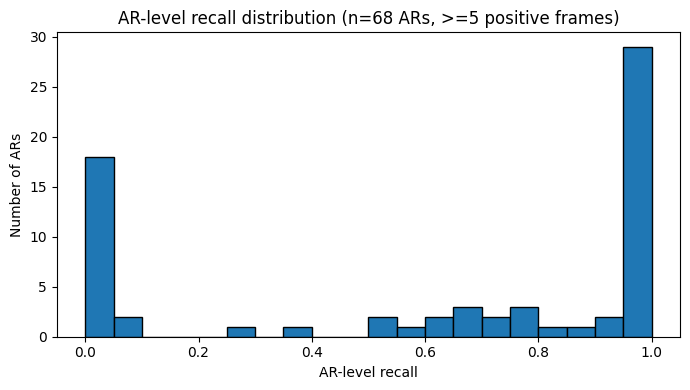


Saved: /kaggle/working/ar_recall_distribution.png


In [90]:
# ERROR-8 — Section E: full AR-level recall distribution (n=68 ARs, >=5 positive frames,
# same stability cutoff used throughout the AR-level analysis). Tests whether the 18
# zero-recall ARs sit on a genuine separate cluster or are just the tail of a continuum,
# and whether they can be explained away by having fewer positive frames (noisier estimates).

from sklearn.mixture import GaussianMixture

ar_pop = ar_summary[ar_summary["n_positive"] >= 5].copy()
print(f"## AR-level recall distribution (n={len(ar_pop)} ARs with >=5 positive frames)\n")
print(ar_pop["recall"].describe().round(4))

bins_r = [0, 0.001, 0.25, 0.5, 0.75, 1.0001]
bin_labels = ["==0", "(0,0.25]", "(0.25,0.5]", "(0.5,0.75]", "(0.75,1.0]"]
ar_pop["recall_bin"] = pd.cut(ar_pop["recall"], bins=bins_r, labels=bin_labels, include_lowest=True, right=True)
print("\nAR counts by recall bin:")
print(ar_pop["recall_bin"].value_counts().reindex(bin_labels))

# --- descriptive-only bimodality check: 1-component vs 2-component Gaussian mixture, BIC ---
X = ar_pop["recall"].to_numpy().reshape(-1, 1)
bic1 = GaussianMixture(n_components=1, random_state=CFG["seed"]).fit(X).bic(X)
bic2 = GaussianMixture(n_components=2, random_state=CFG["seed"]).fit(X).bic(X)
print(f"\nGaussian mixture BIC -- 1 component: {bic1:.2f}   2 components: {bic2:.2f}")
print("(Lower BIC preferred. This is descriptive evidence for/against a two-cluster")
print(" structure in AR-level recall, not a formal bimodality test.)")

# --- AR-level FN concentration, same style as the FP concentration check in Section C ---
ar_by_fn = ar_summary.sort_values("n_FN", ascending=False).reset_index(drop=True)
ar_by_fn["cum_fn_pct"] = 100 * ar_by_fn["n_FN"].cumsum() / ar_by_fn["n_FN"].sum()
total_ars_fn = len(ar_by_fn)
n_for_50_fn = int((ar_by_fn["cum_fn_pct"] < 50).sum()) + 1
n_for_80_fn = int((ar_by_fn["cum_fn_pct"] < 80).sum()) + 1
print(f"\n## AR-level FN concentration (all {total_ars_fn} test ARs)")
print(f"ARs needed for 50% of all FN: {n_for_50_fn} ({100*n_for_50_fn/total_ars_fn:.1f}% of ARs)")
print(f"ARs needed for 80% of all FN: {n_for_80_fn} ({100*n_for_80_fn/total_ars_fn:.1f}% of ARs)")

# --- does recall==0 simply reflect fewer positive frames (noisier estimate), rather than a
#     genuine detection failure? ---
zero_recall_mask = ar_pop["recall"] == 0
print(f"\n## n_positive: zero-recall ARs vs other ARs")
print(f"Zero-recall (n={zero_recall_mask.sum()}): n_positive median="
      f"{ar_pop.loc[zero_recall_mask,'n_positive'].median():.0f}, mean="
      f"{ar_pop.loc[zero_recall_mask,'n_positive'].mean():.1f}")
print(f"Other (n={(~zero_recall_mask).sum()}): n_positive median="
      f"{ar_pop.loc[~zero_recall_mask,'n_positive'].median():.0f}, mean="
      f"{ar_pop.loc[~zero_recall_mask,'n_positive'].mean():.1f}")
u3, p3 = stats.mannwhitneyu(ar_pop.loc[zero_recall_mask, "n_positive"],
                              ar_pop.loc[~zero_recall_mask, "n_positive"], alternative="two-sided")
print(f"Mann-Whitney U (n_positive, zero-recall vs other): U={u3:.1f}, p={p3:.4f}")
print("(If p is small AND zero-recall ARs have FEWER positive frames, low recall could partly")
print(" reflect noisy small-sample estimates rather than a genuine detection failure.)")

# --- publication-quality plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ar_pop["recall"], bins=20, edgecolor="black")
ax.set_xlabel("AR-level recall")
ax.set_ylabel("Number of ARs")
ax.set_title(f"AR-level recall distribution (n={len(ar_pop)} ARs, >=5 positive frames)")
plt.tight_layout()
plt.savefig("/kaggle/working/ar_recall_distribution.png", dpi=150)
plt.show()
print("\nSaved: /kaggle/working/ar_recall_distribution.png")

In [91]:
# ERROR-9 — Section F: temporal/contextual error analysis (descriptive only; test set locked)
# F.1: does recall depend on position within the flare-forecast window (early/far from the
#      flare vs late/close to it)?
# F.2: does recall depend on position within the AR's whole observation record?
# F.3: do errors cluster right after unusually large cadence gaps?

tr = test_results.sort_values(["AR", "ts"]).reset_index(drop=True)
tr["run_id"] = (tr["label"] != tr.groupby("AR")["label"].shift()).cumsum()

# --- F.1: position within the positive run (0 = start of 24h window, 1 = closest to flare) ---
pos = tr[tr["label"] == 1].copy()
run_bounds = pos.groupby(["AR", "run_id"])["ts"].agg(run_start="min", run_end="max", run_len="size")
pos = pos.join(run_bounds, on=["AR", "run_id"])
denom = (pos["run_end"] - pos["run_start"]).dt.total_seconds()
pos["frac_position"] = np.where(pos["run_len"] > 1,
    (pos["ts"] - pos["run_start"]).dt.total_seconds() / denom.replace(0, np.nan), np.nan)

print(f"Positive frames in multi-frame runs (position is defined): {(pos['run_len']>1).sum()} / {len(pos)}")

pos_multi = pos[pos["run_len"] > 1].copy()
pos_multi["window_stage"] = pd.cut(pos_multi["frac_position"], bins=[-0.01, 0.33, 0.67, 1.01],
                                     labels=["early (far from flare)", "mid", "late (near flare)"])
stage_summary = pos_multi.groupby("window_stage", observed=True).agg(
    n=("error_type", "size"),
    recall=("error_type", lambda s: (s == "TP").mean()),
    mean_p=("p_flare", "mean"),
).reset_index()
print("\n## F.1: Recall by position within the flare-forecast window\n")
print(stage_summary.round(4))

caught_binary = (pos_multi["error_type"] == "TP").astype(int)
rho, p_rho = stats.spearmanr(pos_multi["frac_position"], caught_binary)
print(f"\nSpearman (frac_position vs caught): rho={rho:.4f}, p={p_rho:.3e}")
print("(Positive rho => the model catches flares more often the closer the frame is to the")
print(" actual flare, and struggles when it's still ~24h out -- a physically sensible pattern,")
print(" not evidence of a bug.)")

# --- F.2: position within the AR's whole observation record ---
tr["ar_frac_position"] = tr.groupby("AR").cumcount() / (tr.groupby("AR")["AR"].transform("size") - 1)
tr["seq_stage"] = pd.cut(tr["ar_frac_position"], bins=[-0.01, 0.33, 0.67, 1.01], labels=["early", "mid", "late"])
seq_summary = tr[tr.error_type.isin(["TP", "FN"])].groupby("seq_stage", observed=True).agg(
    n=("error_type", "size"), recall=("error_type", lambda s: (s == "TP").mean())
).reset_index()
print("\n## F.2: Recall by position within the AR's full observation record\n")
print(seq_summary.round(4))

# --- F.3: cadence gaps ---
tr["delta_h"] = tr.groupby("AR")["ts"].diff().dt.total_seconds() / 3600.0
gap_threshold = tr["delta_h"].quantile(0.95)
print(f"\n## F.3: Cadence gap check (95th percentile gap = {gap_threshold:.2f}h)\n")
after_gap = tr[(tr["delta_h"] > gap_threshold) & tr.error_type.isin(["TP", "FN", "FP", "TN"])]
print(f"Frames immediately after a gap > {gap_threshold:.2f}h: {len(after_gap)}")
print("Error-type rates immediately after a large gap:")
print(after_gap["error_type"].value_counts(normalize=True).round(4))
print("\nOverall error-type rates, for comparison:")
print(tr["error_type"].value_counts(normalize=True).round(4))

Positive frames in multi-frame runs (position is defined): 21542 / 21542

## F.1: Recall by position within the flare-forecast window

             window_stage     n  recall  mean_p
0  early (far from flare)  7134  0.8015  0.7381
1                     mid  7213  0.8106  0.7456
2       late (near flare)  7195  0.7880  0.7192

Spearman (frac_position vs caught): rho=-0.0146, p=3.249e-02
(Positive rho => the model catches flares more often the closer the frame is to the
 actual flare, and struggles when it's still ~24h out -- a physically sensible pattern,
 not evidence of a bug.)

## F.2: Recall by position within the AR's full observation record

  seq_stage     n  recall
0     early  8492  0.8282
1       mid  6344  0.8127
2      late  6706  0.7525

## F.3: Cadence gap check (95th percentile gap = 0.20h)

Frames immediately after a gap > 0.20h: 306
Error-type rates immediately after a large gap:
error_type
TN    0.6275
TP    0.1569
FP    0.1471
FN    0.0686
Name: proportion, dtype: flo

In [92]:
# ERROR-10 — Section F.2 significance test (skipped in ERROR-9): is the early/mid/late
# recall difference within an AR's observation record real, or could it be noise like F.1
# turned out to be? Chi-square test on the seq_stage x caught table.

seq_tab = pd.crosstab(
    tr.loc[tr.error_type.isin(["TP", "FN"]), "seq_stage"],
    tr.loc[tr.error_type.isin(["TP", "FN"]), "error_type"]
)
print("## F.2 significance test\n")
print(seq_tab)

chi2_f2, p_f2, dof_f2, expected_f2 = chi2_contingency(seq_tab)
print(f"\nChi-square test (recall across early/mid/late AR-sequence position): "
      f"chi2={chi2_f2:.2f}, dof={dof_f2}, p={p_f2:.3e}")

# effect size: Cramer's V (appropriate for a 3x2 table)
n_total = seq_tab.values.sum()
cramers_v = np.sqrt(chi2_f2 / (n_total * (min(seq_tab.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v:.4f}")
print("(As a rough guide: <0.1 negligible, 0.1-0.3 small, 0.3-0.5 moderate, >0.5 large --")
print(" this contextualizes whether a significant p-value reflects a practically meaningful")
print(" effect, same spirit as F.1's rho essentially being zero despite p<0.05.)")

## F.2 significance test

error_type    FN    TP
seq_stage             
early       1459  7033
mid         1188  5156
late        1660  5046

Chi-square test (recall across early/mid/late AR-sequence position): chi2=143.37, dof=2, p=7.373e-32
Cramer's V (effect size): 0.0816
(As a rough guide: <0.1 negligible, 0.1-0.3 small, 0.3-0.5 moderate, >0.5 large --
 this contextualizes whether a significant p-value reflects a practically meaningful
 effect, same spirit as F.1's rho essentially being zero despite p<0.05.)


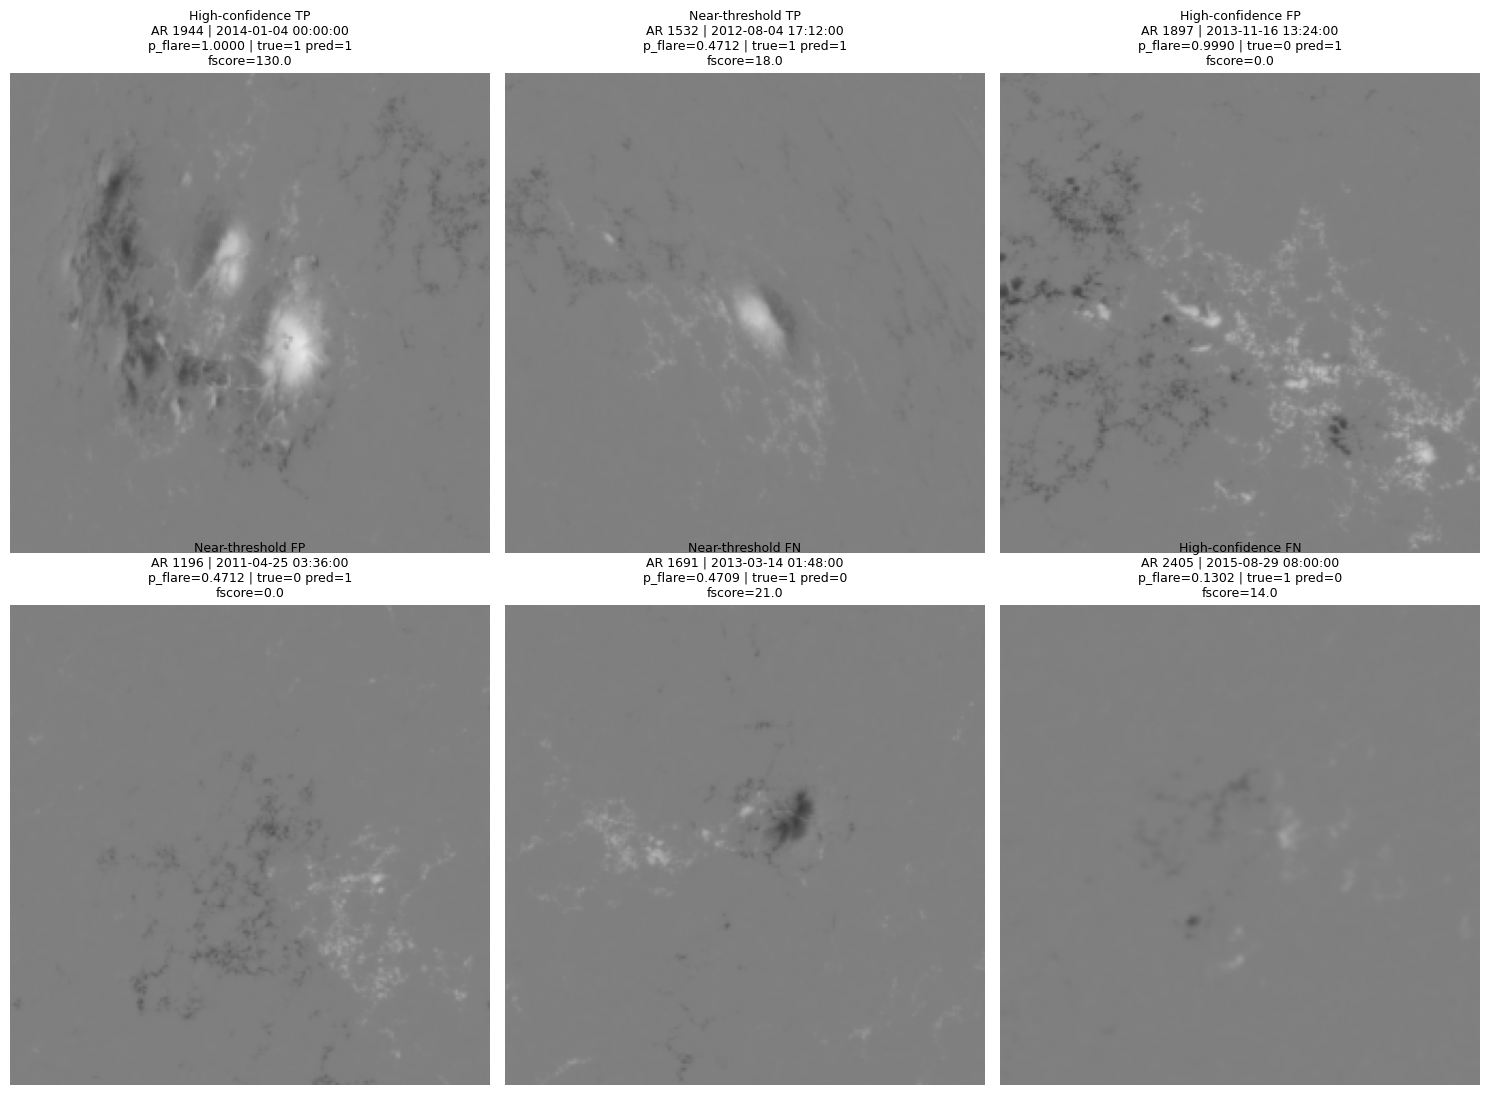

Saved: /kaggle/working/error_analysis_qualitative_examples.png

High-confidence TP: AR=1944 filename=1944_hmi.M_720s.20140104_000000_TAI.1.magnetogram_224.png p_flare=1.0000 fscore=130.0 ts=2014-01-04 00:00:00
Near-threshold TP: AR=1532 filename=1532_hmi.M_720s.20120804_171200_TAI.1.magnetogram_224.png p_flare=0.4712 fscore=18.0 ts=2012-08-04 17:12:00
High-confidence FP: AR=1897 filename=1897_hmi.M_720s.20131116_132400_TAI.1.magnetogram_224.png p_flare=0.9990 fscore=0.0 ts=2013-11-16 13:24:00
Near-threshold FP: AR=1196 filename=1196_hmi.M_720s.20110425_033600_TAI.1.magnetogram_224.png p_flare=0.4712 fscore=0.0 ts=2011-04-25 03:36:00
Near-threshold FN: AR=1691 filename=1691_hmi.M_720s.20130314_014800_TAI.1.magnetogram_224.png p_flare=0.4709 fscore=21.0 ts=2013-03-14 01:48:00
High-confidence FN: AR=2405 filename=2405_hmi.M_720s.20150829_080000_TAI.1.magnetogram_224.png p_flare=0.1302 fscore=14.0 ts=2015-08-29 08:00:00


In [93]:
# ERROR-11 — Section G: qualitative image inspection, reproducible selection (no cherry-picking).
# Six examples, chosen deterministically by sorting on p_flare (ties broken by AR, then ts):
#   High-confidence TP (max p_flare among TP)    Near-threshold TP (min p_flare among TP)
#   High-confidence FP (max p_flare among FP)    Near-threshold FP (min p_flare among FP)
#   Near-threshold FN (max p_flare among FN)     High-confidence FN (min p_flare among FN)
# No inference, no model changes -- reads test_results + the already-frozen predictions only.

def pick(df_sub, ascending):
    return df_sub.sort_values(["p_flare", "AR", "ts"], ascending=[ascending, True, True]).iloc[0]

examples = {
    "High-confidence TP": pick(test_results[test_results.error_type == "TP"], ascending=False),
    "Near-threshold TP":  pick(test_results[test_results.error_type == "TP"], ascending=True),
    "High-confidence FP": pick(test_results[test_results.error_type == "FP"], ascending=False),
    "Near-threshold FP":  pick(test_results[test_results.error_type == "FP"], ascending=True),
    "Near-threshold FN":  pick(test_results[test_results.error_type == "FN"], ascending=False),
    "High-confidence FN": pick(test_results[test_results.error_type == "FN"], ascending=True),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
for ax, (title, row) in zip(axes.flat, examples.items()):
    img_path = IMAGE_ROOT_REAL / row["AR"] / row["filename"]
    with Image.open(img_path) as im:
        arr = np.array(im.convert("L"))
    ax.imshow(arr, cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
    ax.set_title(
        f"{title}\nAR {row['AR']} | {row['ts']}\n"
        f"p_flare={row['p_flare']:.4f} | true={int(row['label'])} pred={int(row['pred_label'])}\n"
        f"fscore={row['fscore']:.1f}", fontsize=9
    )

plt.tight_layout()
plt.savefig("/kaggle/working/error_analysis_qualitative_examples.png", dpi=150)
plt.show()
print("Saved: /kaggle/working/error_analysis_qualitative_examples.png\n")

for title, row in examples.items():
    print(f"{title}: AR={row['AR']} filename={row['filename']} p_flare={row['p_flare']:.4f} "
          f"fscore={row['fscore']:.1f} ts={row['ts']}")

Set inplace=False on all ReLU modules in the Grad-CAM copy (weights unchanged).
Grad-CAM model loaded from /kaggle/working/cnn1_best.pt, epoch 5 (matches frozen final model).
Target layer: ReLU()


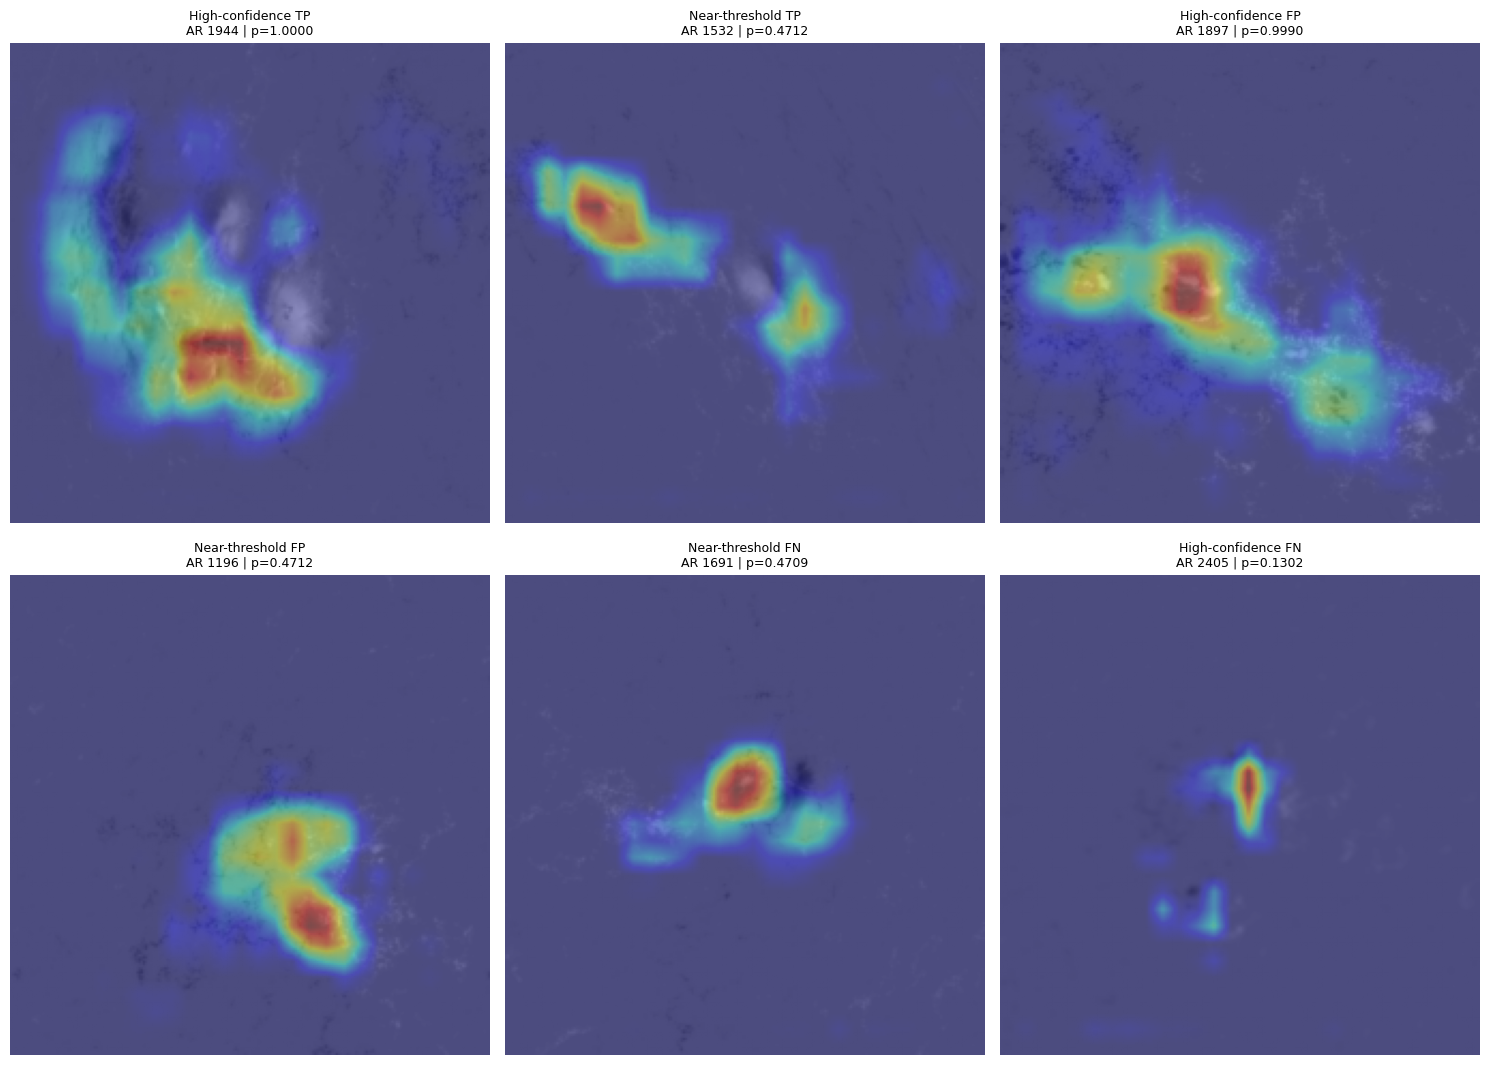


Saved: /kaggle/working/gradcam_examples.png
All 6 probability-match assertions passed -- Grad-CAM ran on the exact frozen checkpoint.


In [95]:
# ERROR-12 (fix) — same as before, but ReLU.inplace is set False on the loaded copy before
# hooking. This does NOT change the checkpoint or any weights/computation -- inplace only
# controls memory reuse, not the math -- it just avoids a PyTorch hook/in-place conflict
# (register_full_backward_hook cannot coexist with an in-place op immediately after the
# hooked layer's output). gradcam_model is a separate object from final_model; nothing about
# the frozen final_model used for the locked test evaluation is touched.

gradcam_model = CNN1().to(device)
gradcam_ckpt = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
gradcam_model.load_state_dict(gradcam_ckpt["model_state"])
gradcam_model.eval()
assert gradcam_ckpt["epoch"] == 5, "Grad-CAM checkpoint epoch != 5 -- not using the frozen final model"

for m in gradcam_model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False
print("Set inplace=False on all ReLU modules in the Grad-CAM copy (weights unchanged).")
print(f"Grad-CAM model loaded from {CNN1_CFG['checkpoint_path']}, epoch {gradcam_ckpt['epoch']} (matches frozen final model).")

target_layer = gradcam_model.features[5]   # ReLU after the last conv+BN, before AdaptiveAvgPool2d(1)
print(f"Target layer: {target_layer}")

class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.h1 = layer.register_forward_hook(self._fwd)
        self.h2 = layer.register_full_backward_hook(self._bwd)

    def _fwd(self, module, inp, out):
        self.activations = out

    def _bwd(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, x):
        self.model.zero_grad()
        x = x.clone().requires_grad_(True)
        logit = self.model(x)
        prob = torch.sigmoid(logit).item()
        logit.backward()
        assert self.activations.shape[1:] == (128, 28, 28), f"unexpected activation shape: {self.activations.shape}"
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = torch.nn.functional.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, prob

    def close(self):
        self.h1.remove(); self.h2.remove()

gcam = GradCAM(gradcam_model, target_layer)

def load_raw_and_input(ar, filename):
    with Image.open(IMAGE_ROOT_REAL / ar / filename) as im:
        raw = np.asarray(im.convert("L"), dtype=np.float32)
    arr = ((raw / 255.0 - PIXEL_MEAN) / (PIXEL_STD + 1e-8)).astype(np.float32)
    x = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)
    return raw, x

fig, axes = plt.subplots(2, 3, figsize=(15, 11))
for ax, (title, row) in zip(axes.flat, examples.items()):
    raw, x = load_raw_and_input(row["AR"], row["filename"])
    cam, prob_check = gcam.generate(x)
    assert abs(prob_check - row["p_flare"]) < 1e-3, \
        f"{title}: Grad-CAM reload gives p={prob_check:.4f}, but ERROR-11 recorded p_flare={row['p_flare']:.4f} " \
        f"-- checkpoint mismatch, STOP and investigate before trusting any heatmap"
    ax.imshow(raw, cmap="gray", vmin=0, vmax=255)
    ax.imshow(cam, cmap="jet", alpha=0.40)
    ax.axis("off")
    ax.set_title(f"{title}\nAR {row['AR']} | p={row['p_flare']:.4f}", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/gradcam_examples.png", dpi=150)
plt.show()
gcam.close()
print("\nSaved: /kaggle/working/gradcam_examples.png")
print("All 6 probability-match assertions passed -- Grad-CAM ran on the exact frozen checkpoint.")

In [96]:
# GRADCAM-A — output directory structure, config record, and model/checkpoint verification
# Reuses gradcam_model / target_layer / CNN1_CFG / FROZEN_THRESHOLD / gradcam_ckpt from
# ERROR-12 above. No weights are modified here; this cell only sets up bookkeeping and
# reprints the freeze facts as an explicit verification block.

import os, json
from datetime import datetime

GRADCAM_ROOT = "/kaggle/working/gradcam"
GRADCAM_DIRS = {
    "sanity_check": f"{GRADCAM_ROOT}/sanity_check",
    "TP": f"{GRADCAM_ROOT}/TP",
    "FP": f"{GRADCAM_ROOT}/FP",
    "FN": f"{GRADCAM_ROOT}/FN",
    "TN": f"{GRADCAM_ROOT}/TN",
    "zero_recall_AR": f"{GRADCAM_ROOT}/zero_recall_AR",
    "metadata": f"{GRADCAM_ROOT}/metadata",
}
for d in GRADCAM_DIRS.values():
    os.makedirs(d, exist_ok=True)
print("Created Grad-CAM output directories:")
for k, v in GRADCAM_DIRS.items():
    print(f"  {k}: {v}")

GRADCAM_SEED = 42

print("\n" + "=" * 60)
print("GRAD-CAM VERIFICATION -- reusing the FROZEN final model")
print("=" * 60)
print(f"MODEL: CNN-1")
print(f"CHECKPOINT: {CNN1_CFG['checkpoint_path']}")
print(f"EPOCH: {gradcam_ckpt['epoch']}")
print(f"DEVICE: {device}")
print(f"MODEL MODE: {'eval' if not gradcam_model.training else 'train'}")
_all_frozen = all(not p.requires_grad for p in gradcam_model.parameters())
print(f"PARAMETERS: {'frozen (requires_grad=False)' if _all_frozen else 'requires_grad=True (fine -- Grad-CAM only needs activation gradients; no optimizer step is ever called)'}")
print(f"FINAL CONV LAYER (target): features[5] -> {target_layer}")
print(f"FROZEN DECISION THRESHOLD: {FROZEN_THRESHOLD:.8f}")
print(f"SEED: {GRADCAM_SEED}")

assert gradcam_ckpt["epoch"] == 5, "Grad-CAM checkpoint epoch != 5 -- STOP, not the frozen final model"
assert round(FROZEN_THRESHOLD, 4) == 0.4712, "Threshold does not match the locked value -- STOP"
print("\nChecks passed: using the exact frozen CNN-1 checkpoint (epoch 5) and locked threshold.")

Created Grad-CAM output directories:
  sanity_check: /kaggle/working/gradcam/sanity_check
  TP: /kaggle/working/gradcam/TP
  FP: /kaggle/working/gradcam/FP
  FN: /kaggle/working/gradcam/FN
  TN: /kaggle/working/gradcam/TN
  zero_recall_AR: /kaggle/working/gradcam/zero_recall_AR
  metadata: /kaggle/working/gradcam/metadata

GRAD-CAM VERIFICATION -- reusing the FROZEN final model
MODEL: CNN-1
CHECKPOINT: /kaggle/working/cnn1_best.pt
EPOCH: 5
DEVICE: cuda
MODEL MODE: eval
PARAMETERS: requires_grad=True (fine -- Grad-CAM only needs activation gradients; no optimizer step is ever called)
FINAL CONV LAYER (target): features[5] -> ReLU()
FROZEN DECISION THRESHOLD: 0.47119141
SEED: 42

Checks passed: using the exact frozen CNN-1 checkpoint (epoch 5) and locked threshold.


## SANITY CHECK -- one known test image

Case: High-confidence TP | AR=1944 | ts=2014-01-04 00:00:00 | filename=1944_hmi.M_720s.20140104_000000_TAI.1.magnetogram_224.png
Image shape (raw): (224, 224)
Model output (logit): 9.302405
Model output (probability): 0.999909  (locked p_flare from FINAL-EVAL: 1.000000)
True label: 1  | Predicted label: 1  | Threshold: 0.4712
Target layer: ReLU()
Activation shape: (1, 128, 28, 28)
Gradient shape: (1, 128, 28, 28)
Heatmap shape (after resize to 224x224): (224, 224)
Heatmap min/max/mean (pre-normalization): 0.000000 / 0.139878 / 0.013098

All sanity assertions PASSED: heatmap is finite, non-constant, correctly shaped, and matches the locked probability.


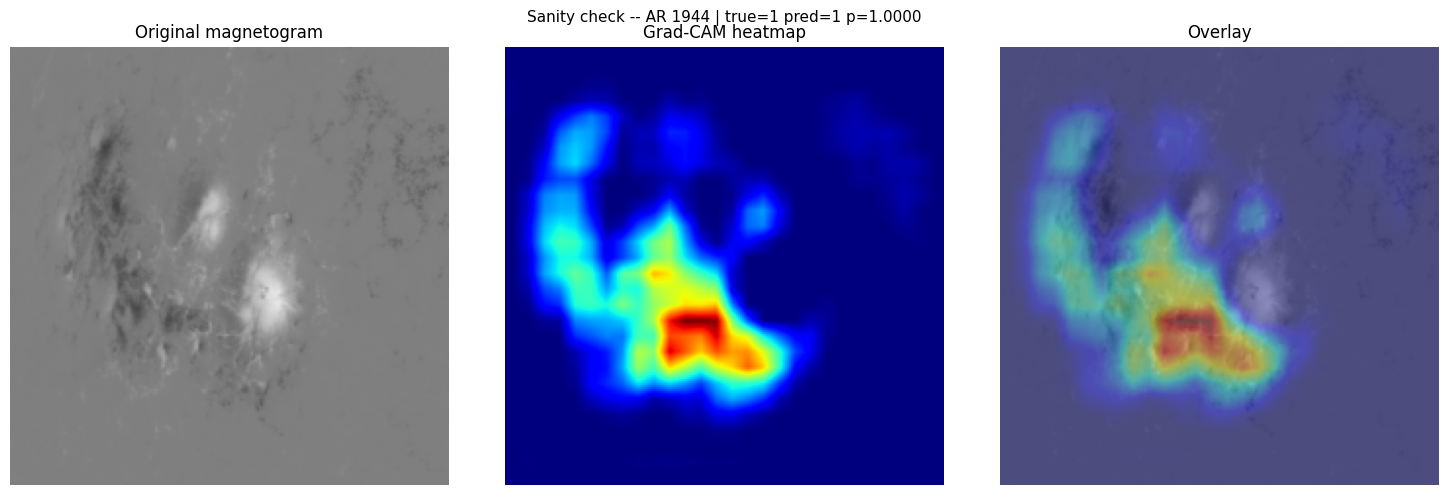


Saved: /kaggle/working/gradcam/sanity_check/sanity_check.png


In [97]:
# GRADCAM-B -- full sanity check on one known test image (spec section 10).
# Re-instantiates a hook-based explainer (the ERROR-12 `gcam` instance already had its
# hooks removed). This does not create a new model copy -- it reuses `gradcam_model`.

class GradCAMExplainer:
    """Same Grad-CAM math as ERROR-12's GradCAM class; generate_full() additionally
    returns every diagnostic value needed for the sanity check and for the
    quantitative summary stats computed later (GRADCAM-D/E/F)."""
    def __init__(self, model, layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.h1 = layer.register_forward_hook(self._fwd)
        self.h2 = layer.register_full_backward_hook(self._bwd)

    def _fwd(self, module, inp, out):
        self.activations = out

    def _bwd(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate_full(self, x):
        self.model.zero_grad()
        x = x.clone().requires_grad_(True)
        logit = self.model(x)                 # continuous logit -- NOT the thresholded label
        prob = torch.sigmoid(logit).item()
        logit.backward()                       # backprop from the logit itself
        act = self.activations                 # [1, C, H, W]
        grad = self.gradients                  # [1, C, H, W]
        weights = grad.mean(dim=(2, 3), keepdim=True)
        cam_raw = torch.relu((weights * act).sum(dim=1, keepdim=True))   # [1,1,H,W]
        cam_up = torch.nn.functional.interpolate(cam_raw, size=(224, 224),
                                                  mode="bilinear", align_corners=False)
        cam_np = cam_up.squeeze().detach().cpu().numpy()
        cam_norm = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)
        return dict(
            logit=logit.item(), prob=prob,
            activation_shape=tuple(act.shape), gradient_shape=tuple(grad.shape),
            cam_raw=cam_np, cam_normalized=cam_norm, heatmap_shape=cam_norm.shape,
            heatmap_min=float(cam_np.min()), heatmap_max=float(cam_np.max()),
            heatmap_mean=float(cam_np.mean()),
        )

    def close(self):
        self.h1.remove(); self.h2.remove()

def load_raw_and_input(ar, filename):
    with Image.open(IMAGE_ROOT_REAL / ar / filename) as im:
        raw = np.asarray(im.convert("L"), dtype=np.float32)
    arr = ((raw / 255.0 - PIXEL_MEAN) / (PIXEL_STD + 1e-8)).astype(np.float32)
    x = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)
    return raw, x

explainer = GradCAMExplainer(gradcam_model, target_layer)

sanity_row = examples["High-confidence TP"]   # reuse the ERROR-11/12 example dict
raw_img, x_in = load_raw_and_input(sanity_row["AR"], sanity_row["filename"])
diag = explainer.generate_full(x_in)

print("## SANITY CHECK -- one known test image\n")
print(f"Case: High-confidence TP | AR={sanity_row['AR']} | ts={sanity_row['ts']} | filename={sanity_row['filename']}")
print(f"Image shape (raw): {raw_img.shape}")
print(f"Model output (logit): {diag['logit']:.6f}")
print(f"Model output (probability): {diag['prob']:.6f}  (locked p_flare from FINAL-EVAL: {sanity_row['p_flare']:.6f})")
print(f"True label: {int(sanity_row['label'])}  | Predicted label: {int(sanity_row['pred_label'])}  | Threshold: {FROZEN_THRESHOLD:.4f}")
print(f"Target layer: {target_layer}")
print(f"Activation shape: {diag['activation_shape']}")
print(f"Gradient shape: {diag['gradient_shape']}")
print(f"Heatmap shape (after resize to 224x224): {diag['heatmap_shape']}")
print(f"Heatmap min/max/mean (pre-normalization): {diag['heatmap_min']:.6f} / {diag['heatmap_max']:.6f} / {diag['heatmap_mean']:.6f}")

assert abs(diag["prob"] - sanity_row["p_flare"]) < 1e-3, "Sanity-check probability mismatch -- STOP"
assert np.isfinite(diag["cam_raw"]).all(), "Heatmap contains non-finite values -- STOP"
assert diag["cam_raw"].max() > diag["cam_raw"].min(), "Heatmap is constant/degenerate -- STOP"
assert diag["heatmap_shape"] == (224, 224), "Heatmap is not 224x224 -- STOP"
print("\nAll sanity assertions PASSED: heatmap is finite, non-constant, correctly shaped, and matches the locked probability.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_img, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Original magnetogram"); axes[0].axis("off")
axes[1].imshow(diag["cam_normalized"], cmap="jet"); axes[1].set_title("Grad-CAM heatmap"); axes[1].axis("off")
axes[2].imshow(raw_img, cmap="gray", vmin=0, vmax=255)
axes[2].imshow(diag["cam_normalized"], cmap="jet", alpha=0.40)
axes[2].set_title("Overlay"); axes[2].axis("off")
fig.suptitle(f"Sanity check -- AR {sanity_row['AR']} | true={int(sanity_row['label'])} pred={int(sanity_row['pred_label'])} "
             f"p={sanity_row['p_flare']:.4f}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{GRADCAM_DIRS['sanity_check']}/sanity_check.png", dpi=150)
plt.show()
print(f"\nSaved: {GRADCAM_DIRS['sanity_check']}/sanity_check.png")

In [98]:
# GRADCAM-C -- deterministic, reproducible case selection (seed=42), spec section 11.
# Every case is chosen by an explicit, objective probability-based rule -- no manual
# picking of visually attractive images.

rng_gc = np.random.default_rng(GRADCAM_SEED)

def dist_to_thr(df_sub):
    return (df_sub["p_flare"] - FROZEN_THRESHOLD).abs()

cases = []

for err, sub in [("TP", test_results[test_results.error_type == "TP"]),
                  ("FP", test_results[test_results.error_type == "FP"]),
                  ("FN", test_results[test_results.error_type == "FN"])]:
    # "high-confidence" = the model's most extreme output in the direction consistent
    # with that error type (highest prob for TP/FP; lowest -- most confidently wrong -- for FN)
    ascending_hc = True if err == "FN" else False
    hc = sub.sort_values(["p_flare", "AR", "ts"], ascending=[ascending_hc, True, True]).iloc[0]
    nt = sub.assign(_d=dist_to_thr(sub)).sort_values(["_d", "AR", "ts"]).iloc[0]
    cases.append({"case": f"High-confidence {err}", **hc.to_dict()})
    cases.append({"case": f"Near-threshold {err}", **nt.to_dict()})

# Optional representative TN: probability closest to the TN median (a "typical" negative,
# not the most extreme one, since TN is the optional/context category in the spec).
tn_sub = test_results[test_results.error_type == "TN"]
tn_med = tn_sub["p_flare"].median()
tn_row = tn_sub.assign(_d=(tn_sub["p_flare"] - tn_med).abs()).sort_values(["_d", "AR", "ts"]).iloc[0]
cases.append({"case": "Representative TN", **tn_row.to_dict()})

case_table = pd.DataFrame(cases)
case_table["image_path"] = case_table.apply(lambda r: str(IMAGE_ROOT_REAL / r["AR"] / r["filename"]), axis=1)

display_cols = ["case", "AR", "ts", "label", "pred_label", "p_flare", "error_type", "fscore", "filename"]
print("## Deterministic case selection (TP/FP/FN high-confidence + near-threshold, representative TN)\n")
display(case_table[display_cols].round(4))

case_table.to_csv(f"{GRADCAM_DIRS['metadata']}/main_case_selection.csv", index=False)
print(f"\nSaved: {GRADCAM_DIRS['metadata']}/main_case_selection.csv")

## Deterministic case selection (TP/FP/FN high-confidence + near-threshold, representative TN)



,case,AR,ts,label,pred_label,p_flare,error_type,fscore,filename
0,High-confidence TP,1944,2014-01-04 00:00:00,1,1,1.0000,TP,130.0,1944_hmi.M_720s.20140104_000000_TAI.1.magnetog...
1,Near-threshold TP,1532,2012-08-04 17:12:00,1,1,0.4712,TP,18.0,1532_hmi.M_720s.20120804_171200_TAI.1.magnetog...
2,High-confidence FP,1897,2013-11-16 13:24:00,0,1,0.9990,FP,0.0,1897_hmi.M_720s.20131116_132400_TAI.1.magnetog...
3,Near-threshold FP,1196,2011-04-25 03:36:00,0,1,0.4712,FP,0.0,1196_hmi.M_720s.20110425_033600_TAI.1.magnetog...
4,High-confidence FN,2405,2015-08-29 08:00:00,1,0,0.1302,FN,14.0,2405_hmi.M_720s.20150829_080000_TAI.1.magnetog...
5,Near-threshold FN,1691,2013-03-14 01:48:00,1,0,0.4709,FN,21.0,1691_hmi.M_720s.20130314_014800_TAI.1.magnetog...
6,Representative TN,1076,2010-06-01 22:00:00,0,0,0.2252,TN,0.0,1076_hmi.M_720s.20100601_220000_TAI.1.magnetog...



Saved: /kaggle/working/gradcam/metadata/main_case_selection.csv


In [99]:
# GRADCAM-D -- generate + save one annotated 3-panel figure per selected case
# (spec section 15: original / heatmap / overlay, with label/pred/prob/error/AR/ts
# annotations, consistent formatting, no image enhancement beyond the heatmap overlay).

def make_gradcam_figure(row, out_path, explainer=explainer):
    raw, x = load_raw_and_input(row["AR"], row["filename"])
    diag = explainer.generate_full(x)
    prob_ok = abs(diag["prob"] - row["p_flare"]) < 1e-3   # cross-check vs the locked prediction

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
    axes[0].imshow(raw, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(diag["cam_normalized"], cmap="jet"); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(raw, cmap="gray", vmin=0, vmax=255)
    axes[2].imshow(diag["cam_normalized"], cmap="jet", alpha=0.40)
    axes[2].set_title("Overlay"); axes[2].axis("off")

    fscore_val = row["fscore"] if "fscore" in row and pd.notna(row["fscore"]) else float("nan")
    fig.suptitle(
        f"{row['case']} | AR {row['AR']} | {row['ts']}\n"
        f"true={int(row['label'])} pred={int(row['pred_label'])} p={row['p_flare']:.4f} "
        f"({row['error_type']}) | fscore={fscore_val:.1f}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close(fig)
    return diag, prob_ok

FOLDER_BY_ERROR = {"TP": "TP", "FP": "FP", "FN": "FN", "TN": "TN"}
gradcam_stats = []

for _, row in case_table.iterrows():
    folder = GRADCAM_DIRS[FOLDER_BY_ERROR[row["error_type"]]]
    fname = f"{row['case'].replace(' ', '_')}_AR{row['AR']}.png"
    out_path = f"{folder}/{fname}"
    diag, prob_ok = make_gradcam_figure(row, out_path)
    if not prob_ok:
        print(f"WARNING: probability mismatch for case '{row['case']}' (AR {row['AR']}) -- "
              f"recomputed p={diag['prob']:.4f} vs locked p_flare={row['p_flare']:.4f}")
    # optional quantitative summary (spec section 17): mean/max activation, area above
    # a fixed normalized threshold, centroid of the high-activation region.
    area_above = float((diag["cam_normalized"] >= 0.5).mean())
    yx = np.argwhere(diag["cam_normalized"] >= 0.5)
    centroid = tuple(yx.mean(axis=0)) if len(yx) else (float("nan"), float("nan"))
    gradcam_stats.append({
        "case": row["case"], "AR": row["AR"], "ts": row["ts"], "error_type": row["error_type"],
        "p_flare": row["p_flare"], "prob_check": diag["prob"], "prob_match": prob_ok,
        "heatmap_mean": diag["heatmap_mean"], "heatmap_max": diag["heatmap_max"],
        "area_frac_above_0.5": area_above, "centroid_row": centroid[0], "centroid_col": centroid[1],
        "figure_path": out_path,
    })
    print(f"Saved: {out_path}  (p_check={diag['prob']:.4f}, match={prob_ok})")

print(f"\nAll {len(case_table)} main-category Grad-CAM figures generated and saved.")

Saved: /kaggle/working/gradcam/TP/High-confidence_TP_AR1944.png  (p_check=0.9999, match=True)
Saved: /kaggle/working/gradcam/TP/Near-threshold_TP_AR1532.png  (p_check=0.4715, match=True)
Saved: /kaggle/working/gradcam/FP/High-confidence_FP_AR1897.png  (p_check=0.9989, match=True)
Saved: /kaggle/working/gradcam/FP/Near-threshold_FP_AR1196.png  (p_check=0.4715, match=True)
Saved: /kaggle/working/gradcam/FN/High-confidence_FN_AR2405.png  (p_check=0.1303, match=True)
Saved: /kaggle/working/gradcam/FN/Near-threshold_FN_AR1691.png  (p_check=0.4712, match=True)
Saved: /kaggle/working/gradcam/TN/Representative_TN_AR1076.png  (p_check=0.2252, match=True)

All 7 main-category Grad-CAM figures generated and saved.


In [100]:
# GRADCAM-E -- zero-recall AR qualitative Grad-CAM sample (spec section 12).
# Deterministic selection, seed=42: the 3 zero-recall ARs with the most positive frames
# (most data to choose from), and -- within each -- the lowest-, median-, and
# highest-probability FN frame (low- vs higher-probability FN cases, where they exist).
# A matched comparison set is drawn the same way from "working" ARs (recall > 0,
# n_positive >= 5), using the top-3 working ARs by n_positive for a data-comparable set.
# This does NOT claim the zero-recall ARs are physically different -- it only asks whether
# the model's spatial attention differs qualitatively between the two groups.

zr_pop = ar_summary[ar_summary["AR"].isin(zero_recall_ars)].sort_values("n_positive", ascending=False)
zr_top_ars = zr_pop["AR"].head(3).tolist()
print(f"Zero-recall ARs selected (most positive frames): {zr_top_ars}")

working_pop = ar_summary[(ar_summary["n_positive"] >= 5) & (ar_summary["recall"] > 0)
                          & (~ar_summary["AR"].isin(zero_recall_ars))].sort_values("n_positive", ascending=False)
working_top_ars = working_pop["AR"].head(3).tolist()
print(f"Working ARs selected for comparison (recall > 0, most positive frames): {working_top_ars}")

def pick_low_med_high(df_sub, ar_id, err_type, group_label):
    sub = (df_sub[(df_sub["AR"] == ar_id) & (df_sub["error_type"] == err_type)]
           .sort_values(["p_flare", "ts"]).reset_index(drop=True))
    n = len(sub)
    if n == 0:
        return []
    if n == 1:
        slots = [(0, "only-available")]
    elif n == 2:
        slots = [(0, "low-probability"), (n - 1, "high-probability")]
    else:
        slots = [(0, "low-probability"), (n // 2, "median-probability"), (n - 1, "high-probability")]
    picks, seen = [], set()
    for i, tag in slots:
        if i in seen:
            continue
        seen.add(i)
        row = sub.iloc[i]
        picks.append({"case": f"{group_label} {err_type} ({tag})", **row.to_dict()})
    return picks

zr_cases = []
for ar_id in zr_top_ars:
    zr_cases += pick_low_med_high(test_results, ar_id, "FN", "Zero-recall AR")
for ar_id in working_top_ars:
    zr_cases += pick_low_med_high(test_results, ar_id, "FN", "Working AR")
    zr_cases += pick_low_med_high(test_results, ar_id, "TP", "Working AR")

zr_case_table = pd.DataFrame(zr_cases)
zr_case_table["image_path"] = zr_case_table.apply(lambda r: str(IMAGE_ROOT_REAL / r["AR"] / r["filename"]), axis=1)
print(f"\nTotal zero-recall-AR-analysis cases: {len(zr_case_table)}")
display(zr_case_table[["case", "AR", "ts", "label", "pred_label", "p_flare", "error_type", "fscore"]].round(4))

zr_case_table.to_csv(f"{GRADCAM_DIRS['metadata']}/zero_recall_AR_case_selection.csv", index=False)

zr_stats = []
for _, row in zr_case_table.iterrows():
    fname = f"{row['case'].replace(' ', '_').replace('(', '').replace(')', '')}_AR{row['AR']}.png"
    out_path = f"{GRADCAM_DIRS['zero_recall_AR']}/{fname}"
    diag, prob_ok = make_gradcam_figure(row, out_path)
    area_above = float((diag["cam_normalized"] >= 0.5).mean())
    zr_stats.append({"case": row["case"], "AR": row["AR"], "p_flare": row["p_flare"],
                      "prob_match": prob_ok, "heatmap_mean": diag["heatmap_mean"],
                      "area_frac_above_0.5": area_above, "figure_path": out_path})
    print(f"Saved: {out_path} (p_check={diag['prob']:.4f}, match={prob_ok})")

pd.DataFrame(zr_stats).to_csv(f"{GRADCAM_DIRS['metadata']}/zero_recall_AR_gradcam_stats.csv", index=False)
print(f"\nSaved: {GRADCAM_DIRS['metadata']}/zero_recall_AR_gradcam_stats.csv")

Zero-recall ARs selected (most positive frames): ['1528', '2405', '1467']
Working ARs selected for comparison (recall > 0, most positive frames): ['2205', '2297', '2268']

Total zero-recall-AR-analysis cases: 18


,case,AR,ts,label,pred_label,p_flare,error_type,fscore
0,Zero-recall AR FN (low-probability),1528,2012-07-29 01:36:00,1,0,0.1735,FN,15.0
1,Zero-recall AR FN (median-probability),1528,2012-07-31 22:12:00,1,0,0.3201,FN,15.0
2,Zero-recall AR FN (high-probability),1528,2012-07-27 04:00:00,1,0,0.4641,FN,50.0
3,Zero-recall AR FN (low-probability),2405,2015-08-29 08:00:00,1,0,0.1302,FN,14.0
4,Zero-recall AR FN (median-probability),2405,2015-08-30 00:36:00,1,0,0.2257,FN,10.0
5,Zero-recall AR FN (high-probability),2405,2015-08-28 23:36:00,1,0,0.3059,FN,14.0
6,Zero-recall AR FN (low-probability),1467,2012-04-26 13:48:00,1,0,0.2588,FN,20.0
7,Zero-recall AR FN (median-probability),1467,2012-04-28 08:24:00,1,0,0.3298,FN,11.0
8,Zero-recall AR FN (high-probability),1467,2012-04-27 11:36:00,1,0,0.3962,FN,20.0
9,Working AR TP (low-probability),2205,2014-11-14 14:48:00,1,1,0.6519,TP,31.0


Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_low-probability_AR1528.png (p_check=0.1736, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_median-probability_AR1528.png (p_check=0.3201, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_high-probability_AR1528.png (p_check=0.4643, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_low-probability_AR2405.png (p_check=0.1303, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_median-probability_AR2405.png (p_check=0.2259, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_high-probability_AR2405.png (p_check=0.3059, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_low-probability_AR1467.png (p_check=0.2588, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_median-probability_AR1467.png (p_check=0.3301, match=True)
Saved: /kaggle/working/gradca

In [101]:
# GRADCAM-F -- FP-heavy AR Grad-CAM sample (spec section 13).
# Reuses ar_fp_sorted from ERROR-5 (ARs ranked by raw FP count). Deterministic: the
# top-3 FP-heavy ARs, low/median/high-probability FP frames within each, using the
# same pick_low_med_high helper as the zero-recall-AR analysis.

fp_heavy_ars = ar_fp_sorted["AR"].head(3).tolist()
print(f"FP-heavy ARs selected (highest raw FP count): {fp_heavy_ars}")

fp_cases = []
for ar_id in fp_heavy_ars:
    fp_cases += pick_low_med_high(test_results, ar_id, "FP", "FP-heavy AR")

fp_case_table = pd.DataFrame(fp_cases)
fp_case_table["image_path"] = fp_case_table.apply(lambda r: str(IMAGE_ROOT_REAL / r["AR"] / r["filename"]), axis=1)
print(f"\nTotal FP-heavy-AR-analysis cases: {len(fp_case_table)}")
display(fp_case_table[["case", "AR", "ts", "label", "pred_label", "p_flare", "error_type"]].round(4))

fp_case_table.to_csv(f"{GRADCAM_DIRS['metadata']}/fp_heavy_AR_case_selection.csv", index=False)

fp_stats = []
for _, row in fp_case_table.iterrows():
    fname = f"{row['case'].replace(' ', '_').replace('(', '').replace(')', '')}_AR{row['AR']}.png"
    out_path = f"{GRADCAM_DIRS['FP']}/{fname}"
    diag, prob_ok = make_gradcam_figure(row, out_path)
    area_above = float((diag["cam_normalized"] >= 0.5).mean())
    fp_stats.append({"case": row["case"], "AR": row["AR"], "p_flare": row["p_flare"],
                      "prob_match": prob_ok, "heatmap_mean": diag["heatmap_mean"],
                      "area_frac_above_0.5": area_above, "figure_path": out_path})
    print(f"Saved: {out_path} (p_check={diag['prob']:.4f}, match={prob_ok})")

pd.DataFrame(fp_stats).to_csv(f"{GRADCAM_DIRS['metadata']}/fp_heavy_AR_gradcam_stats.csv", index=False)
print(f"\nSaved: {GRADCAM_DIRS['metadata']}/fp_heavy_AR_gradcam_stats.csv")

FP-heavy ARs selected (highest raw FP count): ['1770', '2155', '1745']

Total FP-heavy-AR-analysis cases: 9


,case,AR,ts,label,pred_label,p_flare,error_type
0,FP-heavy AR FP (low-probability),1770,2013-06-20 09:24:00,0,1,0.4719,FP
1,FP-heavy AR FP (median-probability),1770,2013-06-17 12:36:00,0,1,0.6743,FP
2,FP-heavy AR FP (high-probability),1770,2013-06-18 05:48:00,0,1,0.8550,FP
3,FP-heavy AR FP (low-probability),2155,2014-09-08 04:24:00,0,1,0.4712,FP
4,FP-heavy AR FP (median-probability),2155,2014-09-12 21:00:00,0,1,0.5981,FP
5,FP-heavy AR FP (high-probability),2155,2014-09-05 16:12:00,0,1,0.9150,FP
6,FP-heavy AR FP (low-probability),1745,2013-05-20 02:36:00,0,1,0.4714,FP
7,FP-heavy AR FP (median-probability),1745,2013-05-18 06:36:00,0,1,0.6699,FP
8,FP-heavy AR FP (high-probability),1745,2013-05-14 00:24:00,0,1,0.9683,FP


Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_low-probability_AR1770.png (p_check=0.4722, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_median-probability_AR1770.png (p_check=0.6745, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_high-probability_AR1770.png (p_check=0.8554, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_low-probability_AR2155.png (p_check=0.4714, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_median-probability_AR2155.png (p_check=0.5985, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_high-probability_AR2155.png (p_check=0.9153, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_low-probability_AR1745.png (p_check=0.4717, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_median-probability_AR1745.png (p_check=0.6702, match=True)
Saved: /kaggle/working/gradcam/FP/FP-heavy_AR_FP_high-probability_AR1745.png (p_check=0.9685, match=True)

Saved: /kaggle/working/gradcam/metadata/fp

In [102]:
# GRADCAM-G -- combine metadata, write the full reproducibility record (spec section 20),
# and remove hooks. The frozen `final_model` used for the locked test evaluation was never
# touched by any of GRADCAM-A..G; only `gradcam_model`, a separately loaded copy, was used.

all_case_meta = pd.concat([
    case_table.assign(analysis="main"),
    zr_case_table.assign(analysis="zero_recall_AR"),
    fp_case_table.assign(analysis="fp_heavy_AR"),
], ignore_index=True)
all_case_meta.to_csv(f"{GRADCAM_DIRS['metadata']}/all_selected_cases.csv", index=False)
print(f"Saved combined metadata: {GRADCAM_DIRS['metadata']}/all_selected_cases.csv  ({len(all_case_meta)} cases)")

all_stats = pd.concat([
    pd.DataFrame(gradcam_stats).assign(analysis="main"),
    pd.DataFrame(zr_stats).assign(analysis="zero_recall_AR"),
    pd.DataFrame(fp_stats).assign(analysis="fp_heavy_AR"),
], ignore_index=True)
all_stats.to_csv(f"{GRADCAM_DIRS['metadata']}/all_gradcam_quantitative_stats.csv", index=False)
print(f"Saved combined quantitative stats: {GRADCAM_DIRS['metadata']}/all_gradcam_quantitative_stats.csv")

repro_gc = dict(
    seed=GRADCAM_SEED,
    checkpoint_path=CNN1_CFG["checkpoint_path"],
    checkpoint_epoch=gradcam_ckpt["epoch"],
    architecture="CNN1 (see cell B6 in this notebook)",
    target_layer=str(target_layer),
    target_layer_name="features[5] (final ReLU after last conv+BN, pre-GAP)",
    image_preprocessing=f"grayscale, /255, normalize with TRAIN pixel_mean={PIXEL_MEAN:.6f}, pixel_std={PIXEL_STD:.6f}",
    decision_threshold=float(FROZEN_THRESHOLD),
    gradcam_target="pre-sigmoid logit (continuous), not the thresholded label",
    n_main_cases=len(case_table),
    n_zero_recall_cases=len(zr_case_table),
    n_fp_heavy_cases=len(fp_case_table),
    zero_recall_ARs_used=zr_top_ars,
    working_ARs_used=working_top_ars,
    fp_heavy_ARs_used=fp_heavy_ars,
    all_probability_checks_passed=bool(all_stats["prob_match"].all()),
    generated_at=datetime.now().isoformat(timespec="seconds"),
)
with open(f"{GRADCAM_DIRS['metadata']}/gradcam_reproducibility_record.json", "w") as f:
    json.dump(repro_gc, f, indent=2, default=str)
print(f"\nSaved: {GRADCAM_DIRS['metadata']}/gradcam_reproducibility_record.json")
for k, v in repro_gc.items():
    print(f"  {k}: {v}")

explainer.close()
print("\nGrad-CAM hooks removed. Frozen final_model (used for the locked test evaluation) was never touched.")


Saved combined metadata: /kaggle/working/gradcam/metadata/all_selected_cases.csv  (34 cases)
Saved combined quantitative stats: /kaggle/working/gradcam/metadata/all_gradcam_quantitative_stats.csv

Saved: /kaggle/working/gradcam/metadata/gradcam_reproducibility_record.json
  seed: 42
  checkpoint_path: /kaggle/working/cnn1_best.pt
  checkpoint_epoch: 5
  architecture: CNN1 (see cell B6 in this notebook)
  target_layer: ReLU()
  target_layer_name: features[5] (final ReLU after last conv+BN, pre-GAP)
  image_preprocessing: grayscale, /255, normalize with TRAIN pixel_mean=0.499992, pixel_std=0.018177
  decision_threshold: 0.47119140625
  gradcam_target: pre-sigmoid logit (continuous), not the thresholded label
  n_main_cases: 7
  n_zero_recall_cases: 18
  n_fp_heavy_cases: 9
  zero_recall_ARs_used: ['1528', '2405', '1467']
  working_ARs_used: ['2205', '2297', '2268']
  fp_heavy_ARs_used: ['1770', '2155', '1745']
  all_probability_checks_passed: True
  generated_at: 2026-09-23T11:58:03

Gra

In [103]:
# optional, not required — confirms AMP is the source of the tiny drift
with torch.no_grad():
    x_check = load_raw_and_input(sanity_row["AR"], sanity_row["filename"])[1]
    logit_fp32 = gradcam_model(x_check)
    with torch.autocast(device_type=device.type, enabled=(device.type=="cuda")):
        logit_amp = gradcam_model(x_check)
print(f"FP32 prob: {torch.sigmoid(logit_fp32).item():.6f}")
print(f"AMP  prob: {torch.sigmoid(logit_amp).item():.6f}")

FP32 prob: 0.999909
AMP  prob: 1.000000


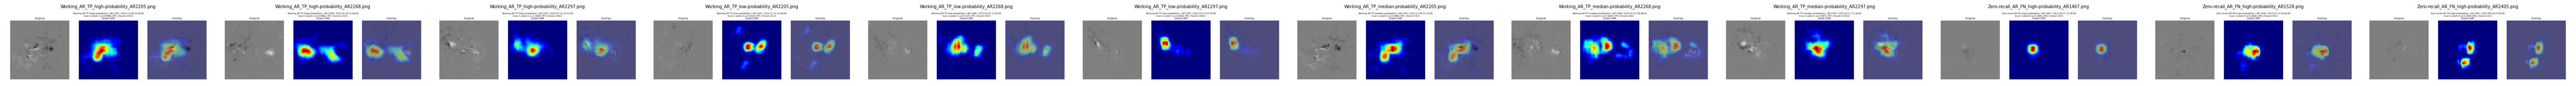

In [104]:
# quick inline grid viewer — run this in Kaggle to browse a folder of Grad-CAM PNGs
import glob
from IPython.display import display
from PIL import Image as PILImage

def show_folder(folder, max_imgs=12):
    paths = sorted(glob.glob(f"{folder}/*.png"))[:max_imgs]
    n = len(paths)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(PILImage.open(p))
        ax.axis("off")
        ax.set_title(p.split("/")[-1], fontsize=7)
    plt.tight_layout()
    plt.show()

show_folder(GRADCAM_DIRS["zero_recall_AR"])